# Microzone analysis: CS and subthreshold coupling

This notebook loads multi-PC Spike Detector sessions and compares two partially overlapping population maps: a climbing-fiber-defined CS network and a subthreshold/Vm network. Primary inference uses node-label/QAP permutations that preserve matrix dependence, while pair-level correlations remain descriptive.

The workflow includes shuffle-defined CS/Vm edges, HH/HL/LH/LL overlap, conditional probabilities and node-permuted odds ratios, continuous Vm comparisons, multi-window STTC with jitter nulls, blockwise CS edge stability, slow/mid/fast Vm hub strength, continuous and binned distance analyses, distance-adjusted Vm coupling, and raw-X/Y spatial overlays.

## How to interpret QAP

QAP (Quadratic Assignment Procedure) compares corresponding CS and Vm pair values in the upper triangles of the two ROI-by-ROI matrices. It then repeatedly permutes the **ROI identities** of one whole matrix and recomputes the association. This preserves the dependency caused by each PC appearing in many pairs. The reported QAP p-value is the fraction of identity-permuted matrices whose association is at least as large as the observed association. It tests map alignment—not causality, and not the significance of individual pairs.

## Spatial-map vocabulary

- **CS microband candidate:** a connected component of at least two PCs joined directly or transitively by reproducible CS edges. Same categorical node fill means the same candidate group; grey means an unassigned singleton.
- **Vm hub candidate:** an individual PC whose shuffle-normalized weighted node strength is more than 1 SD above the population mean. Outlined nodes labeled as hubs identify them; hub status is independent of cluster membership.
- **Vm candidate module:** by default, a hierarchical cluster of the full preprocessed Vm correlation matrix using correlation distance. The number of clusters is selected by silhouette score unless `VM_CLUSTER_CONFIG['n_clusters']` is set manually. Band-specific correlation and shuffle-excess clustering remain optional. This is an exploratory functional partition, not an anatomical label.
- Exact node/edge encodings are repeated in each spatial figure legend so the maps can be read independently.

In [1]:
import os
import glob
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
import seaborn as sns

from scipy.ndimage import median_filter
from scipy.signal import butter, sosfiltfilt
from scipy.cluster.hierarchy import fcluster, linkage, leaves_list, optimal_leaf_ordering
from scipy.interpolate import UnivariateSpline
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from scipy.spatial.distance import squareform
from scipy.stats import linregress, pearsonr, rankdata, spearmanr
from IPython.display import display
try:
    import ipywidgets as widgets
    HAS_IPYWIDGETS = True
except ImportError:
    widgets = None
    HAS_IPYWIDGETS = False
HEADLESS_RUN = os.environ.get('MICROZONE_HEADLESS', '0').strip() == '1'
if HEADLESS_RUN:
    widgets = None; HAS_IPYWIDGETS = False

# ==============================
# SETTINGS
# ==============================
DATA_FOLDER = os.environ.get('MICROZONE_DATA_FOLDER', r'/Users/liangqiyuan/Desktop/Temp_data/20260813_B4_PCP2Cre_Microzones')
SESSION_GLOB = 'spike_detection/*_analyzed.npz'
STRICT_CELL_NAME_MATCH = True

# 1. Vm TRACE PREPROCESSING
PREPROCESS_CONFIG = {
    'bleach_median_window_ms': 1000.0,
    'spike_mask_ss_ms': (-2.0, 3.0),
    'spike_mask_cs_ms': (-8.0, 16.0),
    'second_median_enabled': True,
    'second_median_window_ms': 10.0,
    'lowpass_enabled': True,
    'lowpass_cutoff_hz': 100.0,
    'lowpass_order': 2,
}
# Removes a 1 s bleaching baseline, masks detected SS/CS events, applies 10 ms median smoothing,
# and finally applies a zero-phase 100 Hz low-pass. Inspect the interactive trace before trusting Vm results.

# 2. CS CORRELATION AND TEMPORAL STABILITY
CS_CORR_CONFIG = {
    'bin_ms': 20.0,
    'pooling_mode': 'mean_session_r',  # matches syn.ipynb pooled matrices
    'n_null_shuffles': 1000,
    'min_bins': 50,
    'min_shift_fraction': 0.05,
    'rng_seed': 123,
}
STTC_CONFIG = {
    'delta_ms': [10.0, 20.0, 28.0, 50.0, 100.0],
    'n_jitter_shuffles': 200,  # practical default for multi-window null95; use 1000+ for final p-values
    'jitter_window_ms': 50.0,
    'rng_seed': 2028,
}
CS_STABILITY_CONFIG = {
    'blocks_per_session': 3,
    'n_jitter_shuffles': 200,
    'min_events_per_cell_block': 2,
    'high_threshold': 0.80,
    'intermediate_threshold': 0.50,
    'rng_seed': 2029,
}
# STTC is the primary sparse-CS synchrony metric. Binned Pearson/CCG are secondary checks.
# Jitter null95 defines CS edges; blockwise P(edge) defines their temporal stability.

# 3. Vm CORRELATION AND FREQUENCY BANDS
SUBTH_CORR_CONFIG = {
    'pooling_mode': 'concatenate',  # matches subthreshold.ipynb pooled Pearson r
    'standardize_within_session': False,
    'n_null_shuffles': 200,  # stable null95 estimate without exhausting Jupyter resources
    'min_samples': 50,
    'min_shift_ms': 100.0,
    'max_fs_hz': None,  # None keeps all samples, matching subthreshold.ipynb
    'max_samples_per_session': 0,  # 0 disables truncation
    'rng_seed': 321,
}

VM_BAND_CONFIG = {
    'bands_hz': {'slow_0.1_2': (0.1, 2.0), 'mid_2_20': (2.0, 20.0), 'fast_20_100': (20.0, 100.0)},
    'filter_order': 2,
    'n_null_shuffles': 200,
    'n_qap_permutations': 10000,
    'rng_seed': 2027,
}

# Full-band Pearson r remains descriptive; 2–20 Hz is the default clustering source to reduce slow-state inflation.
# Optional zero-phase bands separate slow state, intermediate, and fast Vm fluctuations.

# 4. Vm AND CS CLUSTERING / NETWORK COMPARISON
CLUSTER_CONFIG = {
    'method': 'average',
    'use_connected_components': True,
}
NETWORK_CONFIG = {
    'n_qap_permutations': 10000,
    'n_edge_permutations': 10000,
    'edge_require_fdr': False,  # positive r > absolute shuffle null95; optionally also require q < alpha
    'fdr_alpha': 0.05,
    'rng_seed': 2026,
}
VM_CLUSTER_CONFIG = {
    'enabled': True,
    'source': 'band_correlation',  # primary clustering excludes the slow global-state band
    'source_band': 'mid_2_20',  # used only by the two band-specific source options
    'method': 'average',
    'n_clusters': 'auto',  # integer >= 2, or 'auto' to maximize precomputed-distance silhouette
    'min_clusters': 2,
    'max_clusters': 6,
    'weak_silhouette_threshold': 0.25,
}
CONSENSUS_CONFIG = {
    'enabled': True,
    'blocks_per_session': 3,
    'vm_min_samples_per_block': 500,
    'cs_min_valid_blocks': 3,
    'cs_coassignment_threshold': 0.60,
    'cs_threshold_sensitivity': [0.50, 0.60, 0.70, 0.80],
    'min_cluster_size': 2,
    'ambiguous_low': 0.10,
    'ambiguous_high': 0.90,
    'max_pac_for_supported': 0.50,
    'min_cs_within_between_gap': 0.20,
}
# CS groups are connected components of temporally stable CS edges. Vm modules use hierarchical
# clustering and either automatic silhouette selection or a user-specified integer k. QAP compares maps.
# Final CS/Vm labels are validated by temporal consensus: the co-assignment matrix is the fraction
# of independent blocks in which each pair is placed together. Sensitivity tables prevent visual tuning.

SPATIAL_CONFIG = {
    'coordinate_file': 'MUnit_31_roi_coords.csv',
    'session_match': 'MUnit_31',  # used only when session-specific spatial analysis is requested
    'use_session_specific_correlations': False,  # pooled sessions share the same ROI identities/coordinates
    'coordinate_space': 'um',  # 'um' or 'px'; µm uses X/Y/Z, pixels use X/Y and Z=0
    'vm_matrix_source': 'full_band',  # 'full_band' or one of VM_BAND_CONFIG['bands_hz']
    'center_coordinates': False,  # preserve the raw X–Y coordinate frame
    'show_roi_labels': True,
    'show_dense_pair_maps': False,  # legacy dense maps are optional; streamlined maps are primary
    'show_hh_overlay': False,  # retained as an optional diagnostic, not a primary spatial figure
    'distance_bins': [0.0, 50.0, 100.0, 150.0, 200.0, np.inf],
    'cs_top_fractions': [0.10, 0.25],
    'vm_top_fraction': 0.15,
    'stability_plot_min': 0.50,  # show only intermediate/high reproducibility edges by default
    'integrated_cs_edges_per_node': 2,
    'distance_smoother_fraction': 0.35,
}

CORR_HEATMAP_SCALE = {'vmin': -0.30, 'vmax': 0.30, 'center': 0.0}
CORR_MATRIX_STYLE = {
    'value_fontsize': 10, 'stat_fontsize': 7, 'cell_name_fontsize': 9,
    'title_fontsize': 12, 'colorbar_label_fontsize': 9,
    'colorbar_tick_fontsize': 8, 'value_fontweight': 'bold',
}
OUTPUT_CONFIG = {'table_top_n': 12, 'scatter_label_top_n': 8}
EXAMPLE_SESSION_IDX = 0
EXAMPLE_CELL_IDX = 0
EXAMPLE_WINDOW_MS = (1800.0, 3200.0)
EXAMPLE_EQUAL_Y_SPAN = True
EXAMPLE_CENTER_EACH_TRACE = True
EXPORT_RESULTS = False
EXPORT_DIR = os.path.join(DATA_FOLDER, 'microzone_exports')

sns.set_theme(style='white', context='talk')
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': False, 'figure.dpi': 120, 'svg.fonttype': 'none'})

def display_top(df, label=None, sort_by=None, ascending=False, n=None):
    n = int(OUTPUT_CONFIG['table_top_n'] if n is None else n)
    view = df.sort_values(sort_by, ascending=ascending) if sort_by is not None and len(df) else df
    if label:
        print(f'{label}: showing {min(n, len(view))} of {len(view)} rows')
    display(view.head(n))


## Parameter guide

### 1. Vm trace preprocessing

`PREPROCESS_CONFIG` controls what signal is called subthreshold Vm. `bleach_median_window_ms` estimates the slow fluorescence baseline; SS and CS mask windows remove detected spike waveforms before interpolation; the optional second median suppresses remaining fast transients; and the zero-phase low-pass limits the final trace without adding a temporal phase shift. Always inspect several cells and windows with the interactive preprocessing plot.

### 2. CS correlation calculation

STTC is the primary CS synchrony measure because CS trains are sparse. `delta_ms` lists the coincidence windows tested. Event-time jitter creates the null distribution, and an observed edge must exceed its jitter null95. `CS_STABILITY_CONFIG` then divides each session into blocks and reports the fraction of valid blocks in which the edge reappears. Binned Pearson correlation and CCGs are retained as secondary diagnostics.

### 3. Vm correlation calculation

`SUBTH_CORR_CONFIG` pools preprocessed traces and calculates Pearson correlation for every PC pair. Circularly shifting one trace within each session preserves its autocorrelation while breaking pair alignment, producing pair-specific p values and null95 thresholds. `VM_BAND_CONFIG` repeats the calculation in 0.1–2, 2–20, and 20–100 Hz bands; the full-band matrix retains the preprocessed signal below the configured low-pass cutoff.

### 4. Vm and CS clustering

CS candidate microbands are connected components of temporally stable, shuffle-significant CS edges. Vm candidate modules use average-linkage hierarchical clustering. For correlation clustering, pairwise distance is `sqrt(2 * (1 - r))`: highly correlated PCs are close and anticorrelated PCs are far apart.

Here **k is the requested number of Vm clusters**. With `n_clusters='auto'`, the notebook tries every integer from `min_clusters` through `max_clusters`. For each k it cuts the same dendrogram into k groups and calculates the silhouette of every PC: `(nearest-other-cluster distance - own-cluster distance) / max(those distances)`. The mean silhouette ranges approximately from −1 to +1. Larger is better: values near 1 indicate compact, separated clusters; values near 0 indicate overlapping/continuous structure; negative values indicate likely misassignment. The notebook selects the k with the largest mean silhouette, but labels the result weak when it is below `weak_silhouette_threshold`. Set `n_clusters` to an integer only when a prespecified biological hypothesis justifies a manual cut.


### Temporal consensus / co-assignment validation

`CONSENSUS_CONFIG` splits every recording into independent time blocks. Each block is clustered without using the pooled labels. For a PC pair `(i, j)`, the co-assignment value is the fraction of valid blocks in which both PCs are assigned to the same cluster. Values near 1 indicate reproducible membership, values near 0 indicate reproducible separation, and intermediate values indicate unstable membership. CS consensus uses blockwise jitter-significant STTC graphs and an average-linkage cut at `cs_coassignment_threshold`; Vm consensus repeats hierarchical clustering for every candidate `k` and selects the `k` with the highest consensus silhouette. A low consensus silhouette means the data do not support discrete Vm modules even if a partition can be drawn.


In [2]:
# ==============================
# LOAD AND VALIDATE SESSIONS
# ==============================
REQUIRED_KEYS = ['time_ms', 'raw_data', 'spike_times_cs', 'spike_times_ss', 'cell_names', 'fs']

def _to_float_1d(values):
    arr = np.asarray(values, dtype=float).reshape(-1)
    return arr[np.isfinite(arr)]

def _find_session_paths(folder, pattern):
    patterns = [pattern, 'spike_detection/*_analyzed.npz', '*/*_analyzed.npz', '**/*_analyzed.npz']
    for candidate in patterns:
        paths = sorted(set(glob.glob(os.path.join(folder, candidate), recursive=True)))
        if paths:
            return paths, candidate
    return [], pattern

def _load_one_session(path):
    data = np.load(path, allow_pickle=True)
    missing = [key for key in REQUIRED_KEYS if key not in data.files]
    if missing:
        raise ValueError(f'missing keys: {missing}')
    time_ms = _to_float_1d(data['time_ms'])
    raw = np.asarray(data['raw_data'], dtype=float)
    if raw.ndim != 2 or raw.shape[0] != time_ms.size:
        raise ValueError('raw_data must be [samples, cells] and match time_ms')
    names = [str(value) for value in np.asarray(data['cell_names']).tolist()]
    if len(names) != raw.shape[1]:
        raise ValueError('cell_names length does not match raw_data columns')
    ss_raw = np.asarray(data['spike_times_ss'], dtype=object)
    cs_raw = np.asarray(data['spike_times_cs'], dtype=object)
    if len(ss_raw) != raw.shape[1] or len(cs_raw) != raw.shape[1]:
        raise ValueError('spike-time arrays must match the number of cells')
    t0, t1 = float(time_ms[0]), float(time_ms[-1])
    ss = [_to_float_1d(ss_raw[i]) for i in range(raw.shape[1])]
    cs = [_to_float_1d(cs_raw[i]) for i in range(raw.shape[1])]
    ss = [values[(values >= t0) & (values <= t1)] for values in ss]
    cs = [values[(values >= t0) & (values <= t1)] for values in cs]
    return {
        'session_name': os.path.splitext(os.path.basename(path))[0].replace('_analyzed', ''),
        'path': path, 'time_ms': time_ms, 'raw_data': raw, 'fs': float(data['fs']),
        'n_cells': raw.shape[1], 'cell_names': names,
        'spike_times_ss': ss, 'spike_times_cs': cs,
    }

def load_sessions(folder, pattern, strict_names=True):
    paths, matched_pattern = _find_session_paths(folder, pattern)
    if not paths:
        raise FileNotFoundError(f'No analyzed NPZ files found under {folder}')
    sessions, excluded = [], []
    reference_names = None
    for path in paths:
        try:
            session = _load_one_session(path)
            if reference_names is None:
                reference_names = session['cell_names']
            elif session['n_cells'] != len(reference_names):
                raise ValueError('cell count differs from the first session')
            elif strict_names and session['cell_names'] != reference_names:
                raise ValueError('cell name/order differs from the first session')
            sessions.append(session)
        except Exception as exc:
            excluded.append({'path': path, 'reason': str(exc)})
    if not sessions:
        raise RuntimeError('No valid sessions remained after validation')
    return sessions, excluded, matched_pattern

sessions, excluded_sessions, matched_glob = load_sessions(DATA_FOLDER, SESSION_GLOB, STRICT_CELL_NAME_MATCH)
cell_names = list(sessions[0]['cell_names'])
n_cells = len(cell_names)
if n_cells < 2:
    raise ValueError('Microzone analysis requires at least two simultaneously recorded PCs')
session_summary = pd.DataFrame([{
    'session': s['session_name'], 'n_cells': s['n_cells'], 'samples': len(s['time_ms']),
    'duration_s': (s['time_ms'][-1] - s['time_ms'][0]) / 1000.0,
    'cs_total': sum(len(x) for x in s['spike_times_cs']),
    'ss_total': sum(len(x) for x in s['spike_times_ss']),
} for s in sessions])
print(f'Loaded {len(sessions)} sessions with {n_cells} PCs; matched glob: {matched_glob}')
print(f'Excluded sessions: {len(excluded_sessions)}')
display_top(session_summary, label='Session summary')


Loaded 4 sessions with 18 PCs; matched glob: spike_detection/*_analyzed.npz
Excluded sessions: 0
Session summary: showing 4 of 4 rows


,session,n_cells,samples,duration_s,cs_total,ss_total
0,Microzone3_MUnit_12,18,7408,19.9989,450,0
1,Microzone4_MUnit_13,18,7408,19.9989,222,0
2,Microzone6_MUnit_15,18,7408,19.9989,267,0
3,Microzone7_MUnit_16,18,7408,19.9989,216,0


In [3]:
# ==============================
# SUBTHRESHOLD PREPROCESSING
# ==============================
def _odd_samples(window_ms, fs, minimum=1):
    size = max(int(minimum), int(round(float(window_ms) * float(fs) / 1000.0)))
    return size if size % 2 else size + 1

def _mask_and_interpolate(trace, time_ms, ss_times, cs_times, cfg):
    trace = np.asarray(trace, dtype=float)
    time_ms = np.asarray(time_ms, dtype=float)
    bad = np.zeros(trace.size, dtype=bool)
    for event_times, window in ((ss_times, cfg['spike_mask_ss_ms']), (cs_times, cfg['spike_mask_cs_ms'])):
        w0, w1 = map(float, window)
        for event_ms in np.asarray(event_times, dtype=float):
            bad |= (time_ms >= event_ms + w0) & (time_ms <= event_ms + w1)
    out = trace.copy()
    good = np.isfinite(out) & ~bad
    if np.sum(good) >= 2:
        out[~good] = np.interp(time_ms[~good], time_ms[good], out[good])
    else:
        out[:] = np.nan
    return out, bad

def _zero_phase_lowpass(trace, fs, cutoff_hz, order):
    nyquist = 0.5 * float(fs)
    if cutoff_hz <= 0 or cutoff_hz >= nyquist or trace.size < 30:
        return trace.copy()
    sos = butter(int(order), float(cutoff_hz) / nyquist, btype='low', output='sos')
    return sosfiltfilt(sos, trace)

def preprocess_session(session, cfg):
    raw = np.asarray(session['raw_data'], dtype=float)
    fs = float(session['fs'])
    baseline = np.zeros_like(raw)
    corrected = np.zeros_like(raw)
    despiked = np.zeros_like(raw)
    subthreshold = np.zeros_like(raw)
    masked_fraction = []
    baseline_size = _odd_samples(cfg['bleach_median_window_ms'], fs, minimum=3)
    second_size = _odd_samples(cfg['second_median_window_ms'], fs, minimum=3)
    for cell_idx in range(session['n_cells']):
        x = raw[:, cell_idx]
        base = median_filter(x, size=baseline_size, mode='nearest')
        corr = x - base
        clean, bad = _mask_and_interpolate(corr, session['time_ms'], session['spike_times_ss'][cell_idx], session['spike_times_cs'][cell_idx], cfg)
        if cfg.get('second_median_enabled', True):
            clean = median_filter(clean, size=second_size, mode='nearest')
        sub = _zero_phase_lowpass(clean, fs, cfg['lowpass_cutoff_hz'], cfg['lowpass_order']) if cfg.get('lowpass_enabled', True) else clean.copy()
        baseline[:, cell_idx], corrected[:, cell_idx] = base, corr
        despiked[:, cell_idx], subthreshold[:, cell_idx] = clean, sub
        masked_fraction.append(float(np.mean(bad)))
    out = dict(session)
    out.update({'baseline': baseline, 'corrected': corrected, 'despiked': despiked, 'subthreshold': subthreshold, 'masked_fraction': np.asarray(masked_fraction)})
    return out

processed_sessions = [preprocess_session(session, PREPROCESS_CONFIG) for session in sessions]
preprocess_qc = pd.DataFrame([{
    'session': s['session_name'], 'mean_masked_fraction': np.mean(s['masked_fraction']),
    'max_masked_fraction': np.max(s['masked_fraction']),
} for s in processed_sessions])
display_top(preprocess_qc, label='Subthreshold preprocessing QC')

# Interactive preprocessing inspection: sliders replace the existing figure in place.
def plot_preprocess_window(session_idx, cell_idx, center_ms, window_ms):
    s = processed_sessions[int(np.clip(session_idx, 0, len(processed_sessions) - 1))]
    c = int(np.clip(cell_idx, 0, s['n_cells'] - 1))
    t = np.asarray(s['time_ms'], dtype=float)
    half = max(50.0, float(window_ms) / 2.0)
    mask = (t >= float(center_ms) - half) & (t <= float(center_ms) + half)
    if np.sum(mask) < 5:
        print('Selected window has too few samples; increase window size or move center.')
        return

    trace_specs = [
        ('Raw trace', 'raw_data', '#4C72B0', 1.0),
        ('Sliding median baseline (bleaching estimate)', 'baseline', '#DD8452', 1.2),
        ('Bleaching-corrected trace (raw - baseline)', 'corrected', '#4C72B0', 1.0),
        ('After SS/CS masking + interpolation', 'despiked', '#55A868', 1.0),
        (f"Subthreshold (zero-phase low-pass {PREPROCESS_CONFIG['lowpass_cutoff_hz']:g} Hz)", 'subthreshold', '#8172B2', 1.4),
    ]
    fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True, constrained_layout=True)
    visible_traces = []
    for ax, (title, key, color, lw) in zip(axes, trace_specs):
        visible = np.asarray(s[key][mask, c], dtype=float)
        visible_traces.append(visible)
        ax.plot(t[mask], visible, color=color, lw=lw)
        ax.set_title(title, fontsize=11)
        sns.despine(ax=ax, left=True, bottom=True)
    axes[0].set_title(f"Raw trace | session={s['session_name']} | cell={s['cell_names'][c]}", fontsize=11)
    axes[-1].set_xlabel('Time (ms)')

    if bool(EXAMPLE_EQUAL_Y_SPAN):
        finite_traces = [tr[np.isfinite(tr)] for tr in visible_traces]
        spans = [float(np.ptp(tr)) for tr in finite_traces if tr.size]
        if spans:
            common_span = max(1e-9, max(spans)) * 1.05
            if bool(EXAMPLE_CENTER_EACH_TRACE):
                for ax, finite in zip(axes, finite_traces):
                    if finite.size:
                        mid = float(np.nanmedian(finite))
                        ax.set_ylim(mid - 0.5 * common_span, mid + 0.5 * common_span)
            else:
                global_min = min(float(np.nanmin(tr)) for tr in finite_traces if tr.size)
                global_max = max(float(np.nanmax(tr)) for tr in finite_traces if tr.size)
                pad = 0.025 * max(1e-9, global_max - global_min)
                for ax in axes:
                    ax.set_ylim(global_min - pad, global_max + pad)
    plt.show()
    plt.close(fig)

default_center = float(np.mean(EXAMPLE_WINDOW_MS))
default_window = max(100.0, float(EXAMPLE_WINDOW_MS[1] - EXAMPLE_WINDOW_MS[0]))
if HAS_IPYWIDGETS:
    session_slider = widgets.IntSlider(value=int(np.clip(EXAMPLE_SESSION_IDX, 0, len(processed_sessions) - 1)), min=0, max=len(processed_sessions) - 1, description='Session', continuous_update=True)
    cell_slider = widgets.IntSlider(value=int(EXAMPLE_CELL_IDX), min=0, max=processed_sessions[session_slider.value]['n_cells'] - 1, description='Cell', continuous_update=True)
    t_min = float(min(s['time_ms'][0] for s in processed_sessions))
    t_max = float(max(s['time_ms'][-1] for s in processed_sessions))
    center_slider = widgets.FloatSlider(value=float(np.clip(default_center, t_min, t_max)), min=t_min, max=t_max, step=10.0, description='Center (ms)', continuous_update=True, readout_format='.0f')
    max_window = max(100.0, min(10000.0, t_max - t_min))
    window_slider = widgets.FloatSlider(value=min(default_window, max_window), min=100.0, max=max_window, step=50.0, description='Window (ms)', continuous_update=True, readout_format='.0f')
    preprocess_plot_output = widgets.Output()

    def _refresh_preprocess_plot(change=None):
        selected = processed_sessions[session_slider.value]
        cell_slider.max = max(0, selected['n_cells'] - 1)
        cell_slider.value = min(cell_slider.value, cell_slider.max)
        with preprocess_plot_output:
            preprocess_plot_output.clear_output(wait=True)
            plot_preprocess_window(session_slider.value, cell_slider.value, center_slider.value, window_slider.value)

    for control in (session_slider, cell_slider, center_slider, window_slider):
        control.observe(_refresh_preprocess_plot, names='value')
    display(widgets.VBox([session_slider, cell_slider, center_slider, window_slider]), preprocess_plot_output)
    _refresh_preprocess_plot()
elif HEADLESS_RUN:
    print('Headless run: preprocessing sliders and preview figure skipped.')
else:
    print('ipywidgets unavailable; showing the configured static window.')
    plot_preprocess_window(EXAMPLE_SESSION_IDX, EXAMPLE_CELL_IDX, default_center, default_window)


Subthreshold preprocessing QC: showing 4 of 4 rows


,session,mean_masked_fraction,max_masked_fraction
0,Microzone3_MUnit_12,0.026998,0.078834
1,Microzone4_MUnit_13,0.013319,0.023758
2,Microzone6_MUnit_15,0.016019,0.060475
3,Microzone7_MUnit_16,0.012959,0.020518


Output()

In [4]:
# ==============================
# SHARED CORRELATION, SIGNIFICANCE, AND MATRIX HELPERS
# ==============================
def _safe_corr(x, y, min_samples=3):
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    good = np.isfinite(x) & np.isfinite(y)
    if np.sum(good) < int(min_samples):
        return np.nan
    x, y = x[good], y[good]
    if np.std(x) <= 0 or np.std(y) <= 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])

def _bh_fdr(pvalues):
    p = np.asarray(pvalues, dtype=float)
    q = np.full_like(p, np.nan)
    valid = np.flatnonzero(np.isfinite(p))
    if not valid.size:
        return q
    order = valid[np.argsort(p[valid])]
    ranked = p[order] * len(order) / np.arange(1, len(order) + 1)
    q[order] = np.minimum.accumulate(ranked[::-1])[::-1].clip(0, 1)
    return q

def _corr_with_session_shifts(chunks, n_shuffles, rng, min_shift_samples=1, min_samples=3, pooling_mode='concatenate'):
    valid_chunks = [(np.asarray(x, float), np.asarray(y, float)) for x, y in chunks if len(x) == len(y) and len(x) >= min_samples]
    if not valid_chunks:
        return np.nan, np.nan, np.nan, np.nan
    pooling_mode = str(pooling_mode).strip().lower()
    def pooled_metric(items):
        if pooling_mode == 'mean_session_r':
            values = [_safe_corr(x, y, min_samples) for x, y in items]
            return float(np.nanmean(values)) if np.any(np.isfinite(values)) else np.nan
        return _safe_corr(np.concatenate([x for x, _ in items]), np.concatenate([y for _, y in items]), min_samples)
    obs = pooled_metric(valid_chunks)
    if not np.isfinite(obs):
        return np.nan, np.nan, np.nan, np.nan
    null = []
    for _ in range(int(n_shuffles)):
        shifted = []
        for x, y in valid_chunks:
            lower = min(max(1, int(min_shift_samples)), max(1, len(y) - 1))
            if len(y) <= 2 * lower:
                shift = int(rng.integers(1, len(y)))
            else:
                shift = int(rng.integers(lower, len(y) - lower))
            shifted.append((x, np.roll(y, shift)))
        value = pooled_metric(shifted)
        if np.isfinite(value):
            null.append(value)
    null = np.asarray(null, dtype=float)
    if not null.size:
        return obs, np.nan, np.nan, np.nan
    p = float((1 + np.sum(np.abs(null) >= abs(obs))) / (len(null) + 1))
    z = float((obs - np.mean(null)) / (np.std(null) + 1e-12))
    null_abs95 = float(np.nanpercentile(np.abs(null), 95.0))
    return obs, p, z, null_abs95

def _pair_matrices(pair_df, value_col='r'):
    value = np.full((n_cells, n_cells), np.nan)
    pmat, qmat, null95 = np.full_like(value, np.nan), np.full_like(value, np.nan), np.full_like(value, np.nan)
    for row in pair_df.itertuples(index=False):
        i, j = int(row.i), int(row.j)
        value[i, j] = value[j, i] = float(getattr(row, value_col))
        pmat[i, j] = pmat[j, i] = float(row.p)
        qmat[i, j] = qmat[j, i] = float(row.q)
        null95[i, j] = null95[j, i] = float(row.null_abs95)
    return value, pmat, qmat, null95

def _format_pq(value, label):
    if not np.isfinite(value):
        return f'{label}=na'
    if value < 1e-5:
        return f'{label}<0.00001'
    return f'{label}={value:.4f}'

def _stars(p):
    return '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else '')) if np.isfinite(p) else ''

def plot_corr_matrix(value, pmat, qmat, title, labels=None, order=None, cbar_label='Pearson r', ax=None, null95=None):
    labels = list(cell_names if labels is None else labels)
    if order is not None:
        order = np.asarray(order, dtype=int)
        value, pmat, qmat = value[np.ix_(order, order)], pmat[np.ix_(order, order)], qmat[np.ix_(order, order)]
        if null95 is not None:
            null95 = null95[np.ix_(order, order)]
        labels = [labels[i] for i in order]
    if ax is None:
        size = max(6.0, min(13.0, 0.55 * len(labels) + 3.0))
        fig, ax = plt.subplots(figsize=(size, size), constrained_layout=True)
    else:
        fig = ax.figure
    sns.heatmap(value, ax=ax, cmap='vlag', center=CORR_HEATMAP_SCALE['center'], vmin=CORR_HEATMAP_SCALE['vmin'], vmax=CORR_HEATMAP_SCALE['vmax'], square=True, xticklabels=labels, yticklabels=labels, annot=False, linewidths=0.5, linecolor='#E5E7EB', cbar_kws={'label': cbar_label, 'shrink': 0.82})
    for i in range(value.shape[0]):
        for j in range(value.shape[1]):
            val = value[i, j]
            if not np.isfinite(val):
                continue
            color = 'white' if abs(val) >= 0.55 * max(abs(CORR_HEATMAP_SCALE['vmin']), abs(CORR_HEATMAP_SCALE['vmax'])) else 'black'
            null_marker = '†' if null95 is not None and np.isfinite(null95[i, j]) and abs(val) > null95[i, j] else ''
            ax.text(j + 0.5, i + 0.38, f'{val:+.2f}{_stars(pmat[i, j])}{null_marker}', ha='center', va='center', fontsize=CORR_MATRIX_STYLE['value_fontsize'], fontweight=CORR_MATRIX_STYLE['value_fontweight'], color=color)
            ax.text(j + 0.5, i + 0.57, _format_pq(pmat[i, j], 'p'), ha='center', va='center', fontsize=CORR_MATRIX_STYLE['stat_fontsize'], color=color)
            ax.text(j + 0.5, i + 0.73, _format_pq(qmat[i, j], 'q'), ha='center', va='center', fontsize=CORR_MATRIX_STYLE['stat_fontsize'], color=color)
    title_suffix = '\n† |r| exceeds shuffle null95' if null95 is not None else ''
    ax.set_title(title + title_suffix, fontsize=CORR_MATRIX_STYLE['title_fontsize'])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=CORR_MATRIX_STYLE['cell_name_fontsize'])
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=CORR_MATRIX_STYLE['cell_name_fontsize'])
    if ax.collections and ax.collections[0].colorbar is not None:
        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(labelsize=CORR_MATRIX_STYLE['colorbar_tick_fontsize'])
        cbar.set_label(cbar.ax.get_ylabel(), size=CORR_MATRIX_STYLE['colorbar_label_fontsize'])
    return fig, ax

upper = np.triu_indices(n_cells, 1)
def _vector_correlation(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float); good = np.isfinite(x) & np.isfinite(y)
    if np.sum(good) < 3: return np.nan
    x, y = x[good], y[good]; x = x - np.mean(x); y = y - np.mean(y)
    denominator = np.sqrt(np.dot(x, x) * np.dot(y, y))
    return float(np.dot(x, y) / denominator) if denominator > 0 else np.nan

def _matrix_association(a, b, method='pearson'):
    x, y = np.asarray(a, float)[upper], np.asarray(b, float)[upper]; good = np.isfinite(x) & np.isfinite(y)
    if np.sum(good) < 3: return np.nan
    if method == 'spearman': return _vector_correlation(rankdata(x[good]), rankdata(y[good]))
    return _vector_correlation(x[good], y[good])

def qap_test(a, b, n_permutations, rng):
    observed = {method: _matrix_association(a, b, method) for method in ('pearson', 'spearman')}
    null = {method: np.full(int(n_permutations), np.nan) for method in observed}
    for k in range(int(n_permutations)):
        perm = rng.permutation(n_cells)
        b_perm = b[np.ix_(perm, perm)]
        for method in null:
            null[method][k] = _matrix_association(a, b_perm, method)
    rows = []
    for method, obs in observed.items():
        values = null[method][np.isfinite(null[method])]
        p_greater = (1 + np.sum(values >= obs)) / (len(values) + 1)
        p_two_sided = (1 + np.sum(np.abs(values) >= abs(obs))) / (len(values) + 1)
        rows.append({'metric': method, 'association': obs, 'qap_p_greater': p_greater, 'qap_p_two_sided': p_two_sided, 'n_permutations': len(values)})
    return pd.DataFrame(rows), null


CS pair correlations: showing 12 of 153 rows


,cell_i,cell_j,i,j,r,p,z,null_abs95,exceeds_null95,n_sessions,q,abs_r
88,ROI7_UG,ROI9_UG,6,8,0.654326,0.000999,43.116243,0.029198,True,4,0.002316,0.654326
126,ROI11_UG,ROI13_UG,10,12,0.349437,0.000999,21.547356,0.031636,True,4,0.002316,0.349437
40,ROI3_UG,ROI11_UG,2,10,0.243602,0.000999,15.353494,0.026785,True,4,0.002316,0.243602
33,ROI3_UG,ROI4_UG,2,3,0.181469,0.000999,10.469061,0.030743,True,4,0.002316,0.181469
110,ROI9_UG,ROI12_UG,8,11,0.181136,0.000999,11.472320,0.027598,True,4,0.002316,0.181136
3,ROI1_UG,ROI5_UG,0,4,0.174813,0.000999,11.237214,0.022829,True,4,0.002316,0.174813
54,ROI4_UG,ROI11_UG,3,10,0.169677,0.000999,10.939445,0.026693,True,4,0.002316,0.169677
27,ROI2_UG,ROI13_UG,1,12,0.160000,0.000999,9.526532,0.035458,True,4,0.002316,0.160000
72,ROI5_UG,ROI16_UG,4,15,0.159102,0.000999,9.975668,0.035888,True,4,0.002316,0.159102
87,ROI7_UG,ROI8_UG,6,7,0.157536,0.000999,10.588447,0.028759,True,4,0.002316,0.157536


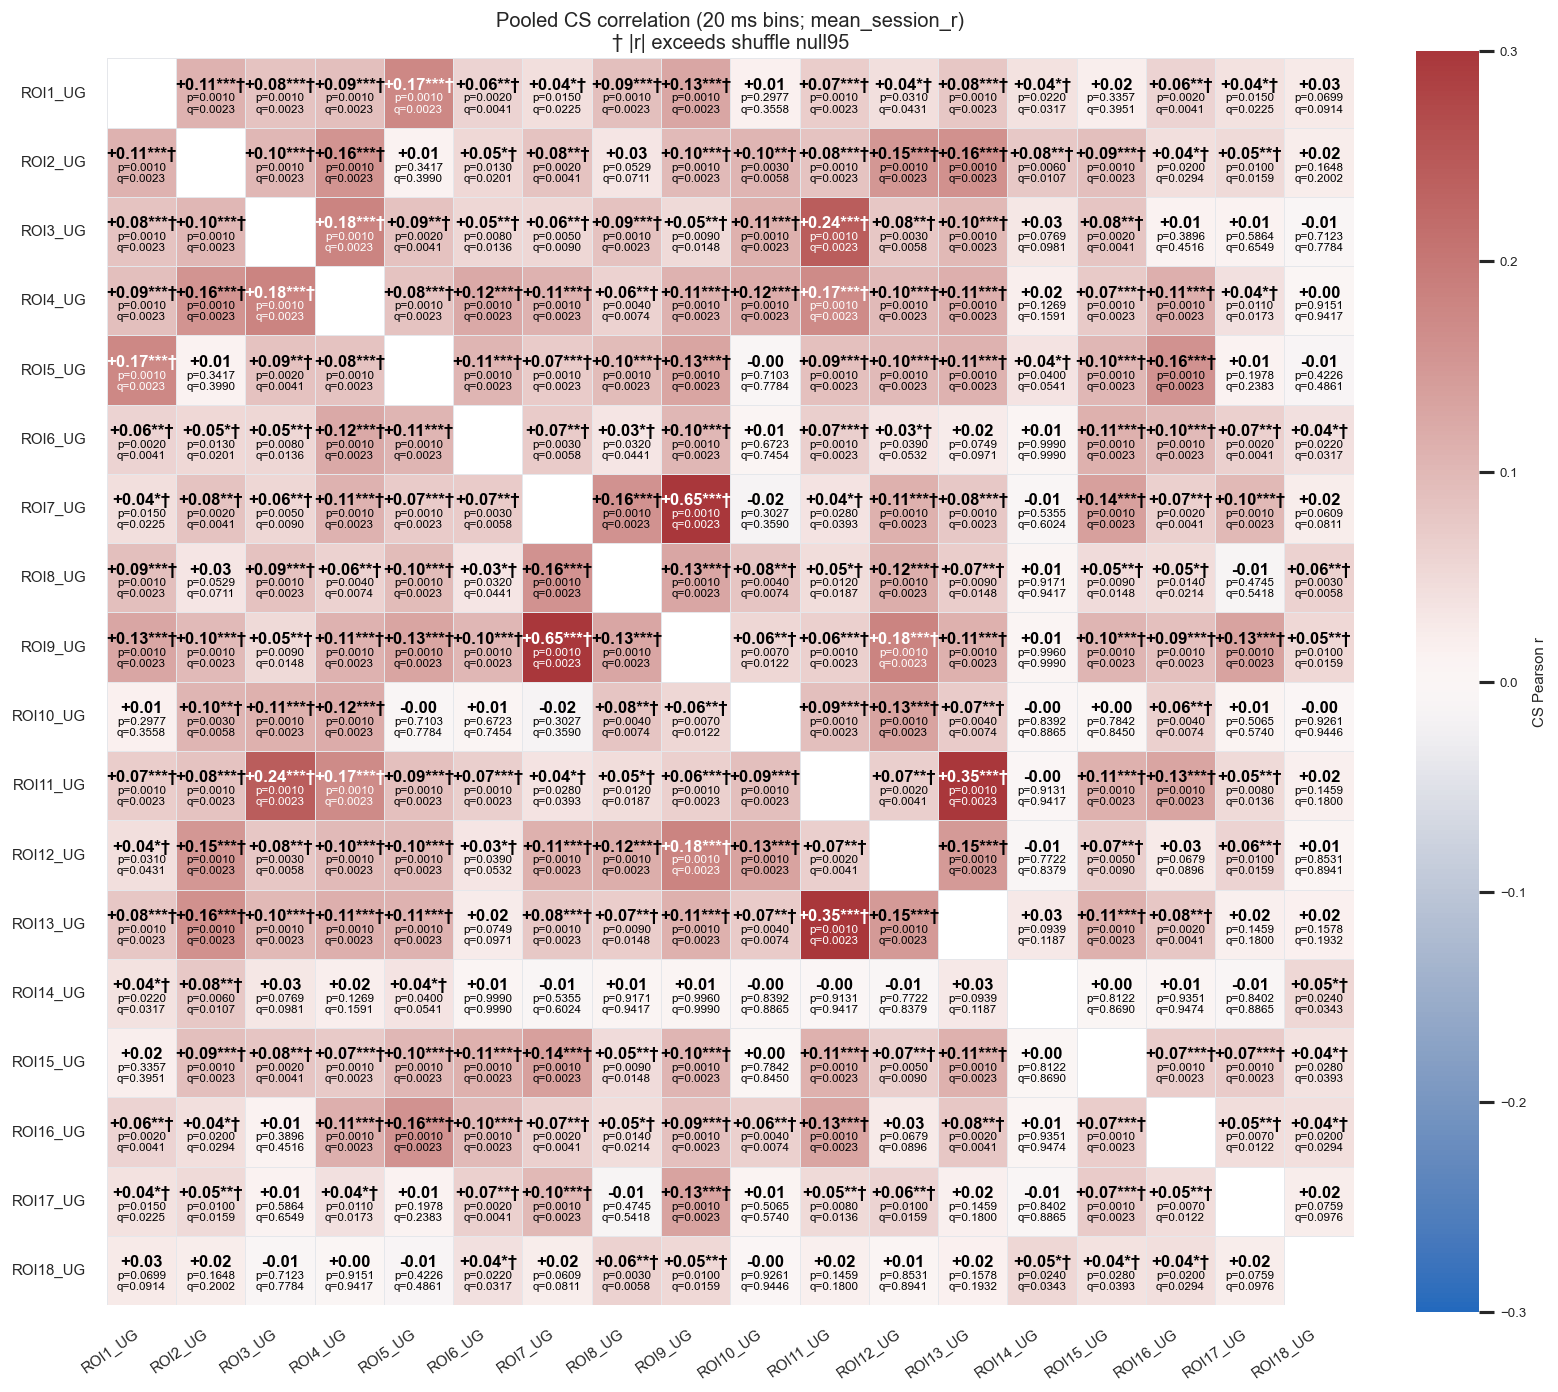

In [5]:
# ==============================
# SECONDARY CS METRIC: POOLED BINNED PEARSON CORRELATION
# ==============================
cs_rng = np.random.default_rng(int(CS_CORR_CONFIG['rng_seed']))
cs_rows = []
for i, j in combinations(range(n_cells), 2):
    chunks = []
    for session in sessions:
        edges = np.arange(session['time_ms'][0], session['time_ms'][-1] + CS_CORR_CONFIG['bin_ms'], CS_CORR_CONFIG['bin_ms'])
        if len(edges) < CS_CORR_CONFIG['min_bins'] + 1:
            continue
        count_i, _ = np.histogram(session['spike_times_cs'][i], bins=edges)
        count_j, _ = np.histogram(session['spike_times_cs'][j], bins=edges)
        chunks.append((count_i.astype(float), count_j.astype(float)))
    min_shift = max(1, int(round(CS_CORR_CONFIG['min_shift_fraction'] * np.median([len(x) for x, _ in chunks])))) if chunks else 1
    r, p, z, null_abs95 = _corr_with_session_shifts(chunks, CS_CORR_CONFIG['n_null_shuffles'], cs_rng, min_shift, CS_CORR_CONFIG['min_bins'], CS_CORR_CONFIG['pooling_mode'])
    cs_rows.append({'cell_i': cell_names[i], 'cell_j': cell_names[j], 'i': i, 'j': j, 'r': r, 'p': p, 'z': z, 'null_abs95': null_abs95, 'exceeds_null95': np.isfinite(r) and np.isfinite(null_abs95) and abs(r) > null_abs95, 'n_sessions': len(chunks)})
cs_pair_df = pd.DataFrame(cs_rows)
cs_pair_df['q'] = _bh_fdr(cs_pair_df['p'].values)
cs_pair_df['abs_r'] = cs_pair_df['r'].abs()
display_top(cs_pair_df, label='CS pair correlations', sort_by='abs_r')
cs_corr_mat, cs_p_mat, cs_q_mat, cs_null95_mat = _pair_matrices(cs_pair_df)
fig, _ = plot_corr_matrix(cs_corr_mat, cs_p_mat, cs_q_mat, f"Pooled CS correlation ({CS_CORR_CONFIG['bin_ms']:g} ms bins; {CS_CORR_CONFIG['pooling_mode']})", cbar_label='CS Pearson r', null95=cs_null95_mat)
plt.show()
plt.close(fig)


Subthreshold/Vm pair correlations: showing 12 of 153 rows


,cell_i,cell_j,i,j,r,p,z,null_abs95,exceeds_null95,n_sessions,q,abs_r
33,ROI3_UG,ROI4_UG,2,3,0.459689,0.004975,16.440536,0.054171,True,4,0.005399,0.459689
117,ROI10_UG,ROI11_UG,9,10,0.387909,0.004975,15.143289,0.050729,True,4,0.005399,0.387909
54,ROI4_UG,ROI11_UG,3,10,0.376288,0.004975,15.796612,0.048015,True,4,0.005399,0.376288
40,ROI3_UG,ROI11_UG,2,10,0.374719,0.004975,14.757408,0.051629,True,4,0.005399,0.374719
134,ROI12_UG,ROI15_UG,11,14,0.336522,0.004975,16.182570,0.041791,True,4,0.005399,0.336522
147,ROI15_UG,ROI16_UG,14,15,0.333927,0.004975,17.172069,0.038929,True,4,0.005399,0.333927
132,ROI12_UG,ROI13_UG,11,12,0.312597,0.004975,16.250418,0.039026,True,4,0.005399,0.312597
53,ROI4_UG,ROI10_UG,3,9,0.307209,0.004975,13.542320,0.043902,True,4,0.005399,0.307209
99,ROI8_UG,ROI10_UG,7,9,0.297520,0.004975,14.550986,0.039368,True,4,0.005399,0.297520
39,ROI3_UG,ROI10_UG,2,9,0.285989,0.004975,11.122261,0.054614,True,4,0.005399,0.285989


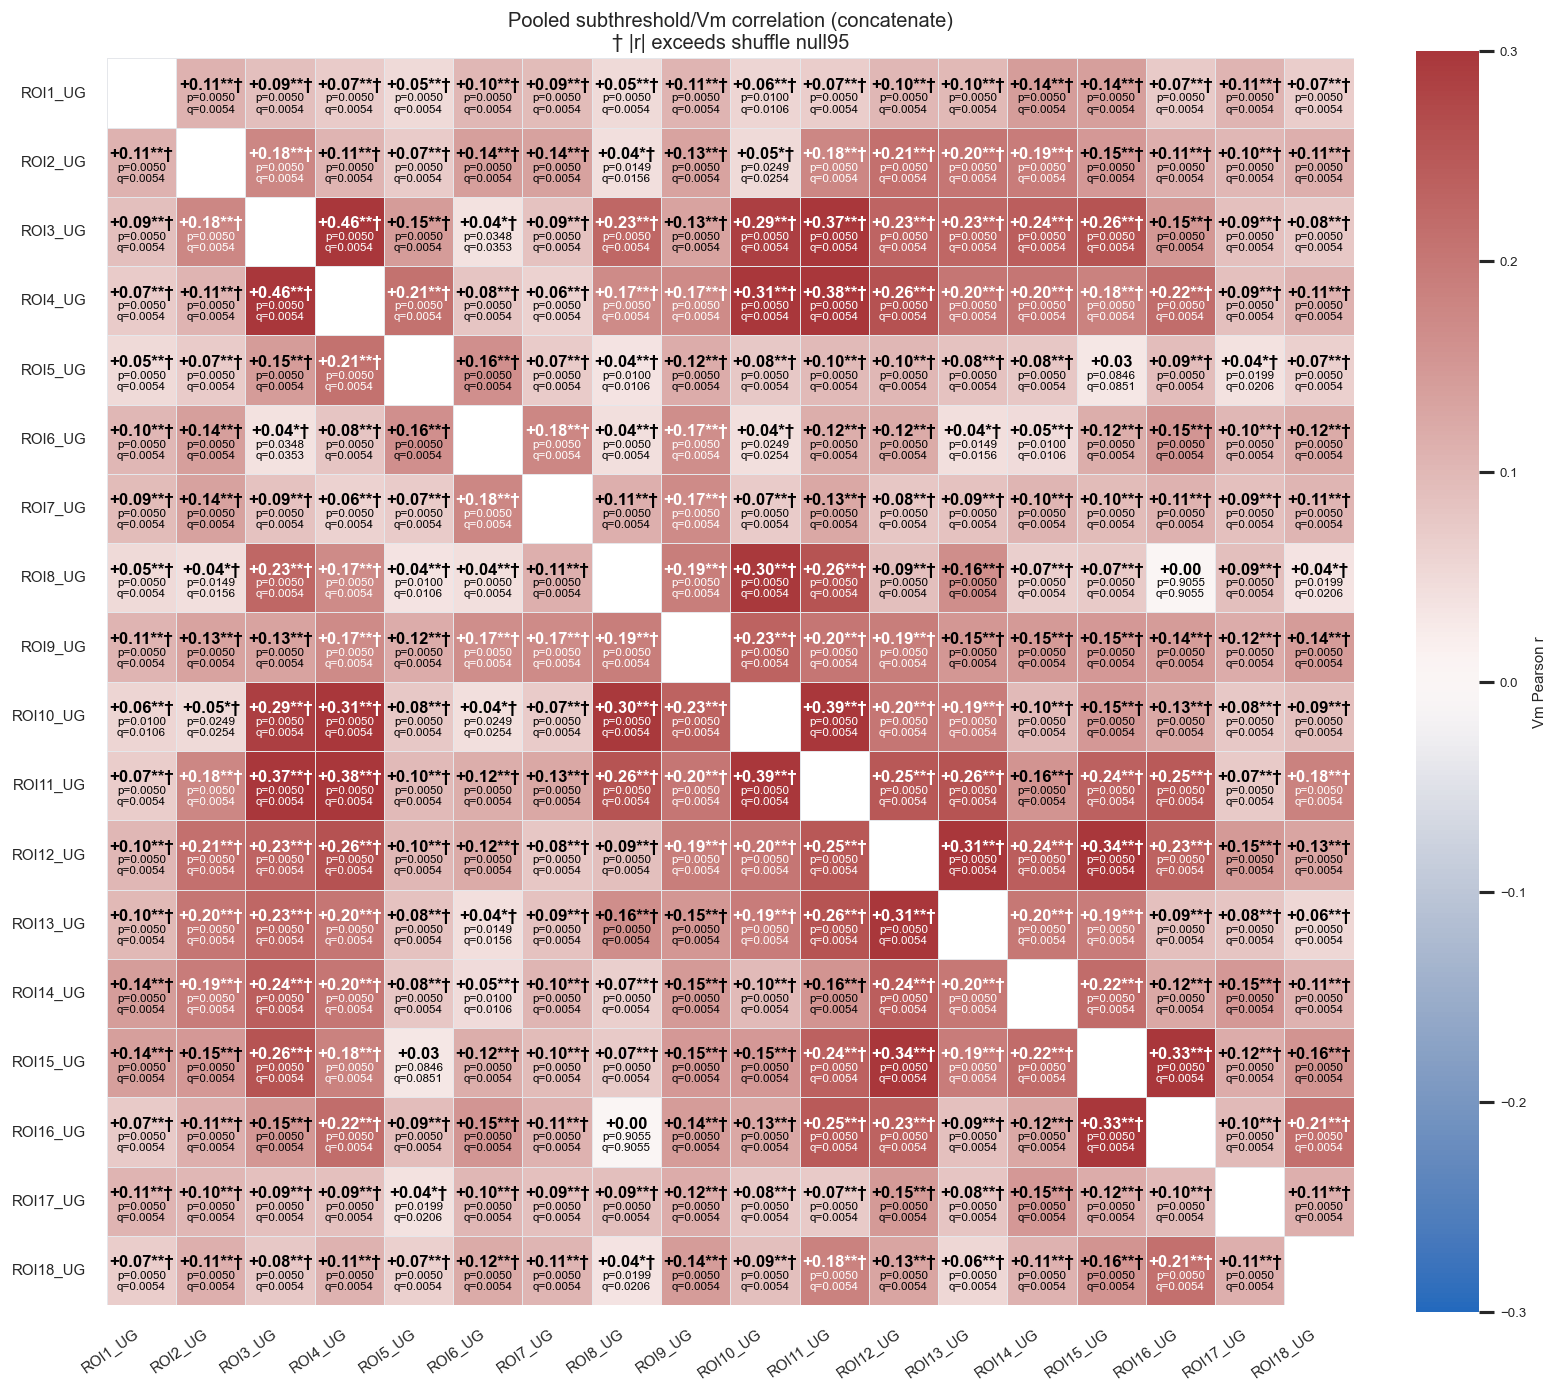

In [6]:
# ==============================
# POOLED SUBTHRESHOLD / Vm CORRELATION
# ==============================
vm_rng = np.random.default_rng(int(SUBTH_CORR_CONFIG['rng_seed']))
vm_rows = []
for i, j in combinations(range(n_cells), 2):
    chunks, shift_sizes = [], []
    for session in processed_sessions:
        fs = float(session['fs'])
        max_fs = SUBTH_CORR_CONFIG.get('max_fs_hz', None)
        stride = 1 if max_fs is None or float(max_fs) <= 0 else max(1, int(np.ceil(fs / float(max_fs))))
        x = np.asarray(session['subthreshold'][::stride, i], dtype=float)
        y = np.asarray(session['subthreshold'][::stride, j], dtype=float)
        max_n = int(SUBTH_CORR_CONFIG['max_samples_per_session'])
        if max_n > 0 and len(x) > max_n:
            sample_stride = int(np.ceil(len(x) / max_n))
            x, y = x[::sample_stride], y[::sample_stride]
            stride *= sample_stride
        good = np.isfinite(x) & np.isfinite(y)
        x, y = x[good], y[good]
        if len(x) < SUBTH_CORR_CONFIG['min_samples']:
            continue
        if bool(SUBTH_CORR_CONFIG.get('standardize_within_session', False)):
            x = (x - np.mean(x)) / (np.std(x) + 1e-12)
            y = (y - np.mean(y)) / (np.std(y) + 1e-12)
        chunks.append((x, y))
        effective_fs = fs / stride
        shift_sizes.append(max(1, int(round(SUBTH_CORR_CONFIG['min_shift_ms'] * effective_fs / 1000.0))))
    min_shift = int(np.median(shift_sizes)) if shift_sizes else 1
    r, p, z, null_abs95 = _corr_with_session_shifts(chunks, SUBTH_CORR_CONFIG['n_null_shuffles'], vm_rng, min_shift, SUBTH_CORR_CONFIG['min_samples'], SUBTH_CORR_CONFIG['pooling_mode'])
    vm_rows.append({'cell_i': cell_names[i], 'cell_j': cell_names[j], 'i': i, 'j': j, 'r': r, 'p': p, 'z': z, 'null_abs95': null_abs95, 'exceeds_null95': np.isfinite(r) and np.isfinite(null_abs95) and abs(r) > null_abs95, 'n_sessions': len(chunks)})
vm_pair_df = pd.DataFrame(vm_rows)
vm_pair_df['q'] = _bh_fdr(vm_pair_df['p'].values)
vm_pair_df['abs_r'] = vm_pair_df['r'].abs()
display_top(vm_pair_df, label='Subthreshold/Vm pair correlations', sort_by='abs_r')
vm_corr_mat, vm_p_mat, vm_q_mat, vm_null95_mat = _pair_matrices(vm_pair_df)
fig, _ = plot_corr_matrix(vm_corr_mat, vm_p_mat, vm_q_mat, f"Pooled subthreshold/Vm correlation ({SUBTH_CORR_CONFIG['pooling_mode']})", cbar_label='Vm Pearson r', null95=vm_null95_mat)
plt.show()
plt.close(fig)


STTC Δt=10 ms: 52/153 positive jitter-null95 edges
STTC Δt=20 ms: 66/153 positive jitter-null95 edges
STTC Δt=28 ms: 43/153 positive jitter-null95 edges
STTC Δt=50 ms: 7/153 positive jitter-null95 edges
STTC Δt=100 ms: 6/153 positive jitter-null95 edges
Primary CS STTC pairs (Δt=28 ms): showing 12 of 153 rows


,cell_i,cell_j,i,j,delta_ms,r,p,z,null_abs95,q,edge,binned_pearson_r,ccg_peak_r,ccg_peak_lag_ms
88,ROI7_UG,ROI9_UG,6,8,28.0,0.707190,0.004975,5.696761,0.473257,0.063433,True,0.654326,0.619046,0.0
126,ROI11_UG,ROI13_UG,10,12,28.0,0.388339,0.004975,3.165141,0.313669,0.063433,True,0.349437,0.298551,0.0
40,ROI3_UG,ROI11_UG,2,10,28.0,0.323764,0.004975,2.241640,0.306920,0.063433,True,0.243602,0.143065,0.0
18,ROI2_UG,ROI4_UG,1,3,28.0,0.309644,0.014925,2.149135,0.273995,0.114179,True,0.156561,0.104897,0.0
53,ROI4_UG,ROI10_UG,3,9,28.0,0.267079,0.019900,2.198641,0.233909,0.132382,True,0.119198,0.113441,0.0
54,ROI4_UG,ROI11_UG,3,10,28.0,0.261339,0.024876,2.017143,0.249695,0.140962,True,0.169677,0.136390,0.0
21,ROI2_UG,ROI7_UG,1,6,28.0,0.260451,0.004975,2.717727,0.211164,0.063433,True,0.084362,0.080862,-20.0
110,ROI9_UG,ROI12_UG,8,11,28.0,0.248528,0.009950,2.462218,0.213214,0.095149,True,0.181136,0.080976,0.0
113,ROI9_UG,ROI15_UG,8,14,28.0,0.241495,0.004975,3.383419,0.176717,0.063433,True,0.104994,0.083589,0.0
23,ROI2_UG,ROI9_UG,1,8,28.0,0.238630,0.049751,1.602963,0.234681,0.181237,True,0.096967,0.078373,-20.0


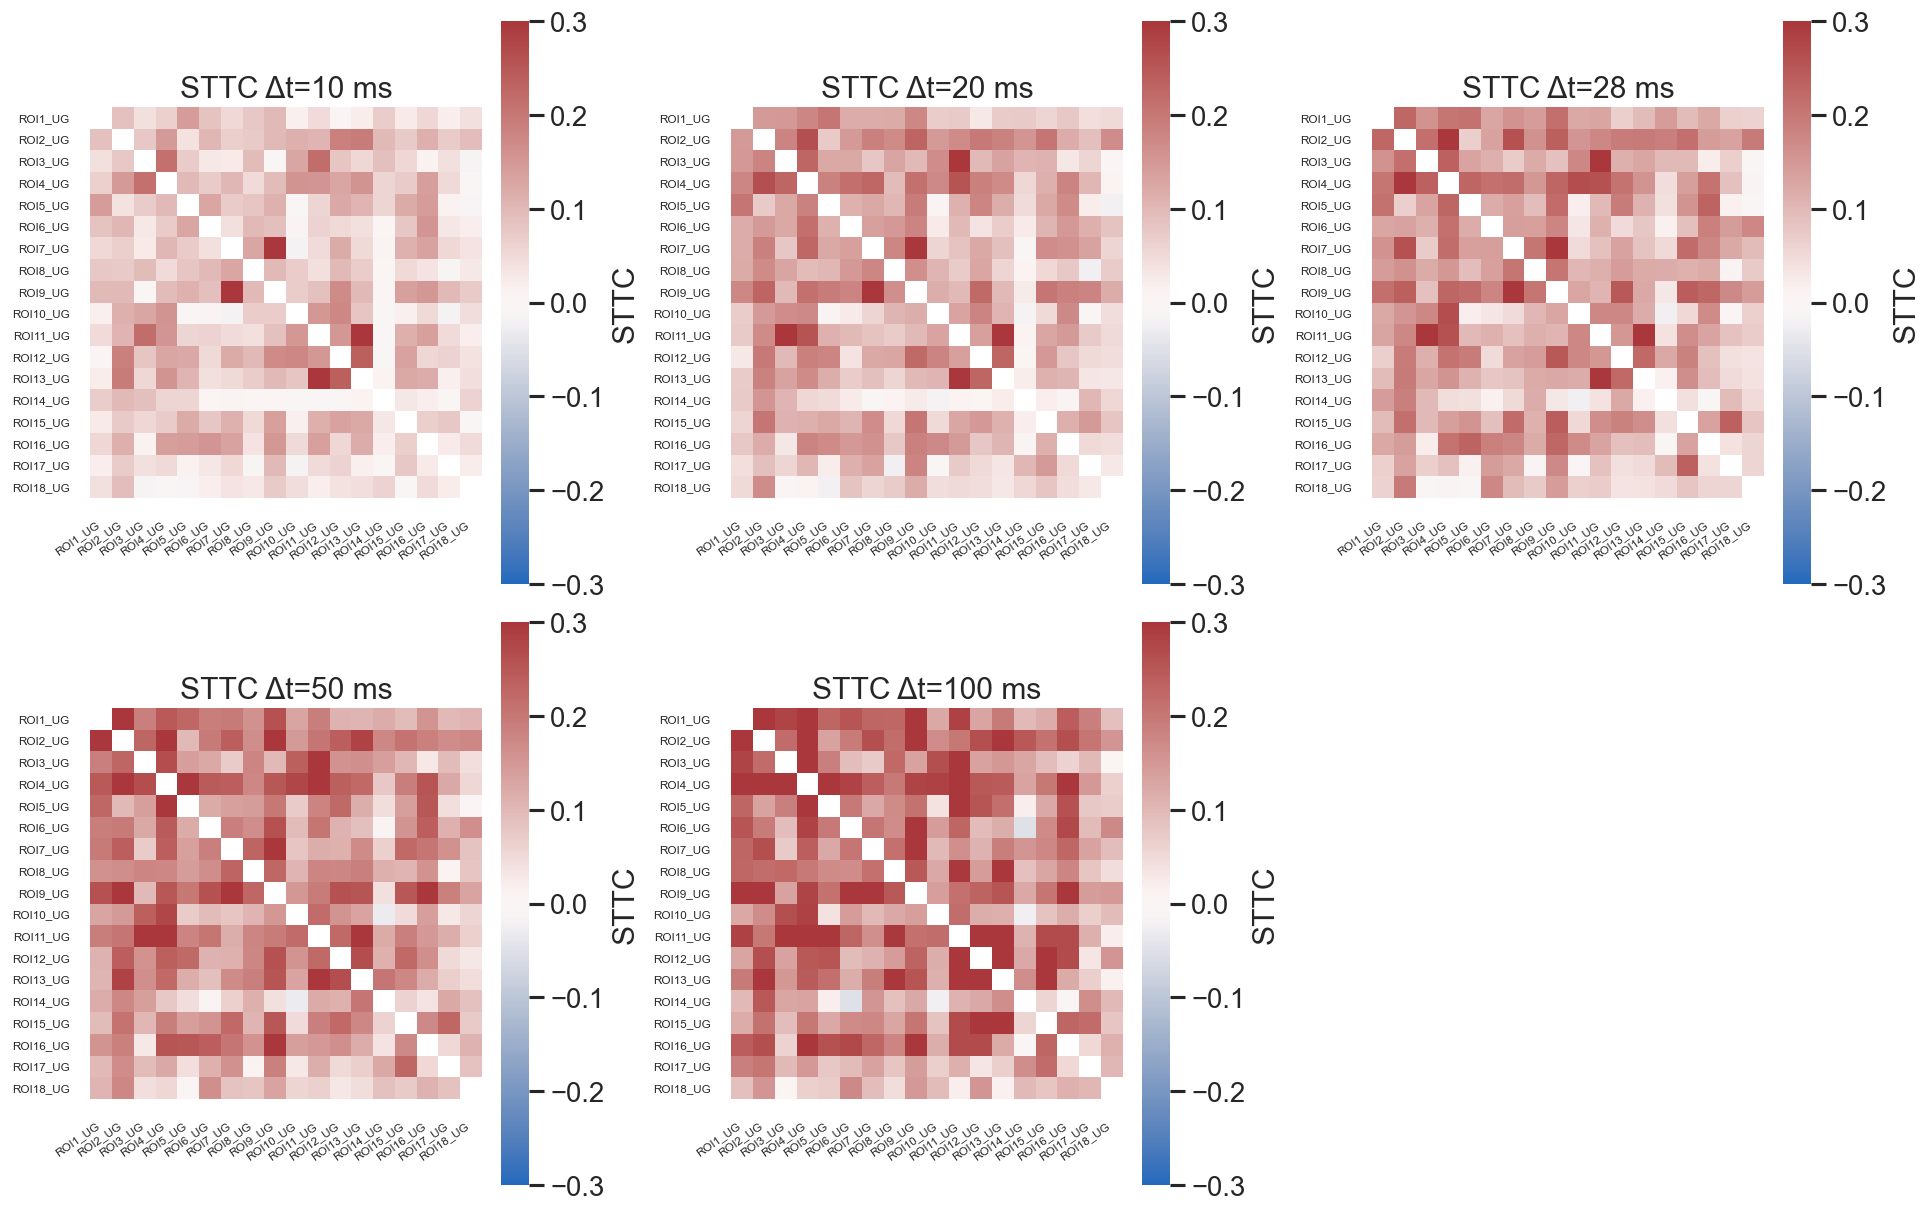

In [7]:
# ==============================
# PRIMARY CS SYNCHRONY: MULTI-WINDOW STTC + JITTER NULL
# ==============================
def _covered_fraction(events, dt_ms, start_ms, stop_ms):
    events = np.sort(_to_float_1d(events))
    duration = float(stop_ms - start_ms)
    if events.size == 0 or duration <= 0:
        return 0.0
    starts = np.maximum(events - dt_ms, start_ms)
    stops = np.minimum(events + dt_ms, stop_ms)
    covered = 0.0; current_start = float(starts[0]); current_stop = float(stops[0])
    for left, right in zip(starts[1:], stops[1:]):
        if left <= current_stop:
            current_stop = max(current_stop, float(right))
        else:
            covered += current_stop - current_start
            current_start, current_stop = float(left), float(right)
    covered += current_stop - current_start
    return float(np.clip(covered / duration, 0.0, 1.0))

def _coincidence_fraction(events_a, events_b, dt_ms):
    a, b = np.sort(_to_float_1d(events_a)), np.sort(_to_float_1d(events_b))
    if a.size == 0 or b.size == 0:
        return 0.0
    idx = np.searchsorted(b, a)
    left = np.where(idx > 0, np.abs(a - b[np.maximum(idx - 1, 0)]), np.inf)
    right_idx = np.minimum(idx, b.size - 1)
    right = np.where(idx < b.size, np.abs(a - b[right_idx]), np.inf)
    return float(np.mean(np.minimum(left, right) <= dt_ms))

def _sttc(events_a, events_b, dt_ms, start_ms, stop_ms):
    a, b = _to_float_1d(events_a), _to_float_1d(events_b)
    if a.size == 0 or b.size == 0:
        return np.nan
    pa = _coincidence_fraction(a, b, dt_ms); pb = _coincidence_fraction(b, a, dt_ms)
    ta = _covered_fraction(a, dt_ms, start_ms, stop_ms); tb = _covered_fraction(b, dt_ms, start_ms, stop_ms)
    denom_a, denom_b = 1.0 - pa * tb, 1.0 - pb * ta
    if abs(denom_a) < 1e-12 or abs(denom_b) < 1e-12:
        return np.nan
    return float(0.5 * ((pa - tb) / denom_a + (pb - ta) / denom_b))

def _nearest_event_distances(source, target):
    source, target = np.sort(_to_float_1d(source)), np.sort(_to_float_1d(target))
    if source.size == 0 or target.size == 0: return np.full(source.size, np.inf)
    idx = np.searchsorted(target, source); left_idx = np.maximum(idx - 1, 0); right_idx = np.minimum(idx, target.size - 1)
    left = np.where(idx > 0, np.abs(source - target[left_idx]), np.inf); right = np.where(idx < target.size, np.abs(source - target[right_idx]), np.inf)
    return np.minimum(left, right)

def _sttc_multi_dt(events_a, events_b, dt_values, start_ms, stop_ms, ta=None, tb=None):
    a, b = np.sort(_to_float_1d(events_a)), np.sort(_to_float_1d(events_b)); dt_values = np.asarray(dt_values, float)
    if a.size == 0 or b.size == 0: return np.full(dt_values.size, np.nan)
    pa = np.mean(_nearest_event_distances(a, b)[:, None] <= dt_values[None, :], axis=0)
    pb = np.mean(_nearest_event_distances(b, a)[:, None] <= dt_values[None, :], axis=0)
    ta = np.asarray([_covered_fraction(a, dt, start_ms, stop_ms) for dt in dt_values]) if ta is None else np.asarray(ta, float)
    tb = np.asarray([_covered_fraction(b, dt, start_ms, stop_ms) for dt in dt_values]) if tb is None else np.asarray(tb, float)
    denom_a, denom_b = 1.0 - pa * tb, 1.0 - pb * ta
    result = 0.5 * (np.divide(pa - tb, denom_a, out=np.full_like(pa, np.nan), where=np.abs(denom_a) >= 1e-12) + np.divide(pb - ta, denom_b, out=np.full_like(pb, np.nan), where=np.abs(denom_b) >= 1e-12))
    return result

def _jitter_events(events, start_ms, stop_ms, jitter_ms, rng):
    events = _to_float_1d(events)
    duration = float(stop_ms - start_ms)
    if events.size == 0 or duration <= 0:
        return events.copy()
    offsets = rng.uniform(-float(jitter_ms), float(jitter_ms), size=events.size)
    return np.sort((events + offsets - start_ms) % duration + start_ms)

def _pooled_sttc(i, j, dt_ms, jitter_second=False, rng=None):
    values = []
    for session in sessions:
        start_ms, stop_ms = float(session['time_ms'][0]), float(session['time_ms'][-1])
        a, b = session['spike_times_cs'][i], session['spike_times_cs'][j]
        if jitter_second:
            b = _jitter_events(b, start_ms, stop_ms, STTC_CONFIG['jitter_window_ms'], rng)
        value = _sttc(a, b, dt_ms, start_ms, stop_ms)
        if np.isfinite(value): values.append(value)
    return float(np.mean(values)) if values else np.nan

sttc_rng = np.random.default_rng(int(STTC_CONFIG['rng_seed'])); sttc_dt_values = np.asarray(STTC_CONFIG['delta_ms'], float); sttc_n_shuffles = int(STTC_CONFIG['n_jitter_shuffles'])
# Cache each jittered CS train and its covered-time terms once, then reuse them across every pair and Δt.
sttc_session_cache = []
for session in sessions:
    start_ms, stop_ms = float(session['time_ms'][0]), float(session['time_ms'][-1]); original = [np.sort(_to_float_1d(x)) for x in session['spike_times_cs']]
    original_t = np.asarray([[_covered_fraction(x, dt, start_ms, stop_ms) for dt in sttc_dt_values] for x in original])
    jittered = [[_jitter_events(original[c], start_ms, stop_ms, STTC_CONFIG['jitter_window_ms'], sttc_rng) for _ in range(sttc_n_shuffles)] for c in range(n_cells)]
    jittered_t = np.asarray([[[_covered_fraction(x, dt, start_ms, stop_ms) for dt in sttc_dt_values] for x in jittered[c]] for c in range(n_cells)])
    sttc_session_cache.append({'start': start_ms, 'stop': stop_ms, 'original': original, 'original_t': original_t, 'jittered': jittered, 'jittered_t': jittered_t})

sttc_rows_by_dt = {float(dt): [] for dt in sttc_dt_values}
for i, j in combinations(range(n_cells), 2):
    observed_by_session = []; null_sum = np.zeros((sttc_n_shuffles, len(sttc_dt_values))); null_count = np.zeros_like(null_sum)
    for cache in sttc_session_cache:
        observed_by_session.append(_sttc_multi_dt(cache['original'][i], cache['original'][j], sttc_dt_values, cache['start'], cache['stop'], cache['original_t'][i], cache['original_t'][j]))
        for shuffle_idx in range(sttc_n_shuffles):
            values = _sttc_multi_dt(cache['original'][i], cache['jittered'][j][shuffle_idx], sttc_dt_values, cache['start'], cache['stop'], cache['original_t'][i], cache['jittered_t'][j, shuffle_idx])
            finite = np.isfinite(values); null_sum[shuffle_idx, finite] += values[finite]; null_count[shuffle_idx, finite] += 1
    observed = np.nanmean(np.asarray(observed_by_session), axis=0); null_all = np.divide(null_sum, null_count, out=np.full_like(null_sum, np.nan), where=null_count > 0)
    for dt_idx, dt_ms in enumerate(sttc_dt_values):
        null = null_all[:, dt_idx]; null = null[np.isfinite(null)]; obs = observed[dt_idx]
        p = (1 + np.sum(np.abs(null) >= abs(obs))) / (len(null) + 1) if null.size and np.isfinite(obs) else np.nan
        null95 = float(np.percentile(np.abs(null), 95)) if null.size else np.nan; z = float((obs - np.mean(null)) / (np.std(null) + 1e-12)) if null.size and np.isfinite(obs) else np.nan
        sttc_rows_by_dt[float(dt_ms)].append({'cell_i': cell_names[i], 'cell_j': cell_names[j], 'i': i, 'j': j, 'delta_ms': float(dt_ms), 'r': obs, 'p': p, 'z': z, 'null_abs95': null95})

sttc_pair_tables = {}; sttc_matrices = {}; sttc_null95_matrices = {}
for dt_ms in sttc_dt_values:
    table = pd.DataFrame(sttc_rows_by_dt[float(dt_ms)]); table['q'] = _bh_fdr(table['p'].to_numpy())
    table['edge'] = np.isfinite(table['r']) & np.isfinite(table['null_abs95']) & (table['r'] > table['null_abs95'])
    if bool(NETWORK_CONFIG['edge_require_fdr']): table['edge'] &= table['q'] < float(NETWORK_CONFIG['fdr_alpha'])
    sttc_pair_tables[float(dt_ms)] = table; sttc_matrices[float(dt_ms)] = _pair_matrices(table)[0]; sttc_null95_matrices[float(dt_ms)] = _pair_matrices(table)[3]
    print(f'STTC Δt={dt_ms:g} ms: {int(table["edge"].sum())}/{len(table)} positive jitter-null95 edges')

def _pooled_ccg_peak(i, j, bin_ms=10.0, max_lag_ms=100.0):
    lag_bins = int(round(max_lag_ms / bin_ms)); curves = []
    for session in sessions:
        edges = np.arange(session['time_ms'][0], session['time_ms'][-1] + bin_ms, bin_ms)
        a = np.histogram(session['spike_times_cs'][i], edges)[0].astype(float)
        b = np.histogram(session['spike_times_cs'][j], edges)[0].astype(float)
        if np.std(a) <= 0 or np.std(b) <= 0: continue
        a = (a - np.mean(a)) / np.std(a); b = (b - np.mean(b)) / np.std(b)
        full = np.correlate(a, b, mode='full') / len(a); center = len(a) - 1
        curves.append(full[center - lag_bins:center + lag_bins + 1])
    if not curves: return np.nan, np.nan
    curve = np.mean(curves, axis=0); lags = np.arange(-lag_bins, lag_bins + 1) * bin_ms
    peak = int(np.nanargmax(curve))
    return float(curve[peak]), float(lags[peak])

primary_dt_ms = min(STTC_CONFIG['delta_ms'], key=lambda value: abs(float(value) - 28.0))
cs_primary_pair_df = sttc_pair_tables[float(primary_dt_ms)].copy()
binned_lookup = cs_pair_df.set_index(['i', 'j'])['r']
cs_primary_pair_df['binned_pearson_r'] = [binned_lookup.get((int(i), int(j)), np.nan) for i, j in zip(cs_primary_pair_df['i'], cs_primary_pair_df['j'])]
ccg = [_pooled_ccg_peak(int(i), int(j)) for i, j in zip(cs_primary_pair_df['i'], cs_primary_pair_df['j'])]
cs_primary_pair_df['ccg_peak_r'] = [value[0] for value in ccg]; cs_primary_pair_df['ccg_peak_lag_ms'] = [value[1] for value in ccg]
cs_primary_mat, cs_primary_p_mat, cs_primary_q_mat, cs_primary_null95_mat = _pair_matrices(cs_primary_pair_df)
display_top(cs_primary_pair_df, label=f'Primary CS STTC pairs (Δt={primary_dt_ms:g} ms)', sort_by='r')

fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
for ax, dt_ms in zip(axes.flat, STTC_CONFIG['delta_ms']):
    matrix = sttc_matrices[float(dt_ms)]
    sns.heatmap(matrix, ax=ax, cmap='vlag', center=0, vmin=-0.3, vmax=0.3, square=True, xticklabels=cell_names, yticklabels=cell_names, cbar_kws={'label': 'STTC'})
    ax.set_title(f'STTC Δt={dt_ms:g} ms')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=7); ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
for ax in axes.flat[len(STTC_CONFIG['delta_ms']):]: ax.axis('off')
plt.show(); plt.close(fig)



Shuffle-defined network membership: showing 12 of 18 rows


,cell,CS_microband,Vm_component,CS_degree,Vm_degree
8,ROI9_UG,1,1,11,17
3,ROI4_UG,1,1,9,17
6,ROI7_UG,1,1,8,17
14,ROI15_UG,1,1,6,16
15,ROI16_UG,1,1,6,16
1,ROI2_UG,1,1,6,17
17,ROI18_UG,1,1,5,17
4,ROI5_UG,1,1,5,16
10,ROI11_UG,1,1,4,17
11,ROI12_UG,1,1,4,17


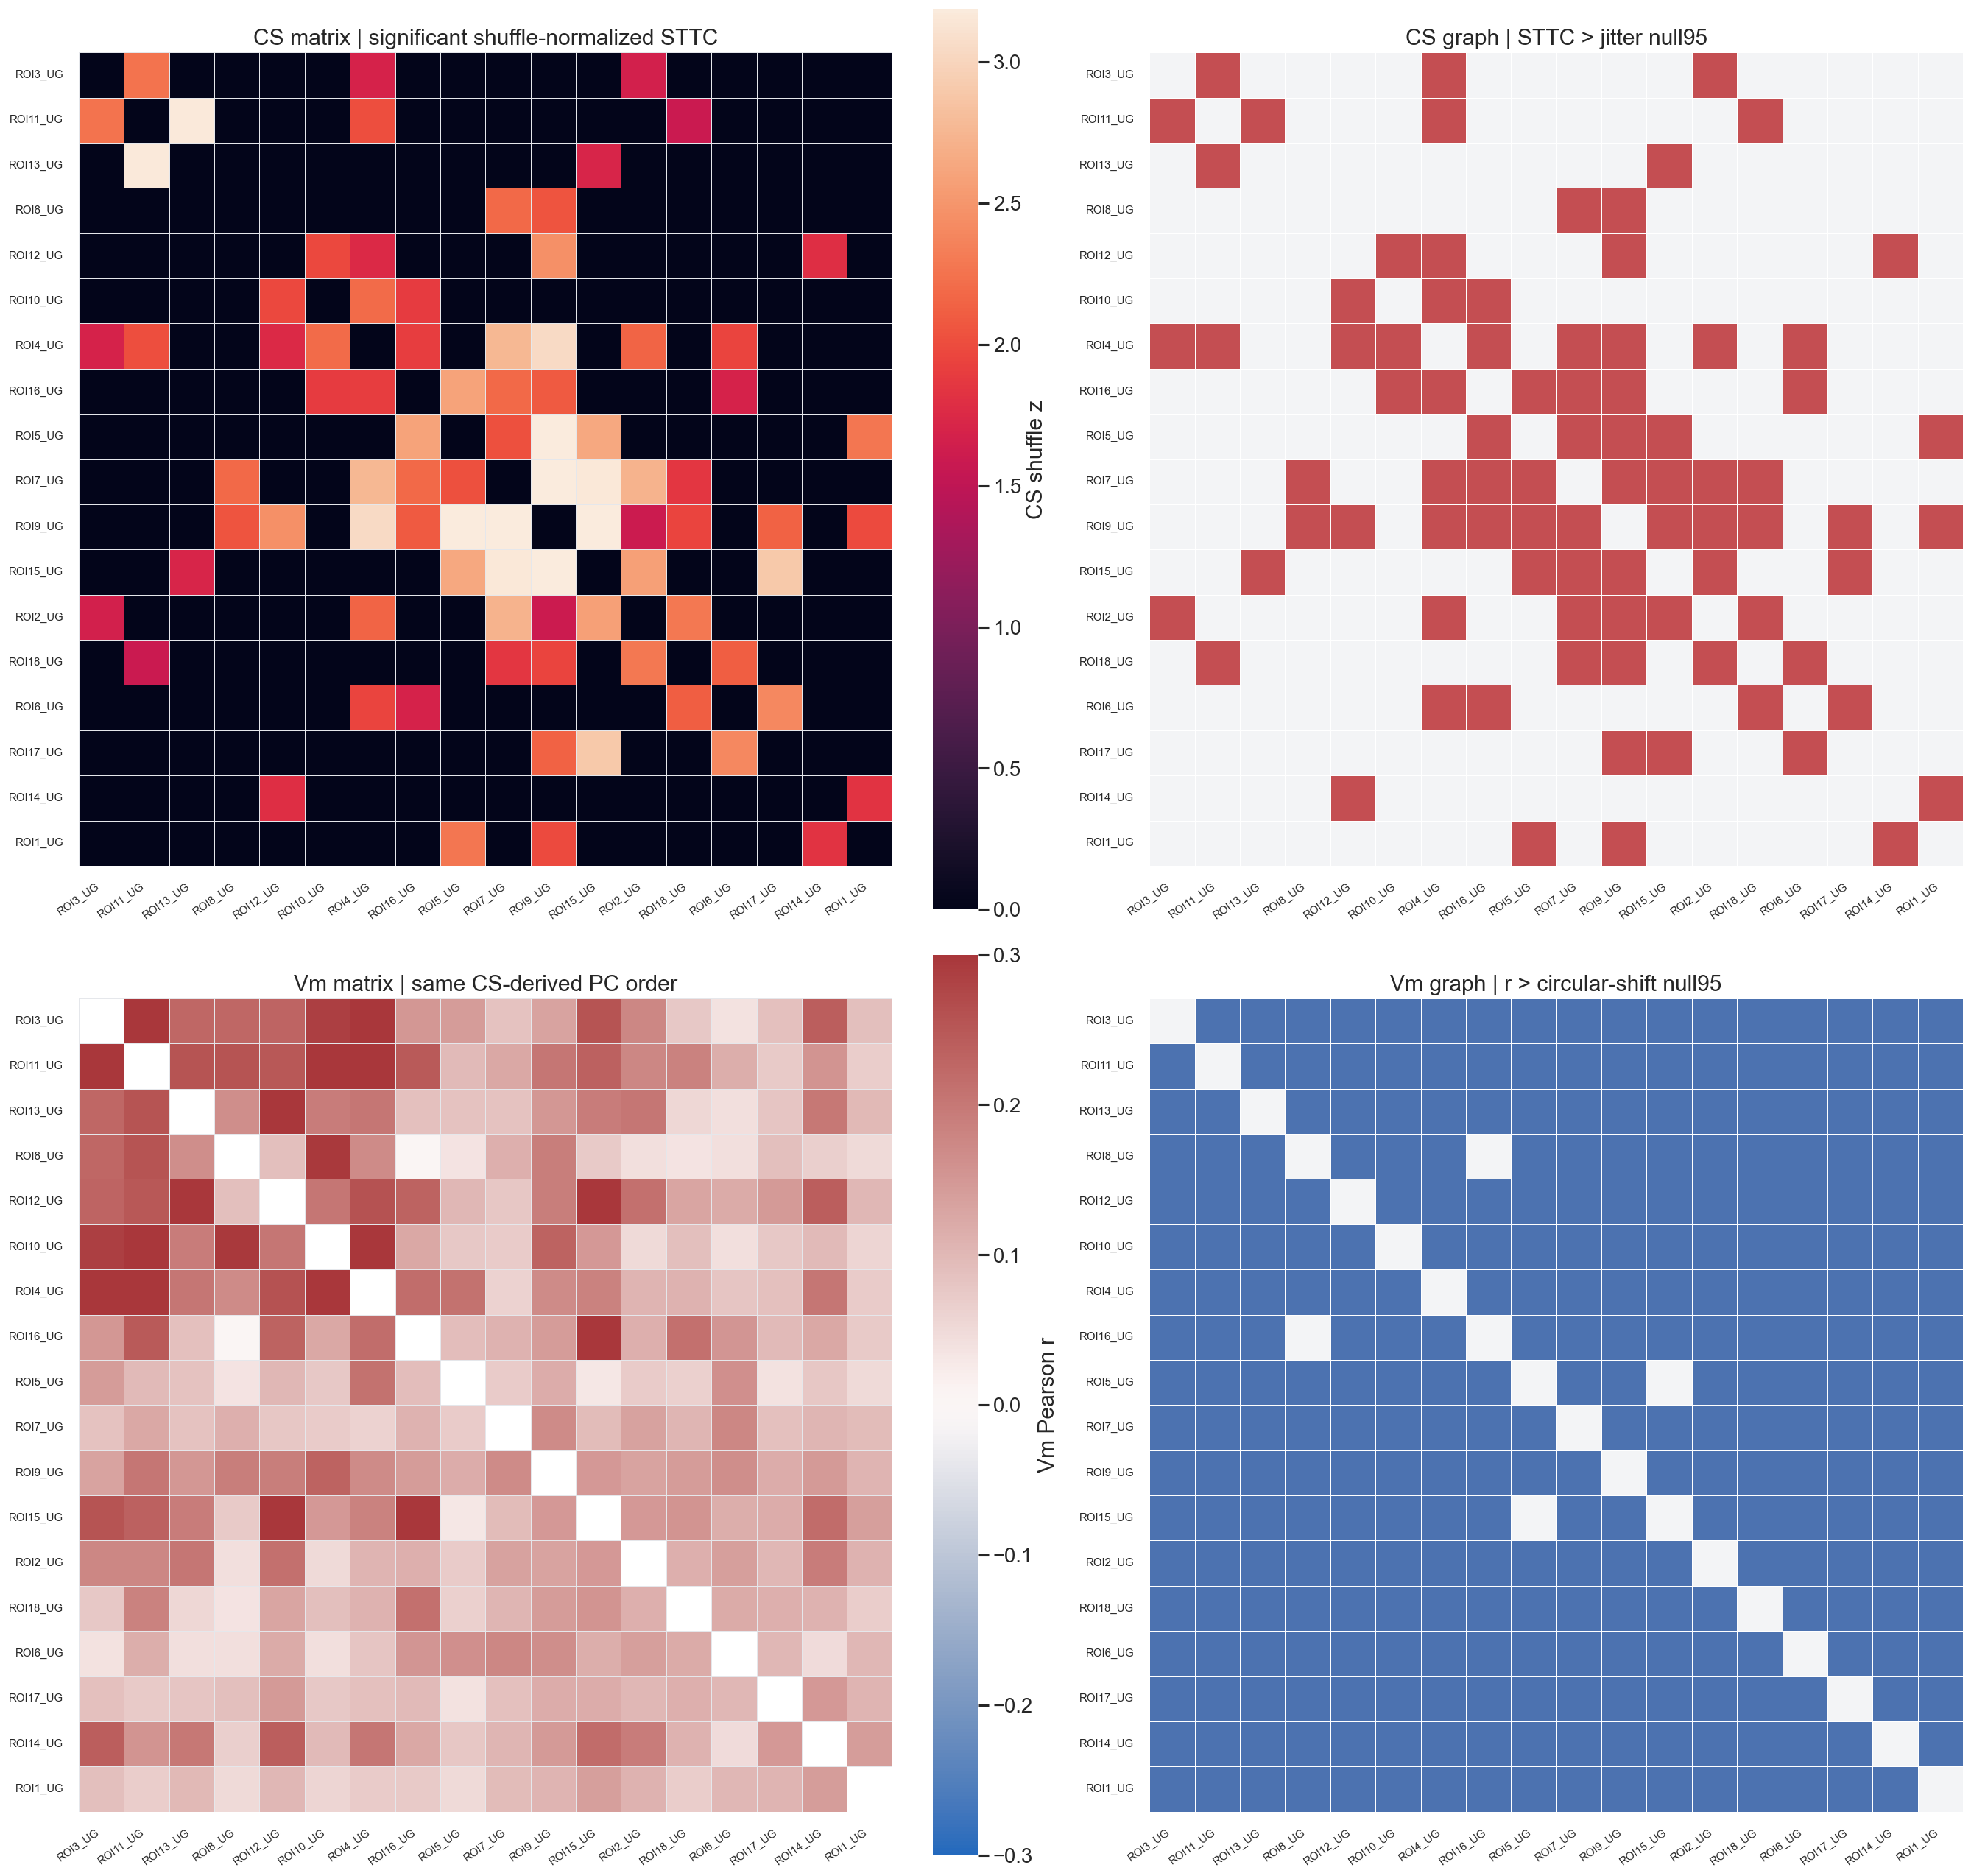

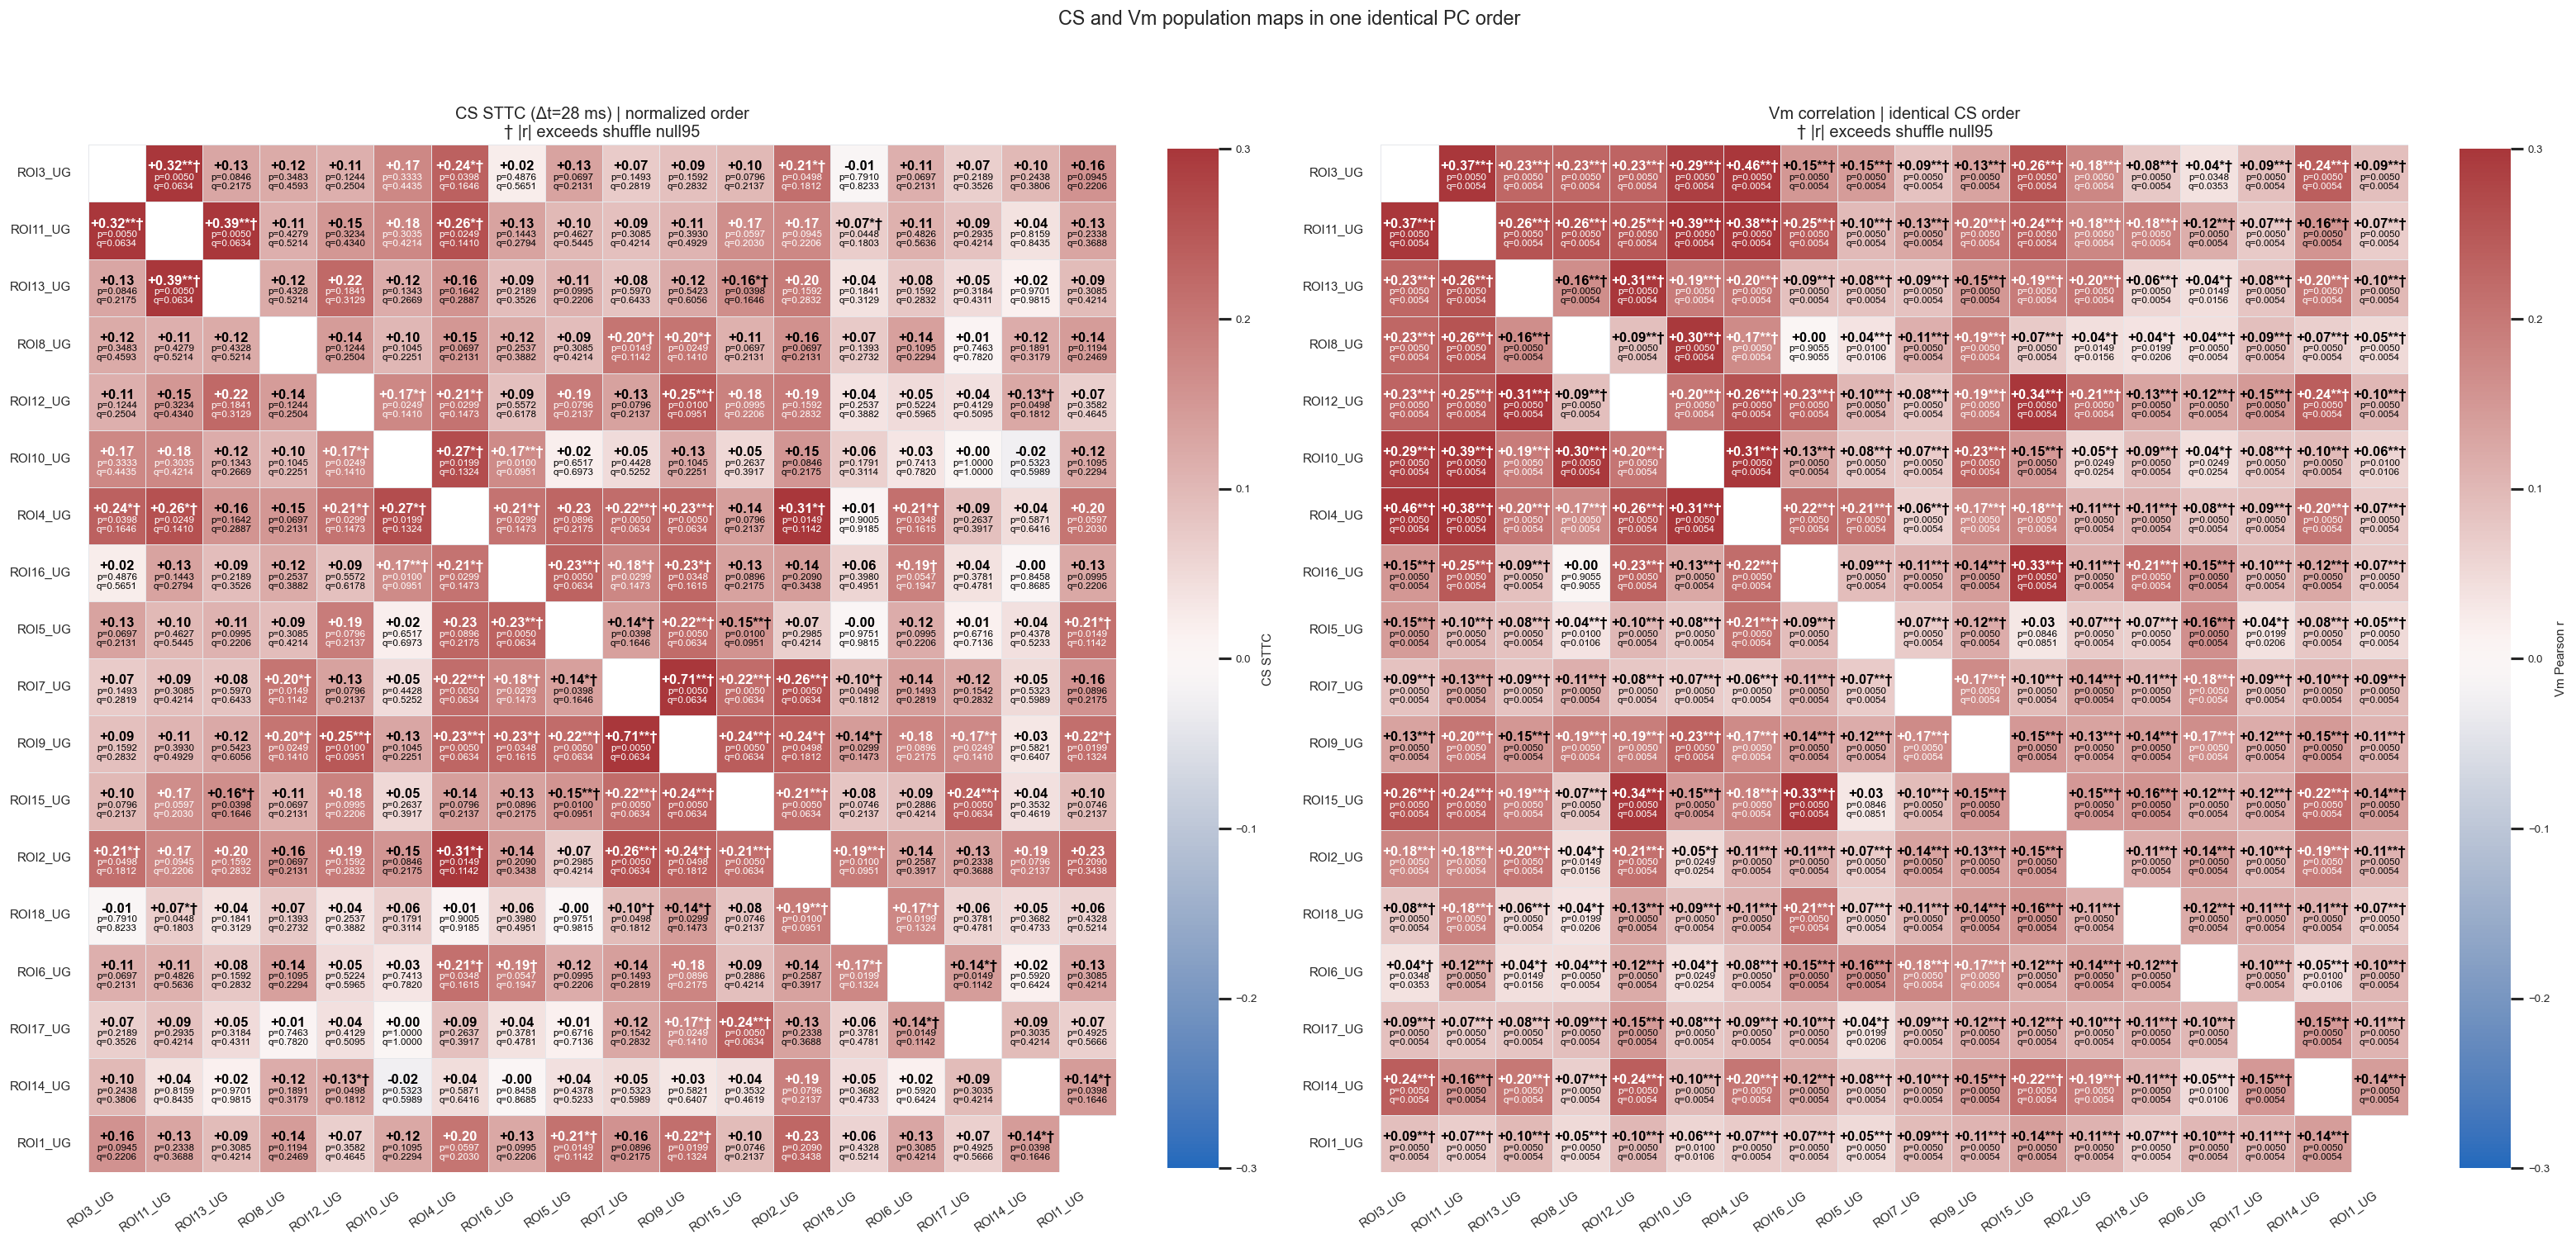

In [8]:
# ==============================
# SHUFFLE-NORMALIZED CS NETWORK AND MICROBANDS
# ==============================
def _matrix_from_pairs(pair_df, column, diagonal=np.nan):
    matrix = np.full((n_cells, n_cells), np.nan, dtype=float)
    for row in pair_df.itertuples(index=False):
        matrix[int(row.i), int(row.j)] = matrix[int(row.j), int(row.i)] = float(getattr(row, column))
    np.fill_diagonal(matrix, diagonal)
    return matrix

def _positive_edge_matrix(corr, null95, qmat):
    edge = np.isfinite(corr) & np.isfinite(null95) & (corr > null95)
    if bool(NETWORK_CONFIG['edge_require_fdr']):
        edge &= np.isfinite(qmat) & (qmat < float(NETWORK_CONFIG['fdr_alpha']))
    np.fill_diagonal(edge, False)
    return edge

def _component_labels(edge_matrix):
    _, labels = connected_components(csr_matrix(edge_matrix.astype(int)), directed=False, return_labels=True)
    return labels.astype(int) + 1

cs_z_mat = _matrix_from_pairs(cs_primary_pair_df, 'z', diagonal=0.0)
cs_excess_mat = cs_primary_mat - cs_primary_null95_mat
np.fill_diagonal(cs_excess_mat, 0.0)
cs_edge_mat = _positive_edge_matrix(cs_primary_mat, cs_primary_null95_mat, cs_primary_q_mat)
vm_edge_mat = _positive_edge_matrix(vm_corr_mat, vm_null95_mat, vm_q_mat)
cs_microbands = _component_labels(cs_edge_mat)
vm_components = _component_labels(vm_edge_mat)

# Hierarchical ordering uses only significant, positive shuffle-normalized CS strength.
cs_weighted_z = np.where(cs_edge_mat & np.isfinite(cs_z_mat), np.maximum(cs_z_mat, 0.0), 0.0)
max_weight = float(np.nanmax(cs_weighted_z)) if np.any(cs_weighted_z > 0) else 0.0
if n_cells > 2 and max_weight > 0:
    similarity = np.clip(cs_weighted_z / max_weight, 0.0, 1.0)
    np.fill_diagonal(similarity, 1.0)
    distance = 1.0 - similarity
    np.fill_diagonal(distance, 0.0)
    condensed = squareform(distance, checks=False)
    cs_tree = linkage(condensed, method=CLUSTER_CONFIG['method'])
    cs_tree = optimal_leaf_ordering(cs_tree, condensed)
    cs_order = leaves_list(cs_tree).astype(int)
else:
    cs_order = np.arange(n_cells, dtype=int)

cluster_membership = pd.DataFrame({'cell': cell_names, 'CS_microband': cs_microbands, 'Vm_component': vm_components})
cluster_membership['CS_degree'] = np.sum(cs_edge_mat, axis=1)
cluster_membership['Vm_degree'] = np.sum(vm_edge_mat, axis=1)
display_top(cluster_membership.sort_values(['CS_microband', 'CS_degree', 'cell'], ascending=[True, False, True]), label='Shuffle-defined network membership')

ordered_labels = [cell_names[i] for i in cs_order]
fig, axes = plt.subplots(2, 2, figsize=(max(12, 0.9 * n_cells + 6), max(10, 0.9 * n_cells + 5)), constrained_layout=True)
z_show = cs_weighted_z[np.ix_(cs_order, cs_order)]
z_max = max(3.0, float(np.nanpercentile(z_show[z_show > 0], 95))) if np.any(z_show > 0) else 3.0
sns.heatmap(z_show, ax=axes[0, 0], cmap='rocket', vmin=0, vmax=z_max, square=True, xticklabels=ordered_labels, yticklabels=ordered_labels, cbar_kws={'label': 'CS shuffle z'}, linewidths=0.5, linecolor='#E5E7EB')
axes[0, 0].set_title('CS matrix | significant shuffle-normalized STTC')
sns.heatmap(cs_edge_mat[np.ix_(cs_order, cs_order)].astype(int), ax=axes[0, 1], cmap=['#F3F4F6', '#C44E52'], vmin=0, vmax=1, square=True, xticklabels=ordered_labels, yticklabels=ordered_labels, cbar=False, linewidths=0.5, linecolor='white')
axes[0, 1].set_title('CS graph | STTC > jitter null95')
sns.heatmap(vm_corr_mat[np.ix_(cs_order, cs_order)], ax=axes[1, 0], cmap='vlag', center=0, vmin=CORR_HEATMAP_SCALE['vmin'], vmax=CORR_HEATMAP_SCALE['vmax'], square=True, xticklabels=ordered_labels, yticklabels=ordered_labels, cbar_kws={'label': 'Vm Pearson r'}, linewidths=0.5, linecolor='#E5E7EB')
axes[1, 0].set_title('Vm matrix | same CS-derived PC order')
sns.heatmap(vm_edge_mat[np.ix_(cs_order, cs_order)].astype(int), ax=axes[1, 1], cmap=['#F3F4F6', '#4C72B0'], vmin=0, vmax=1, square=True, xticklabels=ordered_labels, yticklabels=ordered_labels, cbar=False, linewidths=0.5, linecolor='white')
axes[1, 1].set_title('Vm graph | r > circular-shift null95')
for ax in axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=CORR_MATRIX_STYLE['cell_name_fontsize'])
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=CORR_MATRIX_STYLE['cell_name_fontsize'])
plt.show()
plt.close(fig)

# Keep the same CS-derived order on both raw matrices for direct visual comparison.
fig, axes = plt.subplots(1, 2, figsize=(max(13, 1.05 * n_cells + 7), max(6, 0.55 * n_cells + 3)), constrained_layout=True)
plot_corr_matrix(cs_primary_mat, cs_primary_p_mat, cs_primary_q_mat, f'CS STTC (Δt={primary_dt_ms:g} ms) | normalized order', order=cs_order, cbar_label='CS STTC', ax=axes[0], null95=cs_primary_null95_mat)
plot_corr_matrix(vm_corr_mat, vm_p_mat, vm_q_mat, 'Vm correlation | identical CS order', order=cs_order, cbar_label='Vm Pearson r', ax=axes[1], null95=vm_null95_mat)
fig.suptitle('CS and Vm population maps in one identical PC order', fontsize=14)
plt.show()
plt.close(fig)


In [9]:
# ==============================
# CS TEMPORAL EDGE STABILITY
# ==============================
stability_rng = np.random.default_rng(int(CS_STABILITY_CONFIG['rng_seed']))
stability_counts = np.zeros((n_cells, n_cells), dtype=float); stability_valid = np.zeros((n_cells, n_cells), dtype=float)
stability_block_rows = []
for session in sessions:
    block_edges = np.linspace(float(session['time_ms'][0]), float(session['time_ms'][-1]), int(CS_STABILITY_CONFIG['blocks_per_session']) + 1)
    for block_idx, (block_start, block_stop) in enumerate(zip(block_edges[:-1], block_edges[1:])):
        block_spikes = []
        for cell_events in session['spike_times_cs']:
            values = np.sort(_to_float_1d(cell_events)); block_spikes.append(values[(values >= block_start) & (values < block_stop)])
        dt_array = np.asarray([float(primary_dt_ms)]); n_block_shuffles = int(CS_STABILITY_CONFIG['n_jitter_shuffles'])
        block_t = np.asarray([_covered_fraction(x, float(primary_dt_ms), block_start, block_stop) for x in block_spikes])
        block_jittered = [[_jitter_events(block_spikes[c], block_start, block_stop, STTC_CONFIG['jitter_window_ms'], stability_rng) for _ in range(n_block_shuffles)] for c in range(n_cells)]
        block_jittered_t = np.asarray([[_covered_fraction(x, float(primary_dt_ms), block_start, block_stop) for x in block_jittered[c]] for c in range(n_cells)])
        for i, j in combinations(range(n_cells), 2):
            spikes_i, spikes_j = block_spikes[i], block_spikes[j]
            if min(len(spikes_i), len(spikes_j)) < int(CS_STABILITY_CONFIG['min_events_per_cell_block']): continue
            observed = _sttc_multi_dt(spikes_i, spikes_j, dt_array, block_start, block_stop, [block_t[i]], [block_t[j]])[0]
            null = np.asarray([_sttc_multi_dt(spikes_i, block_jittered[j][shuffle_idx], dt_array, block_start, block_stop, [block_t[i]], [block_jittered_t[j, shuffle_idx]])[0] for shuffle_idx in range(n_block_shuffles)])
            null = null[np.isfinite(null)]; null95 = float(np.percentile(np.abs(null), 95)) if null.size else np.nan
            is_edge = bool(np.isfinite(observed) and np.isfinite(null95) and observed > null95)
            stability_valid[i, j] += 1; stability_valid[j, i] += 1; stability_counts[i, j] += is_edge; stability_counts[j, i] += is_edge
            stability_block_rows.append({'session': session['session_name'], 'block': block_idx + 1, 'block_start_ms': block_start, 'block_stop_ms': block_stop, 'cell_i': cell_names[i], 'cell_j': cell_names[j], 'i': i, 'j': j, 'sttc': observed, 'null95': null95, 'edge': is_edge})
cs_edge_stability_mat = np.divide(stability_counts, stability_valid, out=np.full_like(stability_counts, np.nan), where=stability_valid > 0); np.fill_diagonal(cs_edge_stability_mat, np.nan)
cs_edge_stability_df = pd.DataFrame([{'cell_i': cell_names[i], 'cell_j': cell_names[j], 'i': i, 'j': j, 'edge_stability': cs_edge_stability_mat[i, j], 'n_valid_blocks': int(stability_valid[i, j]), 'cs_excess': max(0.0, cs_primary_mat[i, j] - cs_primary_null95_mat[i, j])} for i, j in combinations(range(n_cells), 2)])
cs_edge_stability_df['stability_class'] = np.select([cs_edge_stability_df['edge_stability'] >= CS_STABILITY_CONFIG['high_threshold'], cs_edge_stability_df['edge_stability'] >= CS_STABILITY_CONFIG['intermediate_threshold']], ['high', 'intermediate'], default='unstable')
cs_stability_weight_mat = np.nan_to_num(cs_excess_mat, nan=0.0) * np.nan_to_num(cs_edge_stability_mat, nan=0.0); np.fill_diagonal(cs_stability_weight_mat, 0.0)
cs_stable_edge_mat = (cs_stability_weight_mat > 0) & (np.nan_to_num(cs_edge_stability_mat) >= float(CS_STABILITY_CONFIG['intermediate_threshold']))
cs_stable_component_raw = _component_labels(cs_stable_edge_mat)
raw_component_sizes = pd.Series(cs_stable_component_raw).value_counts().to_dict()
multi_component_ids = sorted([group for group, size in raw_component_sizes.items() if size >= 2])
component_remap = {group: new_group for new_group, group in enumerate(multi_component_ids, start=1)}
cs_stable_microbands = np.asarray([component_remap.get(group, 0) for group in cs_stable_component_raw], dtype=int)
cs_stable_group_labels = np.asarray([f'CS{group}' if group > 0 else 'unassigned' for group in cs_stable_microbands], dtype=object)
# Hierarchical ordering uses W*=max(0, STTC-null95)*P_edge, but does not impose an automatic dendrogram cut.
stable_max = float(np.nanmax(cs_stability_weight_mat)) if np.any(cs_stability_weight_mat > 0) else 0.0
if n_cells > 2 and stable_max > 0:
    stable_similarity = np.clip(cs_stability_weight_mat / stable_max, 0.0, 1.0); np.fill_diagonal(stable_similarity, 1.0)
    stable_distance = 1.0 - stable_similarity; np.fill_diagonal(stable_distance, 0.0)
    stable_condensed = squareform(stable_distance, checks=False)
    cs_stable_tree = linkage(stable_condensed, method=CLUSTER_CONFIG['method'])
    cs_stable_tree = optimal_leaf_ordering(cs_stable_tree, stable_condensed)
    cs_stable_order = leaves_list(cs_stable_tree).astype(int)
else:
    cs_stable_order = np.arange(n_cells, dtype=int)
cluster_membership['CS_stable_microband'] = cs_stable_microbands
cluster_membership['CS_stable_group'] = cs_stable_group_labels
display_top(cs_edge_stability_df, label='CS temporal edge stability', sort_by='edge_stability')
display_top(cluster_membership[['cell', 'CS_stable_group', 'CS_stable_microband', 'CS_degree', 'Vm_degree']].sort_values(['CS_stable_microband', 'cell']), label='Stability-filtered candidate CS groups (singletons are unassigned)')
print('CS group rule: connected components containing at least 2 PCs, linked directly or transitively by CS edges with blockwise P(edge) ≥ intermediate threshold.')


CS temporal edge stability: showing 12 of 153 rows


,cell_i,cell_j,i,j,edge_stability,n_valid_blocks,cs_excess,stability_class
88,ROI7_UG,ROI9_UG,6,8,0.363636,11,0.233934,unstable
122,ROI10_UG,ROI16_UG,9,15,0.142857,7,0.011547,unstable
149,ROI15_UG,ROI18_UG,14,17,0.100000,10,0.000000,unstable
61,ROI4_UG,ROI18_UG,3,17,0.100000,10,0.000000,unstable
86,ROI6_UG,ROI18_UG,5,17,0.100000,10,0.013924,unstable
59,ROI4_UG,ROI16_UG,3,15,0.090909,11,0.012105,unstable
84,ROI6_UG,ROI16_UG,5,15,0.090909,11,0.002135,unstable
94,ROI7_UG,ROI15_UG,6,14,0.090909,11,0.052209,unstable
139,ROI13_UG,ROI15_UG,12,14,0.090909,11,0.005596,unstable
113,ROI9_UG,ROI15_UG,8,14,0.083333,12,0.064778,unstable


Stability-filtered candidate CS groups (singletons are unassigned): showing 12 of 18 rows


,cell,CS_stable_group,CS_stable_microband,CS_degree,Vm_degree
9,ROI10_UG,unassigned,0,3,17
10,ROI11_UG,unassigned,0,4,17
11,ROI12_UG,unassigned,0,4,17
12,ROI13_UG,unassigned,0,2,17
13,ROI14_UG,unassigned,0,2,17
14,ROI15_UG,unassigned,0,6,16
15,ROI16_UG,unassigned,0,6,16
16,ROI17_UG,unassigned,0,3,17
17,ROI18_UG,unassigned,0,5,17
0,ROI1_UG,unassigned,0,3,17


CS group rule: connected components containing at least 2 PCs, linked directly or transitively by CS edges with blockwise P(edge) ≥ intermediate threshold.


,band,low_hz,high_hz,metric,association,qap_p_greater,qap_p_two_sided,n_permutations
0,slow_0.1_2,0.1,2.0,pearson,0.386561,0.000200,0.000300,10000
1,slow_0.1_2,0.1,2.0,spearman,0.418091,0.000100,0.000100,10000
2,mid_2_20,2.0,20.0,pearson,0.288889,0.009999,0.013499,10000
3,mid_2_20,2.0,20.0,spearman,0.247531,0.034597,0.066493,10000
4,fast_20_100,20.0,100.0,pearson,0.246834,0.001700,0.002400,10000
5,fast_20_100,20.0,100.0,spearman,0.256303,0.001300,0.001700,10000


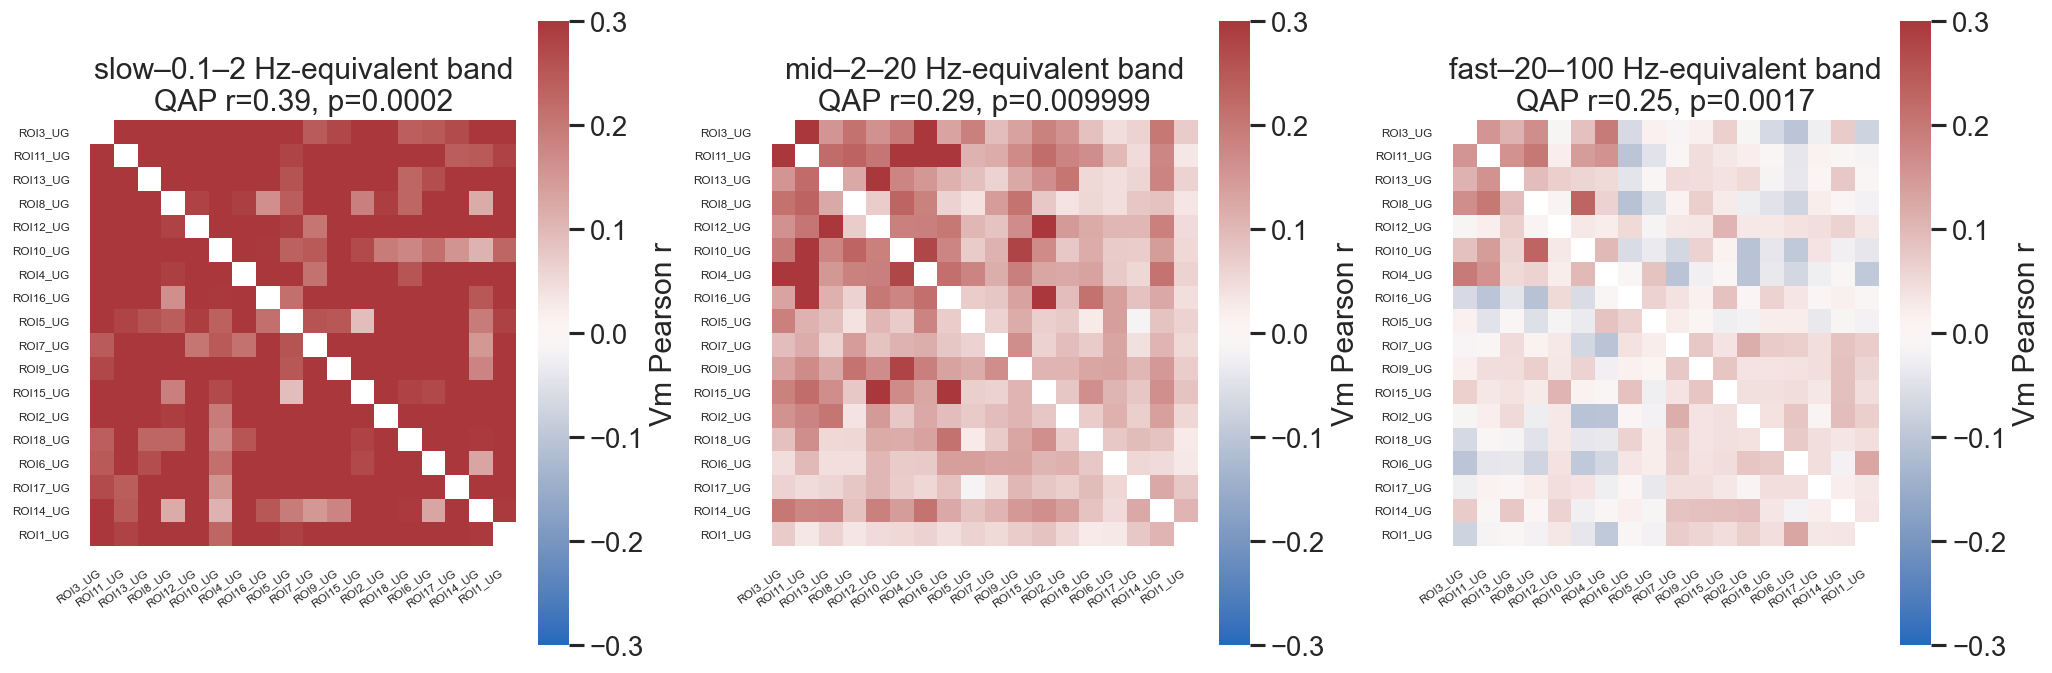

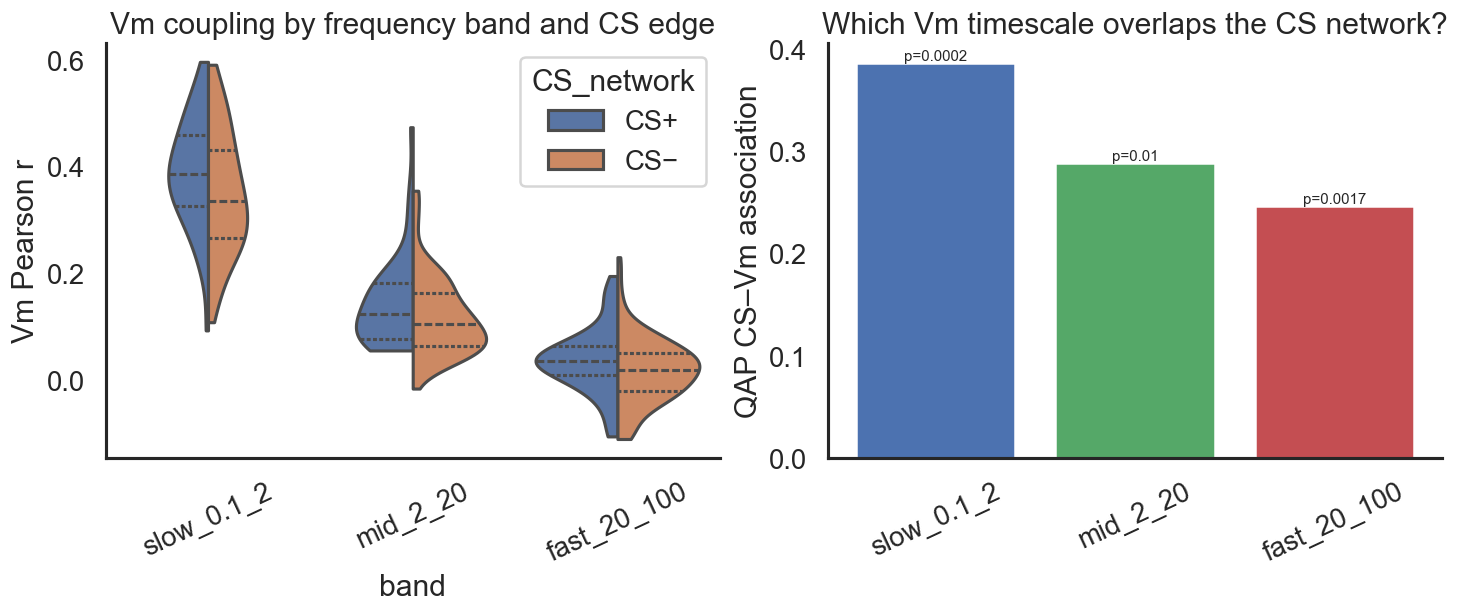

Band-specific weighted Vm node strength: showing 12 of 54 rows


,band,cell,strength,strength_z,candidate_hub_z_gt_1
10,slow_0.1_2,ROI11_UG,5.201013,1.493458,True
11,slow_0.1_2,ROI12_UG,5.137047,1.402086,True
12,slow_0.1_2,ROI13_UG,5.075565,1.314264,True
2,slow_0.1_2,ROI3_UG,4.679291,0.748214,False
1,slow_0.1_2,ROI2_UG,4.647974,0.703478,False
8,slow_0.1_2,ROI9_UG,4.585216,0.613833,False
3,slow_0.1_2,ROI4_UG,4.584305,0.612533,False
14,slow_0.1_2,ROI15_UG,4.496267,0.486775,False
15,slow_0.1_2,ROI16_UG,4.425453,0.385623,False
5,slow_0.1_2,ROI6_UG,4.048186,-0.153278,False


Vm clustering source=mid_2_20 correlation, method=average, selected k=2, silhouette=0.042 (weak)
Caution: Vm module separation is weak; treat colors as an exploratory partition, not evidence of discrete Vm populations.


,requested_clusters,actual_clusters,silhouette
0,2,2,0.042
1,3,3,0.035
2,4,4,0.032
3,5,5,0.028
4,6,6,0.021


,cell,Vm_candidate_module,Vm_module_id,Vm_strength,Vm_strength_z,candidate_Vm_hub
16,ROI17_UG,Vm1,1,0.560,-1.42,False
0,ROI1_UG,Vm1,1,0.316,-1.81,False
10,ROI11_UG,Vm2,2,2.531,1.74,True
3,ROI4_UG,Vm2,2,2.350,1.45,True
2,ROI3_UG,Vm2,2,2.129,1.09,True
9,ROI10_UG,Vm2,2,2.005,0.90,False
11,ROI12_UG,Vm2,2,1.947,0.80,False
15,ROI16_UG,Vm2,2,1.824,0.60,False
8,ROI9_UG,Vm2,2,1.783,0.54,False
14,ROI15_UG,Vm2,2,1.743,0.48,False


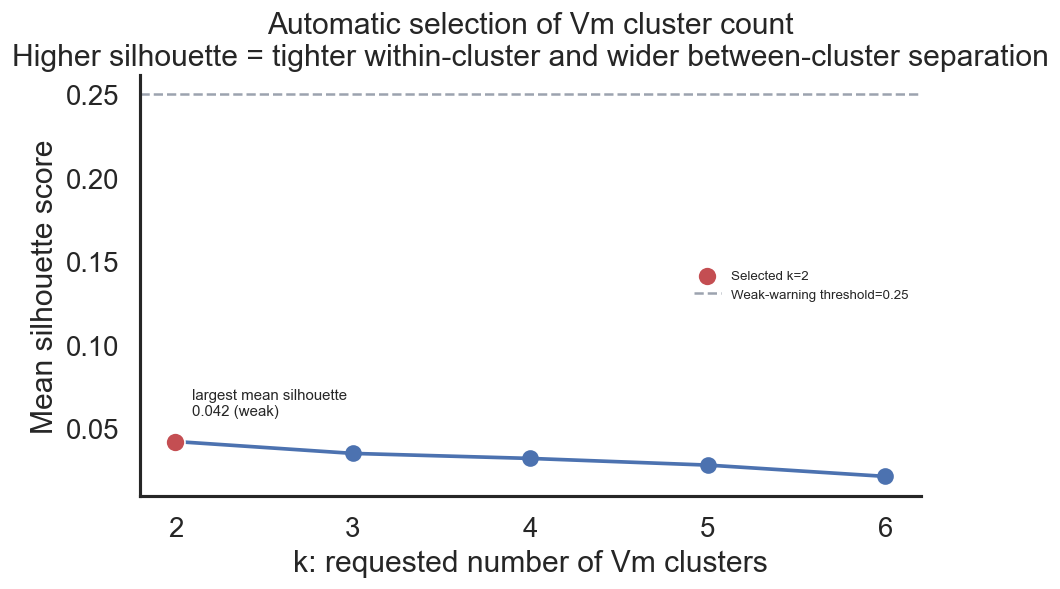

In [10]:
# ==============================
# Vm NETWORKS BY TIMESCALE
# ==============================
def _bandpass_matrix(data, fs, low_hz, high_hz, order):
    nyquist = 0.5 * float(fs)
    low = max(float(low_hz), 1e-6); high = min(float(high_hz), 0.95 * nyquist)
    if low >= high:
        raise ValueError(f'Invalid band {low_hz:g}-{high_hz:g} Hz for fs={fs:g} Hz')
    sos = butter(int(order), [low / nyquist, high / nyquist], btype='bandpass', output='sos')
    return sosfiltfilt(sos, np.asarray(data, float), axis=0)

vm_band_matrices = {}; vm_band_pair_rows = []; vm_band_qap_rows = []
band_rng = np.random.default_rng(int(VM_BAND_CONFIG['rng_seed']))
for band_name, (low_hz, high_hz) in VM_BAND_CONFIG['bands_hz'].items():
    filtered_sessions = [_bandpass_matrix(s['subthreshold'], s['fs'], low_hz, high_hz, VM_BAND_CONFIG['filter_order']) for s in processed_sessions]
    pooled = np.concatenate(filtered_sessions, axis=0)
    matrix = np.corrcoef(pooled, rowvar=False)
    np.fill_diagonal(matrix, np.nan)
    vm_band_matrices[band_name] = matrix
    for i, j in combinations(range(n_cells), 2):
        vm_band_pair_rows.append({'band': band_name, 'low_hz': low_hz, 'high_hz': high_hz, 'cell_i': cell_names[i], 'cell_j': cell_names[j], 'i': i, 'j': j, 'vm_r': matrix[i, j], 'cs_sttc': cs_primary_mat[i, j], 'cs_edge': bool(cs_edge_mat[i, j])})
    qap_table, _ = qap_test(cs_primary_mat, matrix, VM_BAND_CONFIG['n_qap_permutations'], band_rng)
    qap_table.insert(0, 'band', band_name); qap_table.insert(1, 'low_hz', low_hz); qap_table.insert(2, 'high_hz', high_hz)
    vm_band_qap_rows.append(qap_table)

vm_band_pair_df = pd.DataFrame(vm_band_pair_rows)
vm_band_qap_summary = pd.concat(vm_band_qap_rows, ignore_index=True)
display(vm_band_qap_summary)

fig, axes = plt.subplots(1, len(vm_band_matrices), figsize=(17, 5.5), constrained_layout=True)
for ax, (band_name, matrix) in zip(np.atleast_1d(axes), vm_band_matrices.items()):
    shown = matrix[np.ix_(cs_order, cs_order)]
    sns.heatmap(shown, ax=ax, cmap='vlag', center=0, vmin=CORR_HEATMAP_SCALE['vmin'], vmax=CORR_HEATMAP_SCALE['vmax'], square=True, xticklabels=ordered_labels, yticklabels=ordered_labels, cbar_kws={'label': 'Vm Pearson r'})
    result = vm_band_qap_summary[(vm_band_qap_summary['band'] == band_name) & (vm_band_qap_summary['metric'] == 'pearson')].iloc[0]
    ax.set_title(f"{band_name.replace('_', '–')} Hz-equivalent band\nQAP r={result['association']:.2f}, p={result['qap_p_greater']:.4g}")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=7); ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
plt.show(); plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
sns.violinplot(data=vm_band_pair_df.assign(CS_network=np.where(vm_band_pair_df['cs_edge'], 'CS+', 'CS−')), x='band', y='vm_r', hue='CS_network', hue_order=['CS+', 'CS−'], split=True, inner='quart', cut=0, ax=axes[0])
axes[0].set_title('Vm coupling by frequency band and CS edge'); axes[0].tick_params(axis='x', rotation=25); axes[0].set_ylabel('Vm Pearson r')
pearson_bands = vm_band_qap_summary[vm_band_qap_summary['metric'] == 'pearson']
axes[1].bar(pearson_bands['band'], pearson_bands['association'], color=['#4C72B0', '#55A868', '#C44E52'])
for x, row in enumerate(pearson_bands.itertuples(index=False)):
    axes[1].text(x, row.association, f'p={row.qap_p_greater:.3g}', ha='center', va='bottom' if row.association >= 0 else 'top', fontsize=9)
axes[1].axhline(0, color='#9CA3AF', lw=1); axes[1].set_ylabel('QAP CS–Vm association'); axes[1].tick_params(axis='x', rotation=25); axes[1].set_title('Which Vm timescale overlaps the CS network?')
plt.show(); plt.close(fig)

# Shuffle-normalized Vm weights for each timescale. These are used for hub maps.
vm_band_null95_matrices = {}; vm_band_weight_matrices = {}; vm_band_strength_rows = []
band_null_rng = np.random.default_rng(int(VM_BAND_CONFIG['rng_seed']) + 41)
for band_name, (low_hz, high_hz) in VM_BAND_CONFIG['bands_hz'].items():
    filtered_sessions = [_bandpass_matrix(s['subthreshold'], s['fs'], low_hz, high_hz, VM_BAND_CONFIG['filter_order']) for s in processed_sessions]
    null95_matrix = np.full((n_cells, n_cells), np.nan)
    for i, j in combinations(range(n_cells), 2):
        chunks = [(data[:, i], data[:, j]) for data in filtered_sessions]
        min_shift_samples = max(1, int(round(SUBTH_CORR_CONFIG['min_shift_ms'] * np.median([s['fs'] for s in processed_sessions]) / 1000.0)))
        _, _, _, null95 = _corr_with_session_shifts(chunks, VM_BAND_CONFIG['n_null_shuffles'], band_null_rng, min_shift_samples, SUBTH_CORR_CONFIG['min_samples'], SUBTH_CORR_CONFIG['pooling_mode'])
        null95_matrix[i, j] = null95_matrix[j, i] = null95
    weight = np.maximum(0.0, vm_band_matrices[band_name] - null95_matrix)
    weight[~np.isfinite(weight)] = 0.0; np.fill_diagonal(weight, 0.0)
    vm_band_null95_matrices[band_name] = null95_matrix; vm_band_weight_matrices[band_name] = weight
    strength = np.sum(weight, axis=1); z_strength = (strength - np.mean(strength)) / (np.std(strength) + 1e-12)
    for i, cell in enumerate(cell_names): vm_band_strength_rows.append({'band': band_name, 'cell': cell, 'strength': strength[i], 'strength_z': z_strength[i], 'candidate_hub_z_gt_1': bool(z_strength[i] > 1.0)})
vm_band_strength_df = pd.DataFrame(vm_band_strength_rows)
display_top(vm_band_strength_df, label='Band-specific weighted Vm node strength', sort_by='strength')

# Candidate Vm modules from continuous shuffle-excess coupling. This is separate from hub strength.
def _silhouette_precomputed(distance, labels):
    distance = np.asarray(distance, float); labels = np.asarray(labels)
    unique = np.unique(labels); scores = np.zeros(len(labels), dtype=float)
    if len(unique) < 2: return np.nan
    for i in range(len(labels)):
        same = labels == labels[i]; same[i] = False
        if not np.any(same): scores[i] = 0.0; continue
        a = float(np.mean(distance[i, same]))
        b = min(float(np.mean(distance[i, labels == other])) for other in unique if other != labels[i])
        scale = max(a, b); scores[i] = (b - a) / scale if scale > 0 else 0.0
    return float(np.mean(scores))

def _canonical_cluster_labels(labels):
    labels = np.asarray(labels, dtype=int)
    ordered = sorted(np.unique(labels), key=lambda group: int(np.flatnonzero(labels == group)[0]))
    remap = {group: idx + 1 for idx, group in enumerate(ordered)}
    return np.asarray([remap[group] for group in labels], dtype=int)

vm_cluster_source = str(VM_CLUSTER_CONFIG['source']).strip().lower()
vm_cluster_band = str(VM_CLUSTER_CONFIG['source_band'])
if vm_cluster_source == 'full_band_correlation':
    vm_cluster_corr_mat = np.asarray(vm_corr_mat, float).copy(); vm_cluster_null95_mat = np.asarray(vm_null95_mat, float).copy()
    vm_cluster_source_label = f'full preprocessed Vm (≤{PREPROCESS_CONFIG["lowpass_cutoff_hz"]:g} Hz)'
elif vm_cluster_source in {'band_correlation', 'band_shuffle_excess'}:
    if vm_cluster_band not in vm_band_matrices: raise KeyError(f'Unknown Vm clustering band: {vm_cluster_band!r}')
    vm_cluster_corr_mat = np.asarray(vm_band_matrices[vm_cluster_band], float).copy(); vm_cluster_null95_mat = np.asarray(vm_band_null95_matrices[vm_cluster_band], float).copy()
    vm_cluster_source_label = f'{vm_cluster_band} correlation' if vm_cluster_source == 'band_correlation' else f'{vm_cluster_band} shuffle excess'
else:
    raise ValueError(f'Unknown VM_CLUSTER_CONFIG source: {vm_cluster_source!r}')
vm_cluster_weight_mat = np.maximum(0.0, vm_cluster_corr_mat - vm_cluster_null95_mat)
vm_cluster_weight_mat[~np.isfinite(vm_cluster_weight_mat)] = 0.0; np.fill_diagonal(vm_cluster_weight_mat, 0.0)
vm_cluster_max = float(np.max(vm_cluster_weight_mat)) if vm_cluster_weight_mat.size else 0.0
if vm_cluster_source == 'band_shuffle_excess':
    vm_cluster_edge_display_mat = vm_cluster_weight_mat.copy(); vm_cluster_edge_label = 'Vm excess edge; width = r − null95'
else:
    vm_cluster_edge_display_mat = np.maximum(0.0, vm_cluster_corr_mat); vm_cluster_edge_display_mat[~np.isfinite(vm_cluster_edge_display_mat)] = 0.0; np.fill_diagonal(vm_cluster_edge_display_mat, 0.0)
    vm_cluster_edge_label = 'Vm correlation edge; width = Pearson r'
vm_cluster_edge_max = float(np.max(vm_cluster_edge_display_mat)) if vm_cluster_edge_display_mat.size else 0.0
vm_cluster_score_rows = []
if bool(VM_CLUSTER_CONFIG['enabled']) and n_cells >= 3 and np.any(np.isfinite(vm_cluster_corr_mat[upper])):
    if vm_cluster_source == 'band_shuffle_excess':
        vm_cluster_similarity = np.clip(vm_cluster_weight_mat / (vm_cluster_max + 1e-12), 0.0, 1.0); np.fill_diagonal(vm_cluster_similarity, 1.0)
        vm_cluster_distance = 1.0 - vm_cluster_similarity
    else:
        vm_cluster_similarity = np.clip(np.nan_to_num(vm_cluster_corr_mat, nan=0.0), -1.0, 1.0); np.fill_diagonal(vm_cluster_similarity, 1.0)
        vm_cluster_distance = np.sqrt(np.maximum(0.0, 2.0 * (1.0 - vm_cluster_similarity)))
    np.fill_diagonal(vm_cluster_distance, 0.0)
    vm_cluster_condensed = squareform(vm_cluster_distance, checks=False)
    vm_cluster_tree = linkage(vm_cluster_condensed, method=str(VM_CLUSTER_CONFIG['method']))
    vm_cluster_tree = optimal_leaf_ordering(vm_cluster_tree, vm_cluster_condensed)
    vm_cluster_order = leaves_list(vm_cluster_tree).astype(int)
    configured_k = VM_CLUSTER_CONFIG['n_clusters']
    candidate_ks = [int(configured_k)] if str(configured_k).lower() != 'auto' else list(range(max(2, int(VM_CLUSTER_CONFIG['min_clusters'])), min(int(VM_CLUSTER_CONFIG['max_clusters']), n_cells - 1) + 1))
    best = None
    for requested_k in candidate_ks:
        labels = fcluster(vm_cluster_tree, t=int(requested_k), criterion='maxclust')
        actual_k = len(np.unique(labels)); score = _silhouette_precomputed(vm_cluster_distance, labels) if actual_k >= 2 else np.nan
        vm_cluster_score_rows.append({'requested_clusters': int(requested_k), 'actual_clusters': int(actual_k), 'silhouette': score})
        if np.isfinite(score) and (best is None or score > best[0]): best = (score, labels)
    if best is None: vm_cluster_labels = np.ones(n_cells, dtype=int); vm_cluster_silhouette = np.nan
    else: vm_cluster_silhouette, vm_cluster_labels = float(best[0]), _canonical_cluster_labels(best[1])
else:
    vm_cluster_distance = np.full((n_cells, n_cells), np.nan); vm_cluster_order = np.arange(n_cells); vm_cluster_labels = np.ones(n_cells, dtype=int); vm_cluster_silhouette = np.nan
vm_cluster_names = np.asarray([f'Vm{group}' for group in vm_cluster_labels], dtype=object)
vm_cluster_score_df = pd.DataFrame(vm_cluster_score_rows)
vm_cluster_strength = np.sum(vm_cluster_weight_mat, axis=1); vm_cluster_strength_z = (vm_cluster_strength - np.mean(vm_cluster_strength)) / (np.std(vm_cluster_strength) + 1e-12)
vm_cluster_strength_rows = pd.DataFrame({'cell': cell_names, 'strength': vm_cluster_strength, 'strength_z': vm_cluster_strength_z, 'candidate_hub_z_gt_1': vm_cluster_strength_z > 1.0}).set_index('cell').loc[cell_names]
vm_cluster_membership = pd.DataFrame({'cell': cell_names, 'Vm_candidate_module': vm_cluster_names, 'Vm_module_id': vm_cluster_labels, 'Vm_strength': vm_cluster_strength_rows['strength'].to_numpy(), 'Vm_strength_z': vm_cluster_strength_rows['strength_z'].to_numpy(), 'candidate_Vm_hub': vm_cluster_strength_rows['candidate_hub_z_gt_1'].to_numpy()})
cluster_membership['Vm_candidate_module'] = vm_cluster_names
vm_cluster_quality = 'weak' if np.isfinite(vm_cluster_silhouette) and vm_cluster_silhouette < float(VM_CLUSTER_CONFIG['weak_silhouette_threshold']) else 'supported'
print(f'Vm clustering source={vm_cluster_source_label}, method={VM_CLUSTER_CONFIG["method"]}, selected k={len(np.unique(vm_cluster_labels))}, silhouette={vm_cluster_silhouette:.3f} ({vm_cluster_quality})')
if vm_cluster_quality == 'weak': print('Caution: Vm module separation is weak; treat colors as an exploratory partition, not evidence of discrete Vm populations.')
if len(vm_cluster_score_df): display(vm_cluster_score_df.round({'silhouette': 3}))
display(vm_cluster_membership.sort_values(['Vm_module_id', 'Vm_strength'], ascending=[True, False]).round({'Vm_strength': 3, 'Vm_strength_z': 2}))
# Silhouette diagnostic: k is the requested number of Vm clusters.
if len(vm_cluster_score_df):
    selected_k = int(len(np.unique(vm_cluster_labels)))
    selected_score = float(vm_cluster_silhouette)
    fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)
    ax.plot(vm_cluster_score_df['requested_clusters'], vm_cluster_score_df['silhouette'], marker='o', lw=2.2, color='#4C72B0')
    ax.scatter([selected_k], [selected_score], s=130, color='#C44E52', edgecolor='white', linewidth=1.0, zorder=3, label=f'Selected k={selected_k}')
    ax.axhline(float(VM_CLUSTER_CONFIG['weak_silhouette_threshold']), color='#9CA3AF', ls='--', lw=1.5, label=f'Weak-warning threshold={VM_CLUSTER_CONFIG["weak_silhouette_threshold"]:g}')
    ax.annotate(f'largest mean silhouette\n{selected_score:.3f} ({vm_cluster_quality})', (selected_k, selected_score), xytext=(10, 16), textcoords='offset points', fontsize=9, ha='left')
    ax.set_xticks(vm_cluster_score_df['requested_clusters'].astype(int)); ax.set_xlabel('k: requested number of Vm clusters'); ax.set_ylabel('Mean silhouette score')
    ax.set_title('Automatic selection of Vm cluster count\nHigher silhouette = tighter within-cluster and wider between-cluster separation')
    ax.legend(frameon=False, fontsize=8); sns.despine(ax=ax); plt.show(); plt.close(fig)


Consensus validation: 12 Vm blocks; selected Vm k=2; silhouette=0.691; PAC=0.575 (weak/ambiguous).
CS consensus: threshold=0.60; min valid blocks=3; within-between gap=nan (weak/unsupported).


,coassignment_threshold,n_groups,n_assigned_cells,mean_within,mean_between,within_minus_between
0,0.5,0,0,NaN,NaN,NaN
1,0.6,0,0,NaN,NaN,NaN
2,0.7,0,0,NaN,NaN,NaN
3,0.8,0,0,NaN,NaN,NaN


,k,pooled_silhouette,consensus_silhouette,mean_within,mean_between,within_minus_between,PAC_0.1_0.9,selection_score,n_temporal_blocks
0,2,0.042,0.691,0.850,0.431,0.419,0.575,0.404,12
1,3,0.035,0.432,0.692,0.303,0.389,0.863,0.001,12
2,4,0.032,0.370,0.630,0.216,0.414,0.837,-0.049,12
3,5,0.028,0.382,0.663,0.185,0.478,0.739,0.013,12
4,6,0.021,0.255,0.478,0.109,0.368,0.654,-0.072,12


,cell,CS_consensus_group,Vm_consensus_module
0,ROI1_UG,unassigned,Vm1
9,ROI10_UG,unassigned,Vm2
10,ROI11_UG,unassigned,Vm2
11,ROI12_UG,unassigned,Vm2
12,ROI13_UG,unassigned,Vm2
13,ROI14_UG,unassigned,Vm2
14,ROI15_UG,unassigned,Vm2
15,ROI16_UG,unassigned,Vm2
16,ROI17_UG,unassigned,Vm2
17,ROI18_UG,unassigned,Vm2


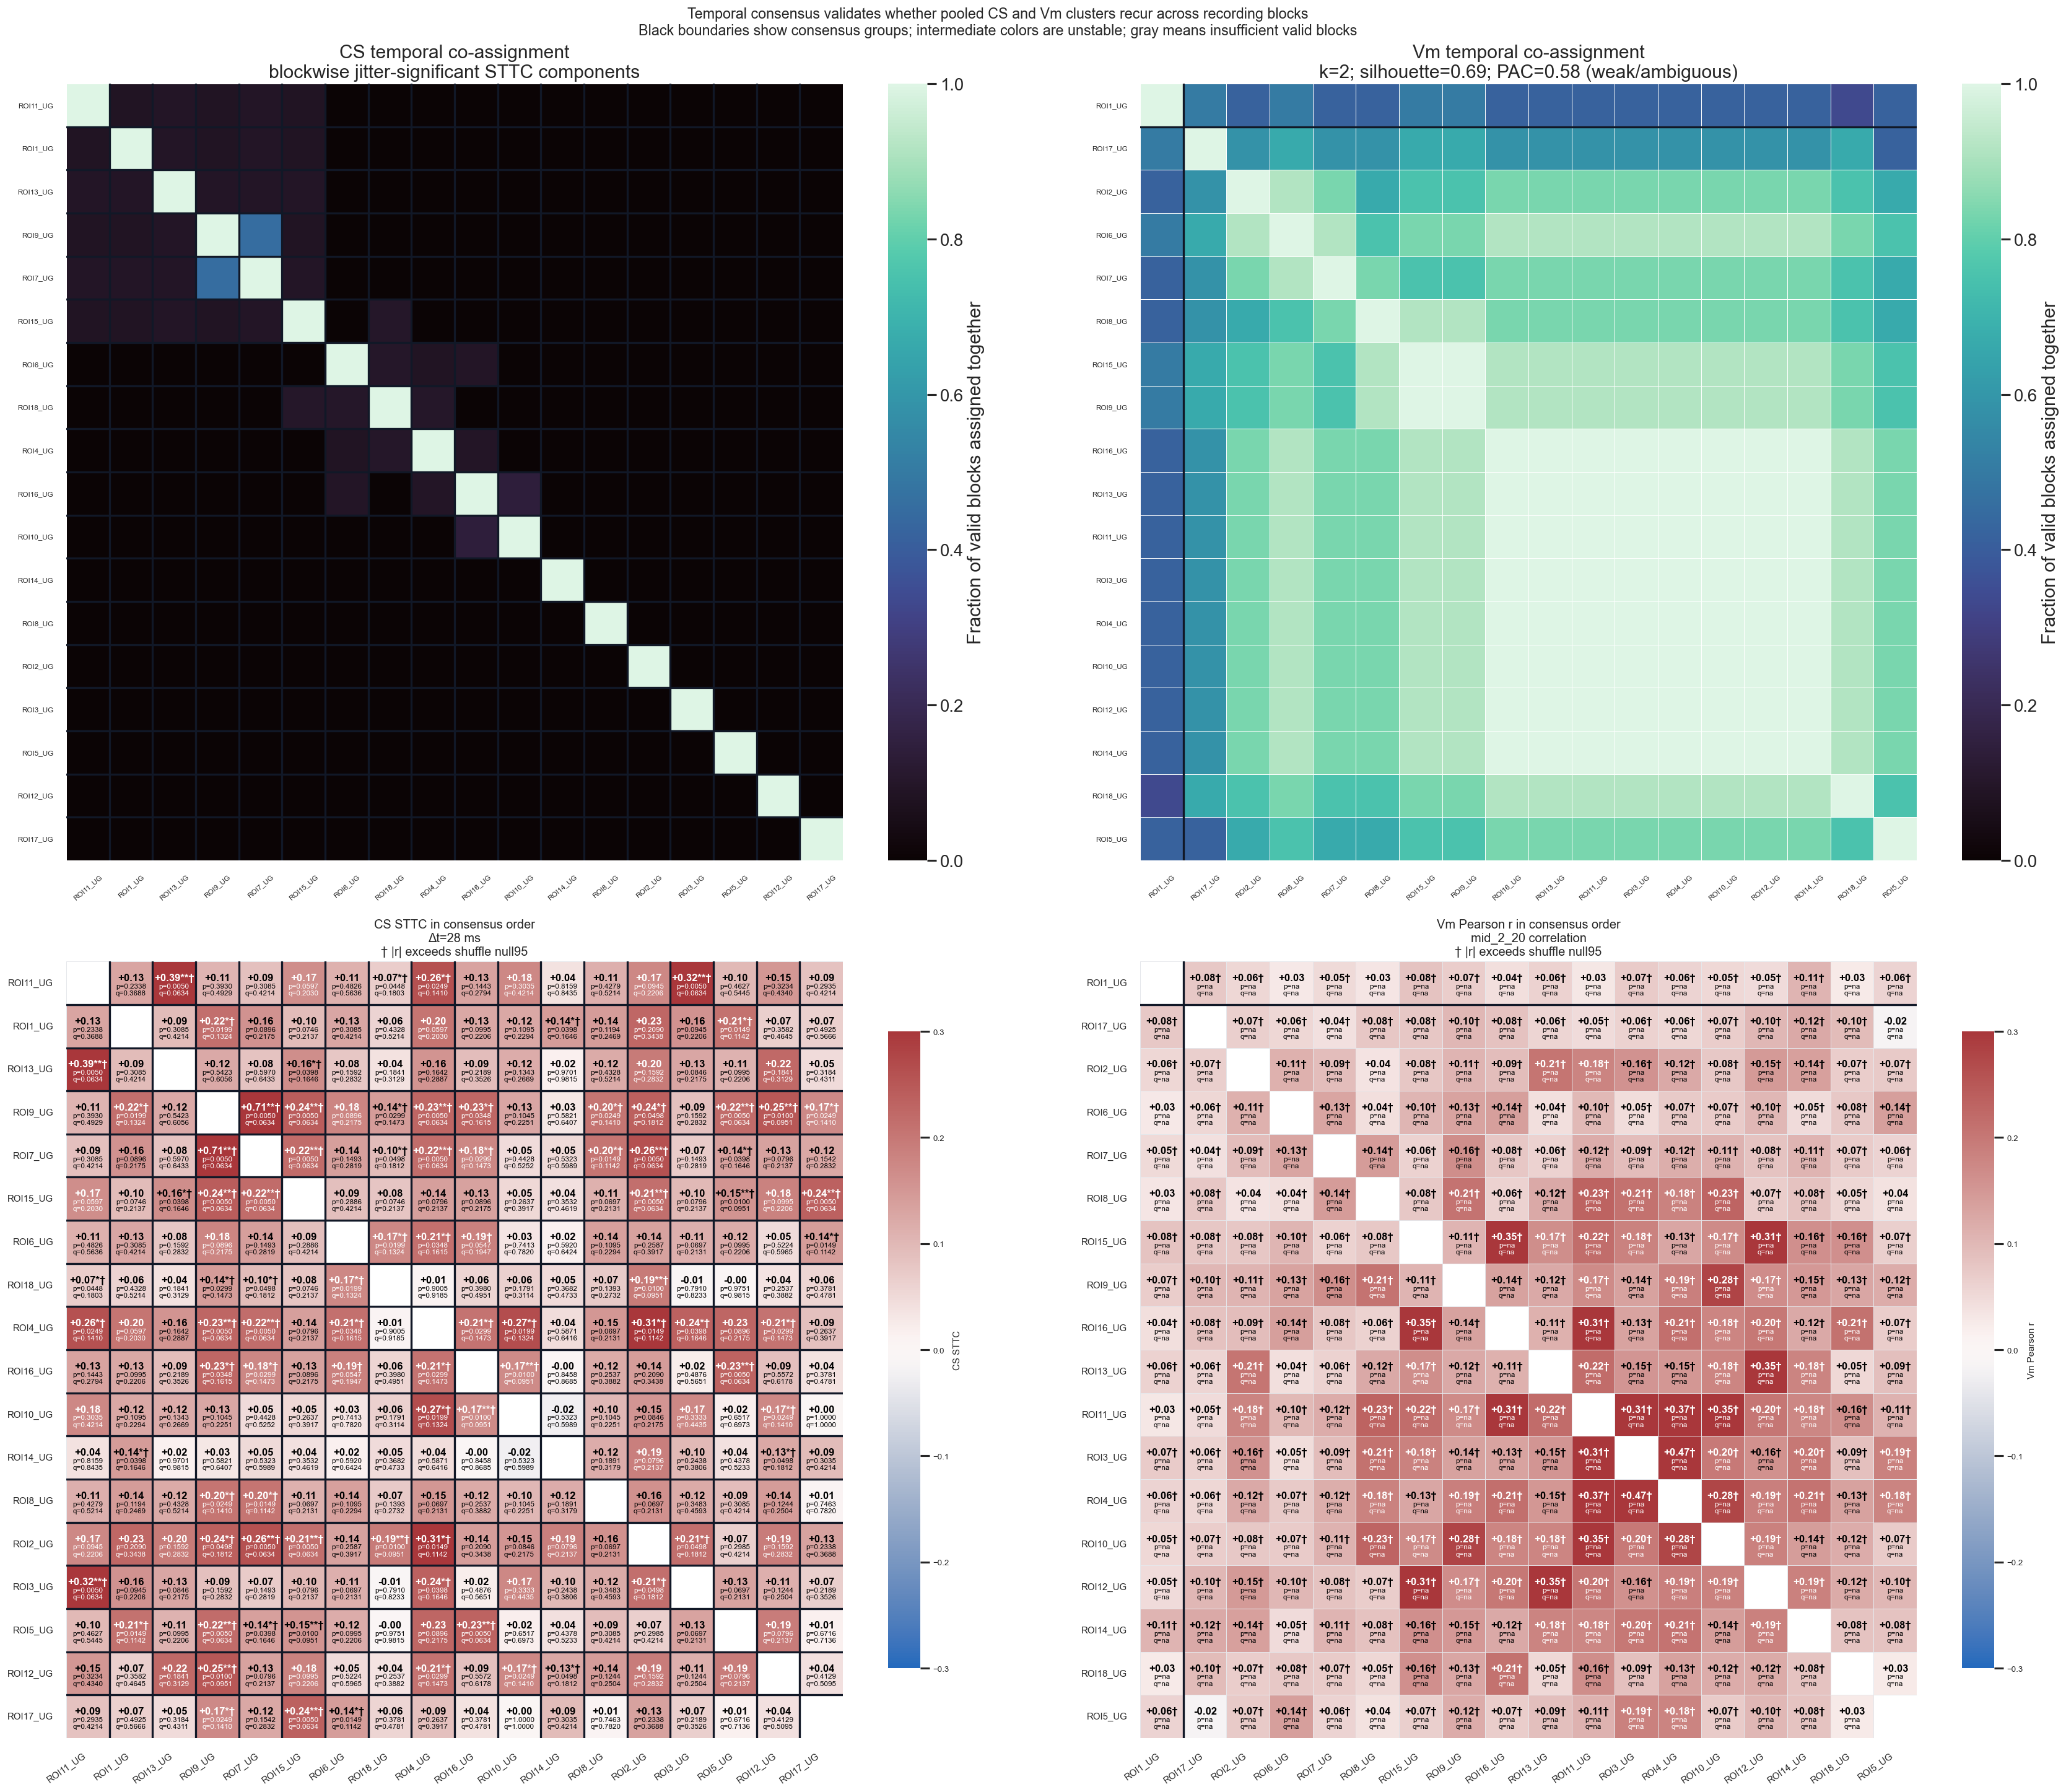

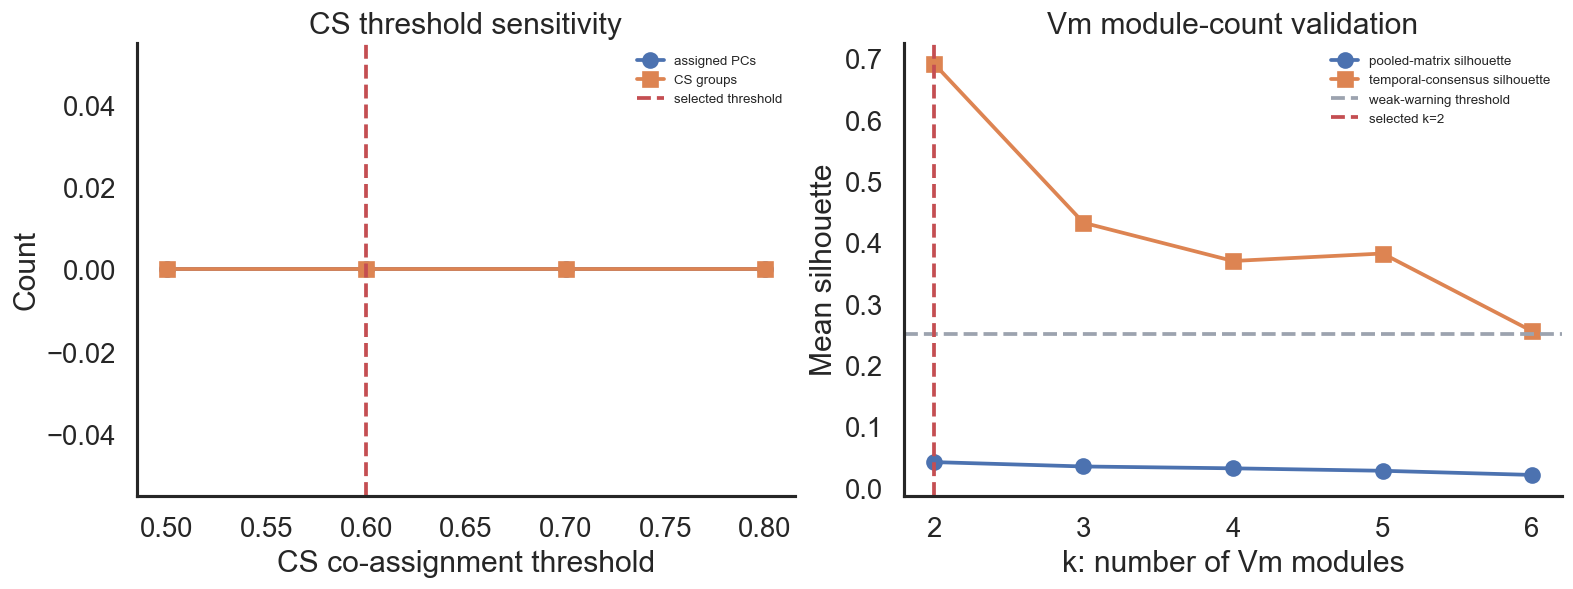

In [11]:
# ==============================
# TEMPORAL CONSENSUS / CO-ASSIGNMENT VALIDATION
# ==============================
def _consensus_order_and_labels(coassign, requested_k, method='average'):
    similarity = np.nan_to_num(np.asarray(coassign, float), nan=0.0)
    similarity = np.clip(0.5 * (similarity + similarity.T), 0.0, 1.0)
    np.fill_diagonal(similarity, 1.0)
    distance = 1.0 - similarity; np.fill_diagonal(distance, 0.0)
    condensed = squareform(distance, checks=False)
    tree = linkage(condensed, method=method)
    tree = optimal_leaf_ordering(tree, condensed)
    labels = _canonical_cluster_labels(fcluster(tree, t=int(requested_k), criterion='maxclust'))
    return distance, tree, labels, leaves_list(tree).astype(int)

def _cluster_boundaries(labels_in_order):
    return np.flatnonzero(np.diff(np.asarray(labels_in_order))) + 1

def _within_between_summary(coassign, labels):
    values = np.asarray(coassign, float); labels = np.asarray(labels)
    iu = np.triu_indices(len(labels), 1)
    valid = np.isfinite(values[iu]) & (labels[iu[0]] > 0) & (labels[iu[1]] > 0)
    same = labels[iu[0]] == labels[iu[1]]
    within = values[iu][valid & same]; between = values[iu][valid & ~same]
    within_mean = float(np.mean(within)) if within.size else np.nan
    between_mean = float(np.mean(between)) if between.size else np.nan
    return within_mean, between_mean, within_mean - between_mean if np.isfinite(within_mean) and np.isfinite(between_mean) else np.nan

# CS: reconstruct one graph per valid temporal block, then count same-component assignments.
cs_consensus_num = np.zeros((n_cells, n_cells), float)
cs_consensus_den = np.zeros((n_cells, n_cells), float)
cs_block_membership_rows = []
stability_blocks_df = pd.DataFrame(stability_block_rows)
if len(stability_blocks_df):
    for (session_name, block_idx), block_df in stability_blocks_df.groupby(['session', 'block'], sort=True):
        active = np.unique(np.r_[block_df['i'].to_numpy(int), block_df['j'].to_numpy(int)])
        block_edges = np.zeros((len(active), len(active)), dtype=bool)
        active_lookup = {int(cell): pos for pos, cell in enumerate(active)}
        for row in block_df.itertuples(index=False):
            if bool(row.edge):
                a, b = active_lookup[int(row.i)], active_lookup[int(row.j)]
                block_edges[a, b] = block_edges[b, a] = True
        _, block_labels = connected_components(csr_matrix(block_edges.astype(int)), directed=False, return_labels=True)
        for local_idx, global_idx in enumerate(active):
            cs_block_membership_rows.append({'session': session_name, 'block': int(block_idx), 'cell': cell_names[int(global_idx)], 'component': int(block_labels[local_idx]) + 1})
        for a, b in combinations(range(len(active)), 2):
            i, j = int(active[a]), int(active[b])
            cs_consensus_den[i, j] += 1; cs_consensus_den[j, i] += 1
            together = float(block_labels[a] == block_labels[b])
            cs_consensus_num[i, j] += together; cs_consensus_num[j, i] += together
cs_coassignment_mat = np.divide(cs_consensus_num, cs_consensus_den, out=np.full_like(cs_consensus_num, np.nan), where=cs_consensus_den > 0)
cs_coassignment_mat[cs_consensus_den < int(CONSENSUS_CONFIG['cs_min_valid_blocks'])] = np.nan
np.fill_diagonal(cs_coassignment_mat, 1.0)
cs_consensus_valid_mat = cs_consensus_den.copy(); np.fill_diagonal(cs_consensus_valid_mat, np.nan)

def _cs_consensus_cut(threshold):
    similarity = np.nan_to_num(cs_coassignment_mat, nan=0.0); np.fill_diagonal(similarity, 1.0)
    distance = 1.0 - similarity; np.fill_diagonal(distance, 0.0)
    condensed = squareform(distance, checks=False)
    tree = linkage(condensed, method=str(CLUSTER_CONFIG['method']))
    tree = optimal_leaf_ordering(tree, condensed)
    raw = _canonical_cluster_labels(fcluster(tree, t=1.0 - float(threshold), criterion='distance'))
    sizes = pd.Series(raw).value_counts().to_dict()
    retained = [group for group in sorted(sizes) if sizes[group] >= int(CONSENSUS_CONFIG['min_cluster_size'])]
    remap = {group: idx + 1 for idx, group in enumerate(retained)}
    labels = np.asarray([remap.get(group, 0) for group in raw], dtype=int)
    return labels, leaves_list(tree).astype(int), distance

cs_consensus_sensitivity_rows = []
for threshold in CONSENSUS_CONFIG['cs_threshold_sensitivity']:
    labels_t, _, _ = _cs_consensus_cut(float(threshold))
    assigned = labels_t > 0
    within, between, gap = _within_between_summary(cs_coassignment_mat, labels_t)
    cs_consensus_sensitivity_rows.append({
        'coassignment_threshold': float(threshold),
        'n_groups': int(len(np.unique(labels_t[assigned]))),
        'n_assigned_cells': int(np.sum(assigned)),
        'mean_within': within, 'mean_between': between, 'within_minus_between': gap,
    })
cs_consensus_sensitivity_df = pd.DataFrame(cs_consensus_sensitivity_rows)
cs_stable_microbands, cs_stable_order, cs_consensus_distance = _cs_consensus_cut(float(CONSENSUS_CONFIG['cs_coassignment_threshold']))
cs_stable_group_labels = np.asarray([f'CS{group}' if group > 0 else 'unassigned' for group in cs_stable_microbands], dtype=object)
cluster_membership['CS_stable_microband'] = cs_stable_microbands
cluster_membership['CS_stable_group'] = cs_stable_group_labels

# Vm: recluster each independent temporal block for every candidate k.
if vm_cluster_source in {'band_correlation', 'band_shuffle_excess'}:
    low_hz, high_hz = VM_BAND_CONFIG['bands_hz'][vm_cluster_band]
    vm_consensus_session_data = [_bandpass_matrix(s['subthreshold'], s['fs'], low_hz, high_hz, VM_BAND_CONFIG['filter_order']) for s in processed_sessions]
else:
    vm_consensus_session_data = [np.asarray(s['subthreshold'], float) for s in processed_sessions]

vm_temporal_blocks = []
for session, data in zip(processed_sessions, vm_consensus_session_data):
    boundaries = np.linspace(0, len(data), int(CONSENSUS_CONFIG['blocks_per_session']) + 1).astype(int)
    for block_idx, (start, stop) in enumerate(zip(boundaries[:-1], boundaries[1:]), start=1):
        if stop - start < int(CONSENSUS_CONFIG['vm_min_samples_per_block']):
            continue
        corr = np.corrcoef(data[start:stop], rowvar=False)
        corr = np.clip(np.nan_to_num(corr, nan=0.0), -1.0, 1.0); np.fill_diagonal(corr, 1.0)
        if vm_cluster_source == 'band_shuffle_excess':
            # The block null95 is expensive and unstable; use the full-recording null as a fixed reference.
            excess = np.maximum(0.0, corr - vm_cluster_null95_mat); excess[~np.isfinite(excess)] = 0.0
            block_similarity = excess / (float(np.max(excess)) + 1e-12); np.fill_diagonal(block_similarity, 1.0)
            block_distance = 1.0 - block_similarity
        else:
            block_distance = np.sqrt(np.maximum(0.0, 2.0 * (1.0 - corr)))
        np.fill_diagonal(block_distance, 0.0)
        vm_temporal_blocks.append({'session': session['session_name'], 'block': block_idx, 'distance': block_distance})

candidate_ks = list(range(max(2, int(VM_CLUSTER_CONFIG['min_clusters'])), min(int(VM_CLUSTER_CONFIG['max_clusters']), n_cells - 1) + 1))
if str(VM_CLUSTER_CONFIG['n_clusters']).lower() != 'auto':
    candidate_ks = [int(VM_CLUSTER_CONFIG['n_clusters'])]
pooled_scores = {int(row.requested_clusters): float(row.silhouette) for row in vm_cluster_score_df.itertuples(index=False)} if len(vm_cluster_score_df) else {}
vm_consensus_by_k = {}
vm_consensus_score_rows = []
for requested_k in candidate_ks:
    coassign_num = np.zeros((n_cells, n_cells), float)
    for block in vm_temporal_blocks:
        condensed = squareform(block['distance'], checks=False)
        block_tree = linkage(condensed, method=str(VM_CLUSTER_CONFIG['method']))
        block_labels = fcluster(block_tree, t=int(requested_k), criterion='maxclust')
        coassign_num += (block_labels[:, None] == block_labels[None, :]).astype(float)
    coassign = coassign_num / max(1, len(vm_temporal_blocks)); np.fill_diagonal(coassign, 1.0)
    consensus_distance, consensus_tree, consensus_labels, consensus_order = _consensus_order_and_labels(coassign, requested_k, method=str(VM_CLUSTER_CONFIG['method']))
    consensus_silhouette = _silhouette_precomputed(consensus_distance, consensus_labels)
    within, between, gap = _within_between_summary(coassign, consensus_labels)
    upper_values = coassign[np.triu_indices(n_cells, 1)]
    pac = float(np.mean((upper_values > float(CONSENSUS_CONFIG['ambiguous_low'])) & (upper_values < float(CONSENSUS_CONFIG['ambiguous_high']))))
    vm_consensus_by_k[int(requested_k)] = (coassign, consensus_distance, consensus_labels, consensus_order)
    selection_score = consensus_silhouette - 0.5 * pac if np.isfinite(consensus_silhouette) else -np.inf
    vm_consensus_score_rows.append({
        'k': int(requested_k), 'pooled_silhouette': pooled_scores.get(int(requested_k), np.nan),
        'consensus_silhouette': consensus_silhouette, 'mean_within': within,
        'mean_between': between, 'within_minus_between': gap, 'PAC_0.1_0.9': pac,
        'selection_score': selection_score, 'n_temporal_blocks': int(len(vm_temporal_blocks)),
    })
vm_consensus_score_df = pd.DataFrame(vm_consensus_score_rows)
if len(vm_consensus_score_df):
    selected_row = vm_consensus_score_df.sort_values(['selection_score', 'consensus_silhouette'], ascending=False).iloc[0]
    vm_consensus_k = int(selected_row['k'])
    vm_coassignment_mat, vm_consensus_distance, vm_cluster_labels, vm_cluster_order = vm_consensus_by_k[vm_consensus_k]
    vm_cluster_silhouette = float(selected_row['consensus_silhouette'])
else:
    vm_consensus_k = 1; vm_coassignment_mat = np.eye(n_cells); vm_cluster_labels = np.ones(n_cells, int); vm_cluster_order = np.arange(n_cells); vm_cluster_silhouette = np.nan
vm_cluster_names = np.asarray([f'Vm{group}' for group in vm_cluster_labels], dtype=object)
vm_selected_pac = float(selected_row['PAC_0.1_0.9']) if len(vm_consensus_score_df) else np.nan
vm_cluster_quality = ('weak/ambiguous' if (not np.isfinite(vm_cluster_silhouette) or vm_cluster_silhouette < float(VM_CLUSTER_CONFIG['weak_silhouette_threshold']) or not np.isfinite(vm_selected_pac) or vm_selected_pac > float(CONSENSUS_CONFIG['max_pac_for_supported'])) else 'supported')
vm_cluster_membership = pd.DataFrame({
    'cell': cell_names, 'Vm_candidate_module': vm_cluster_names, 'Vm_module_id': vm_cluster_labels,
    'Vm_strength': vm_cluster_strength_rows['strength'].to_numpy(),
    'Vm_strength_z': vm_cluster_strength_rows['strength_z'].to_numpy(),
    'candidate_Vm_hub': vm_cluster_strength_rows['candidate_hub_z_gt_1'].to_numpy(),
})
cluster_membership['Vm_candidate_module'] = vm_cluster_names
cluster_membership['Vm_consensus_module'] = vm_cluster_names

selected_cs_row = cs_consensus_sensitivity_df.loc[np.isclose(cs_consensus_sensitivity_df['coassignment_threshold'], float(CONSENSUS_CONFIG['cs_coassignment_threshold']))].iloc[0]
cs_consensus_gap = float(selected_cs_row['within_minus_between'])
cs_consensus_quality = ('weak/unsupported' if int(selected_cs_row['n_groups']) == 0 or not np.isfinite(cs_consensus_gap) or cs_consensus_gap < float(CONSENSUS_CONFIG['min_cs_within_between_gap']) else 'supported')
print(f'Consensus validation: {len(vm_temporal_blocks)} Vm blocks; selected Vm k={vm_consensus_k}; silhouette={vm_cluster_silhouette:.3f}; PAC={vm_selected_pac:.3f} ({vm_cluster_quality}).')
print(f'CS consensus: threshold={CONSENSUS_CONFIG["cs_coassignment_threshold"]:.2f}; min valid blocks={CONSENSUS_CONFIG["cs_min_valid_blocks"]}; within-between gap={cs_consensus_gap:.3f} ({cs_consensus_quality}).')
display(cs_consensus_sensitivity_df.round(3))
display(vm_consensus_score_df.round(3))
display(pd.DataFrame({'cell': cell_names, 'CS_consensus_group': cs_stable_group_labels, 'Vm_consensus_module': vm_cluster_names}).sort_values(['CS_consensus_group', 'Vm_consensus_module', 'cell']))

# Co-assignment matrices and their corresponding raw correlation matrices use the same validated orders.
cs_rank = np.empty(n_cells, dtype=int); cs_rank[cs_stable_order] = np.arange(n_cells)
cs_matrix_order = np.asarray(sorted(range(n_cells), key=lambda idx: (0, int(cs_stable_microbands[idx]), int(cs_rank[idx])) if cs_stable_microbands[idx] > 0 else (1, int(cs_rank[idx]), 0)), dtype=int)
vm_rank = np.empty(n_cells, dtype=int); vm_rank[vm_cluster_order] = np.arange(n_cells)
vm_matrix_order = np.asarray(sorted(range(n_cells), key=lambda idx: (int(vm_cluster_labels[idx]), int(vm_rank[idx]))), dtype=int)

cs_display_ids = np.asarray([int(cs_stable_microbands[idx]) if cs_stable_microbands[idx] > 0 else -(idx + 1) for idx in cs_matrix_order], int)
vm_display_ids = vm_cluster_labels[vm_matrix_order].astype(int)

fig, axes = plt.subplots(2, 2, figsize=(max(18, 1.15 * n_cells + 8), max(14, 1.0 * n_cells + 6)), constrained_layout=True)
coassignment_cmap = plt.get_cmap('mako').copy(); coassignment_cmap.set_bad('#D1D5DB')
for ax, matrix, order, ids, title in [
    (axes[0, 0], cs_coassignment_mat, cs_matrix_order, cs_display_ids, 'CS temporal co-assignment\nblockwise jitter-significant STTC components'),
    (axes[0, 1], vm_coassignment_mat, vm_matrix_order, vm_display_ids, f'Vm temporal co-assignment\nk={vm_consensus_k}; silhouette={vm_cluster_silhouette:.2f}; PAC={vm_selected_pac:.2f} ({vm_cluster_quality})'),
]:
    shown = matrix[np.ix_(order, order)]
    sns.heatmap(shown, ax=ax, cmap=coassignment_cmap, vmin=0, vmax=1, square=True,
                xticklabels=[cell_names[i] for i in order], yticklabels=[cell_names[i] for i in order],
                cbar_kws={'label': 'Fraction of valid blocks assigned together'}, linewidths=0.35, linecolor='white')
    for boundary in _cluster_boundaries(ids):
        ax.axhline(boundary, color='#111827', lw=2); ax.axvline(boundary, color='#111827', lw=2)
    ax.set_title(title); ax.tick_params(axis='x', rotation=40, labelsize=7); ax.tick_params(axis='y', labelsize=7)

plot_corr_matrix(cs_primary_mat, cs_primary_p_mat, cs_primary_q_mat,
                 f'CS STTC in consensus order\nΔt={primary_dt_ms:g} ms', order=cs_matrix_order,
                 cbar_label='CS STTC', ax=axes[1, 0], null95=cs_primary_null95_mat)
for boundary in _cluster_boundaries(cs_display_ids):
    axes[1, 0].axhline(boundary, color='#111827', lw=2); axes[1, 0].axvline(boundary, color='#111827', lw=2)
if vm_cluster_source == 'full_band_correlation': vm_cluster_p_show, vm_cluster_q_show = vm_p_mat, vm_q_mat
else: vm_cluster_p_show = np.full_like(vm_cluster_corr_mat, np.nan); vm_cluster_q_show = np.full_like(vm_cluster_corr_mat, np.nan)
plot_corr_matrix(vm_cluster_corr_mat, vm_cluster_p_show, vm_cluster_q_show,
                 f'Vm Pearson r in consensus order\n{vm_cluster_source_label}', order=vm_matrix_order,
                 cbar_label='Vm Pearson r', ax=axes[1, 1], null95=vm_cluster_null95_mat)
for boundary in _cluster_boundaries(vm_display_ids):
    axes[1, 1].axhline(boundary, color='#111827', lw=2); axes[1, 1].axvline(boundary, color='#111827', lw=2)
fig.suptitle('Temporal consensus validates whether pooled CS and Vm clusters recur across recording blocks\nBlack boundaries show consensus groups; intermediate colors are unstable; gray means insufficient valid blocks', fontsize=14)
plt.show(); plt.close(fig)

# Selection/sensitivity diagnostics keep tuning explicit rather than choosing labels by eye.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
axes[0].plot(cs_consensus_sensitivity_df['coassignment_threshold'], cs_consensus_sensitivity_df['n_assigned_cells'], marker='o', label='assigned PCs')
axes[0].plot(cs_consensus_sensitivity_df['coassignment_threshold'], cs_consensus_sensitivity_df['n_groups'], marker='s', label='CS groups')
axes[0].axvline(float(CONSENSUS_CONFIG['cs_coassignment_threshold']), color='#C44E52', ls='--', label='selected threshold')
axes[0].set_xlabel('CS co-assignment threshold'); axes[0].set_ylabel('Count'); axes[0].set_title('CS threshold sensitivity'); axes[0].legend(frameon=False, fontsize=8)
if len(vm_consensus_score_df):
    axes[1].plot(vm_consensus_score_df['k'], vm_consensus_score_df['pooled_silhouette'], marker='o', label='pooled-matrix silhouette')
    axes[1].plot(vm_consensus_score_df['k'], vm_consensus_score_df['consensus_silhouette'], marker='s', label='temporal-consensus silhouette')
    axes[1].axhline(float(VM_CLUSTER_CONFIG['weak_silhouette_threshold']), color='#9CA3AF', ls='--', label='weak-warning threshold')
    axes[1].axvline(vm_consensus_k, color='#C44E52', ls='--', label=f'selected k={vm_consensus_k}')
axes[1].set_xlabel('k: number of Vm modules'); axes[1].set_ylabel('Mean silhouette'); axes[1].set_title('Vm module-count validation'); axes[1].legend(frameon=False, fontsize=8)
for ax in axes: sns.despine(ax=ax)
plt.show(); plt.close(fig)


Loaded coordinates for 18 ROIs from: /Users/liangqiyuan/Desktop/Temp_data/20260813_B4_PCP2Cre_Microzones/Microzone3_MUnit_12_roi_coords.csv
ROI coordinate table: showing 12 of 18 rows


,ROI,Label,Type,Center_FOV_px_X,Center_FOV_px_Y,Center_um_X,Center_um_Y,Center_um_Z
0,ROI1,1,polygonXY,342,353,71.47,80.51,-29095.44
1,ROI2,1,polygonXY,267,314,11.58,49.44,-29095.44
2,ROI3,1,polygonXY,208,268,-34.75,12.71,-29095.44
3,ROI4,1,polygonXY,181,274,-56.21,17.23,-29095.44
4,ROI5,1,polygonXY,136,185,-91.81,-53.39,-29095.44
5,ROI6,1,polygonXY,155,149,-77.12,-81.64,-29095.44
6,ROI7,1,polygonXY,89,175,-129.66,-60.73,-29102.22
7,ROI8,1,polygonXY,96,214,-123.45,-30.23,-29102.22
8,ROI9,1,polygonXY,104,262,-117.80,7.63,-29102.22
9,ROI10,1,polygonXY,123,290,-102.54,30.23,-29102.22


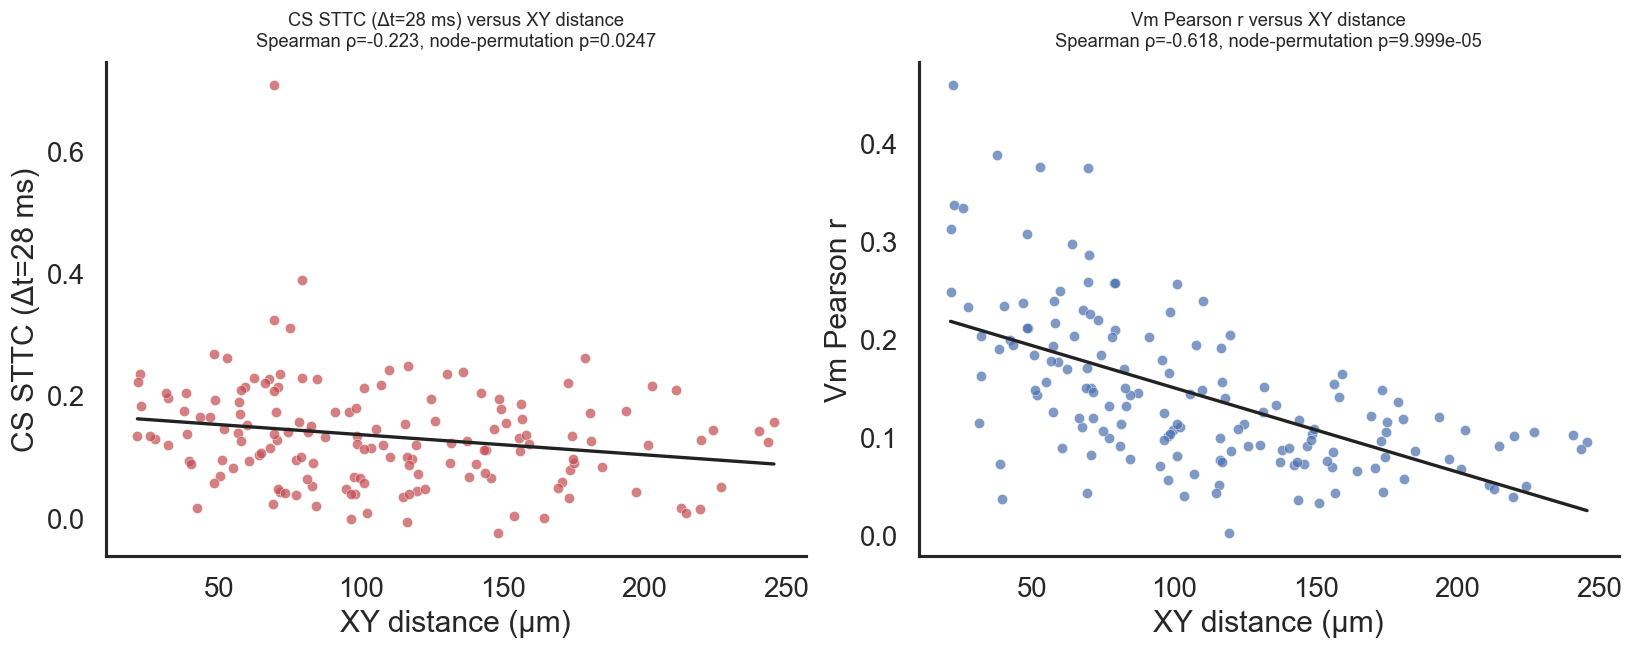

,measure,spearman_rho,node_permutation_p_two_sided,n_pairs
0,CS STTC (Δt=28 ms),-0.222957,0.024698,153
1,Vm Pearson r,-0.617835,0.000100,153


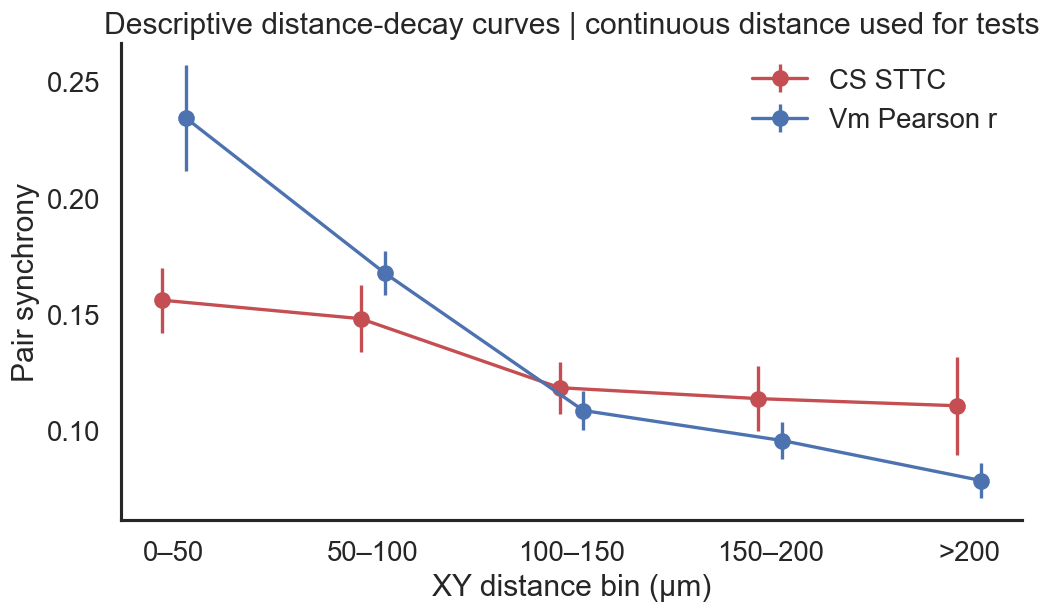

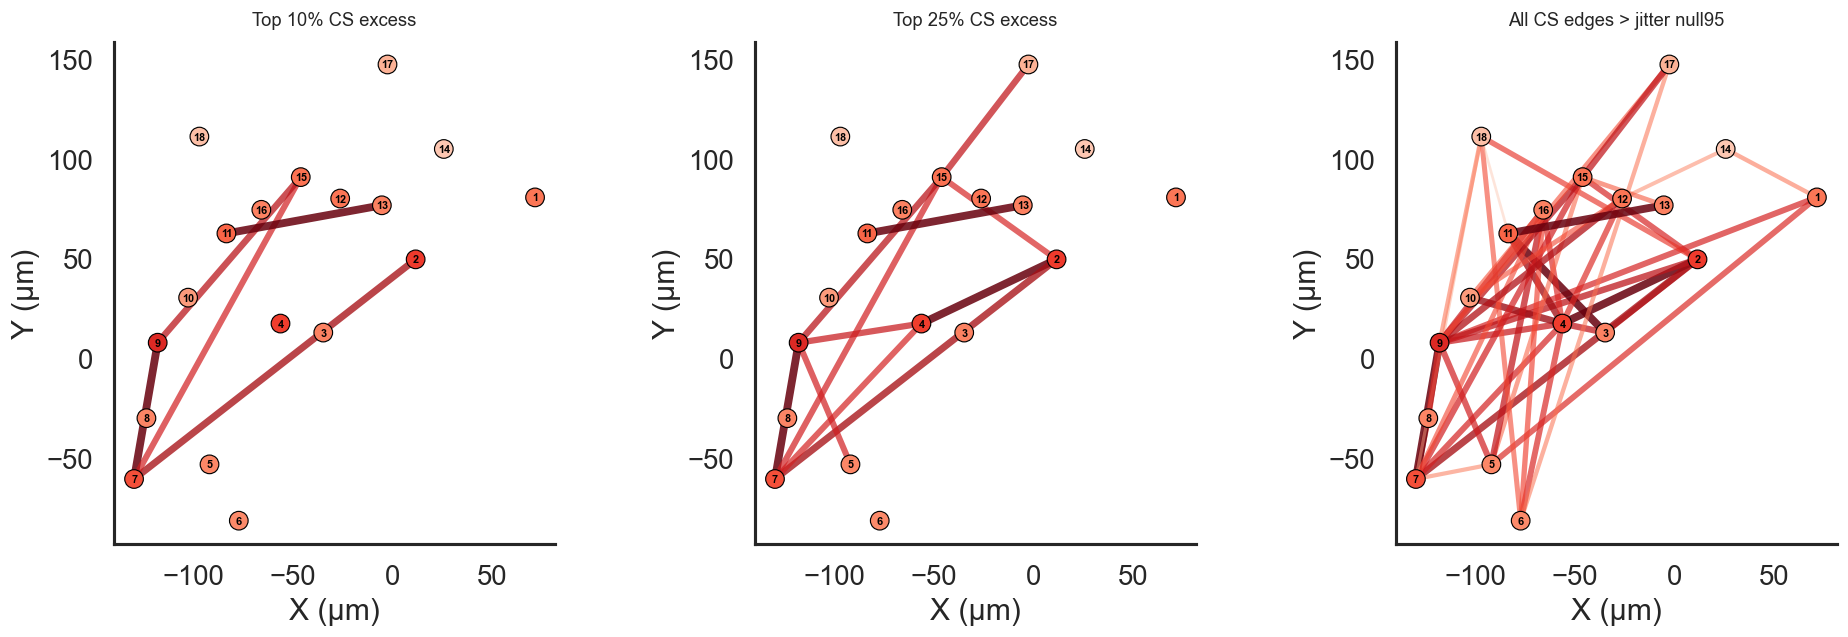

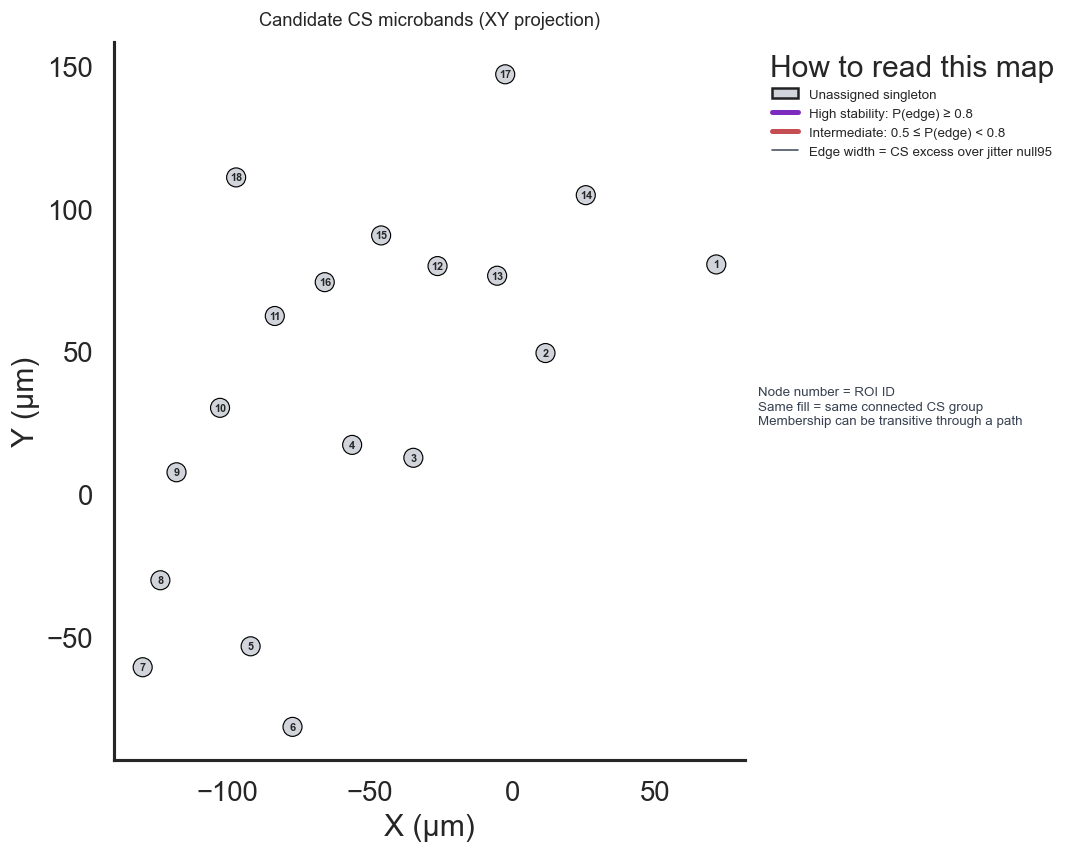

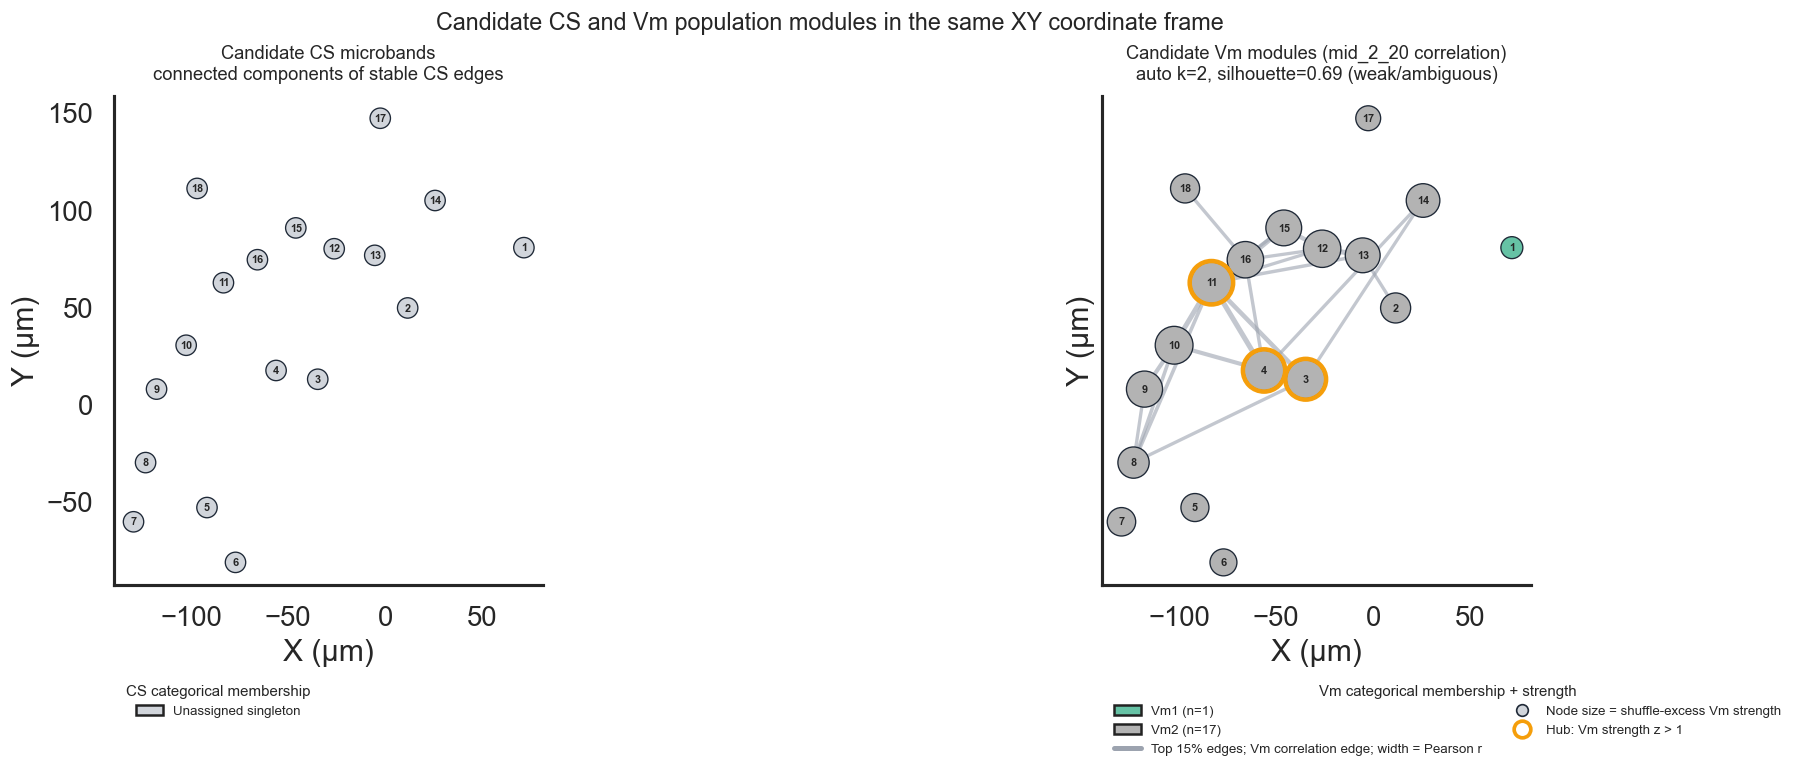

,cell,CS_stable_group,Vm_candidate_module,Vm_strength,Vm_strength_z,candidate_Vm_hub
0,ROI1_UG,unassigned,Vm1,0.316,-1.81,False
10,ROI11_UG,unassigned,Vm2,2.531,1.74,True
3,ROI4_UG,unassigned,Vm2,2.350,1.45,True
2,ROI3_UG,unassigned,Vm2,2.129,1.09,True
9,ROI10_UG,unassigned,Vm2,2.005,0.90,False
11,ROI12_UG,unassigned,Vm2,1.947,0.80,False
15,ROI16_UG,unassigned,Vm2,1.824,0.60,False
8,ROI9_UG,unassigned,Vm2,1.783,0.54,False
14,ROI15_UG,unassigned,Vm2,1.743,0.48,False
12,ROI13_UG,unassigned,Vm2,1.621,0.28,False


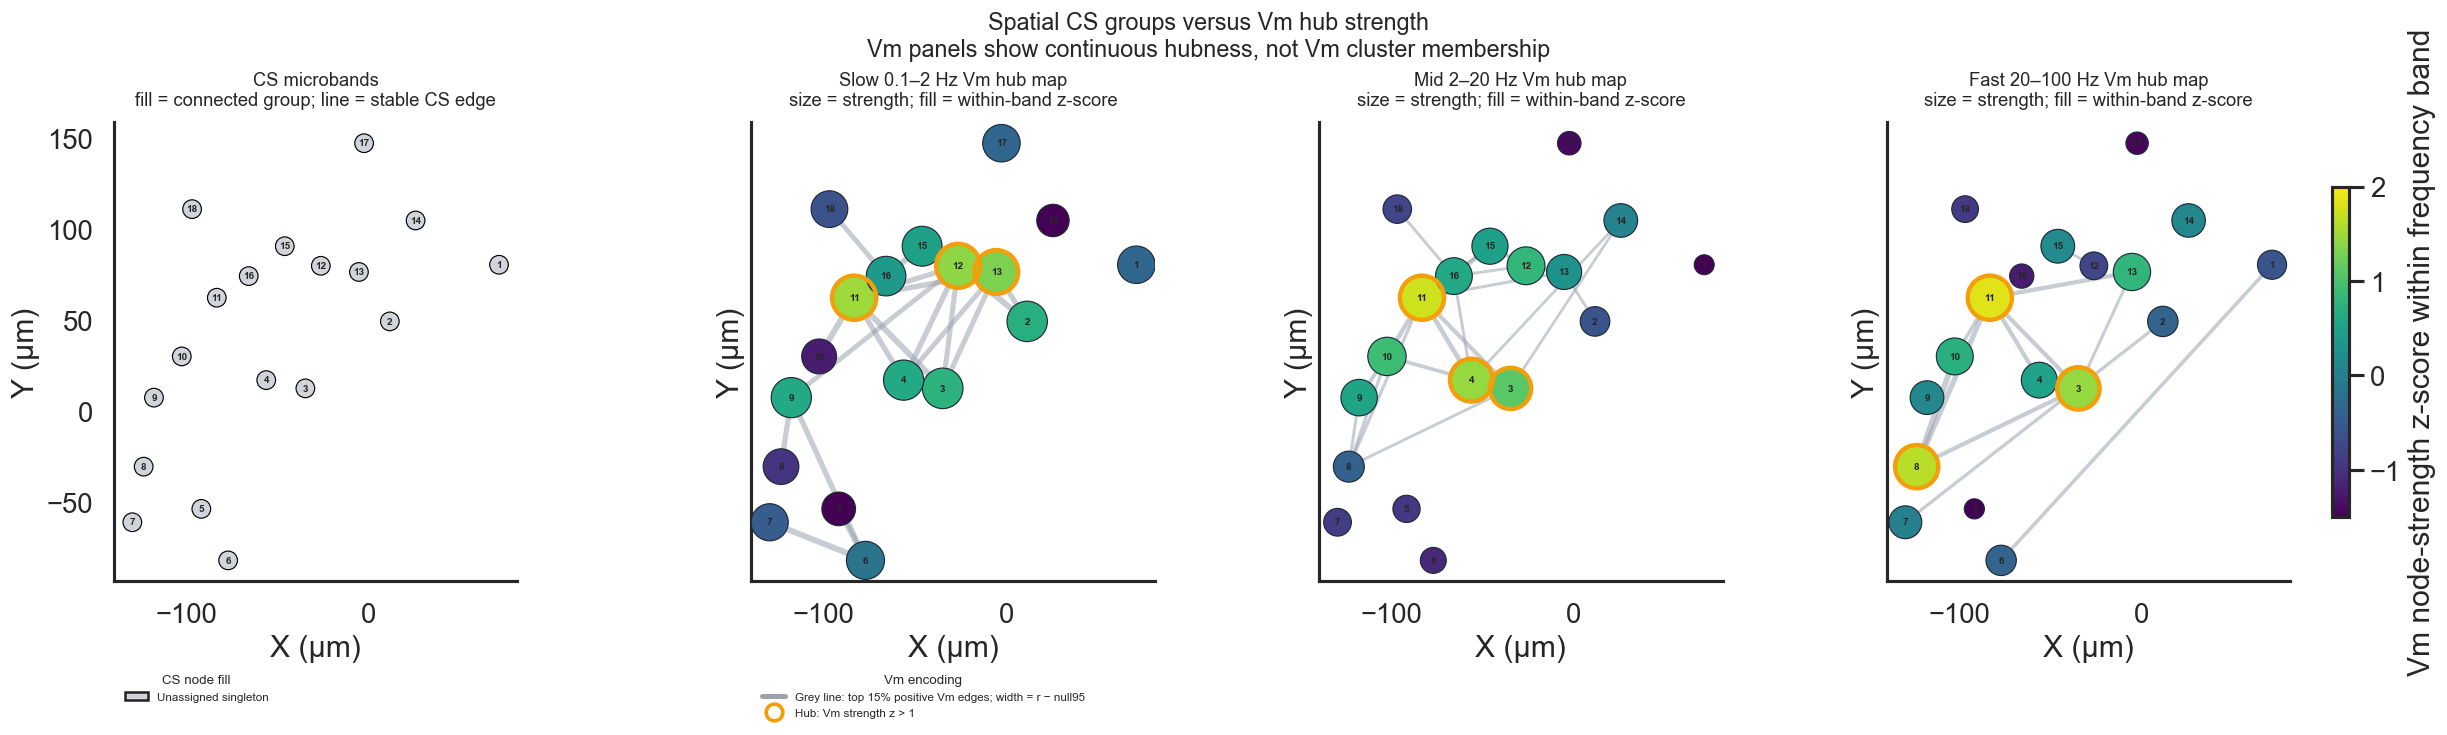

Candidate Vm hubs (outlined nodes; strength z > 1 within band)


,band,cell,strength,strength_z
46,fast_20_100,ROI11_UG,0.665,1.83
43,fast_20_100,ROI8_UG,0.631,1.62
38,fast_20_100,ROI3_UG,0.602,1.45
28,mid_2_20,ROI11_UG,2.531,1.74
21,mid_2_20,ROI4_UG,2.350,1.45
20,mid_2_20,ROI3_UG,2.129,1.09
10,slow_0.1_2,ROI11_UG,5.201,1.49
11,slow_0.1_2,ROI12_UG,5.137,1.40
12,slow_0.1_2,ROI13_UG,5.076,1.31


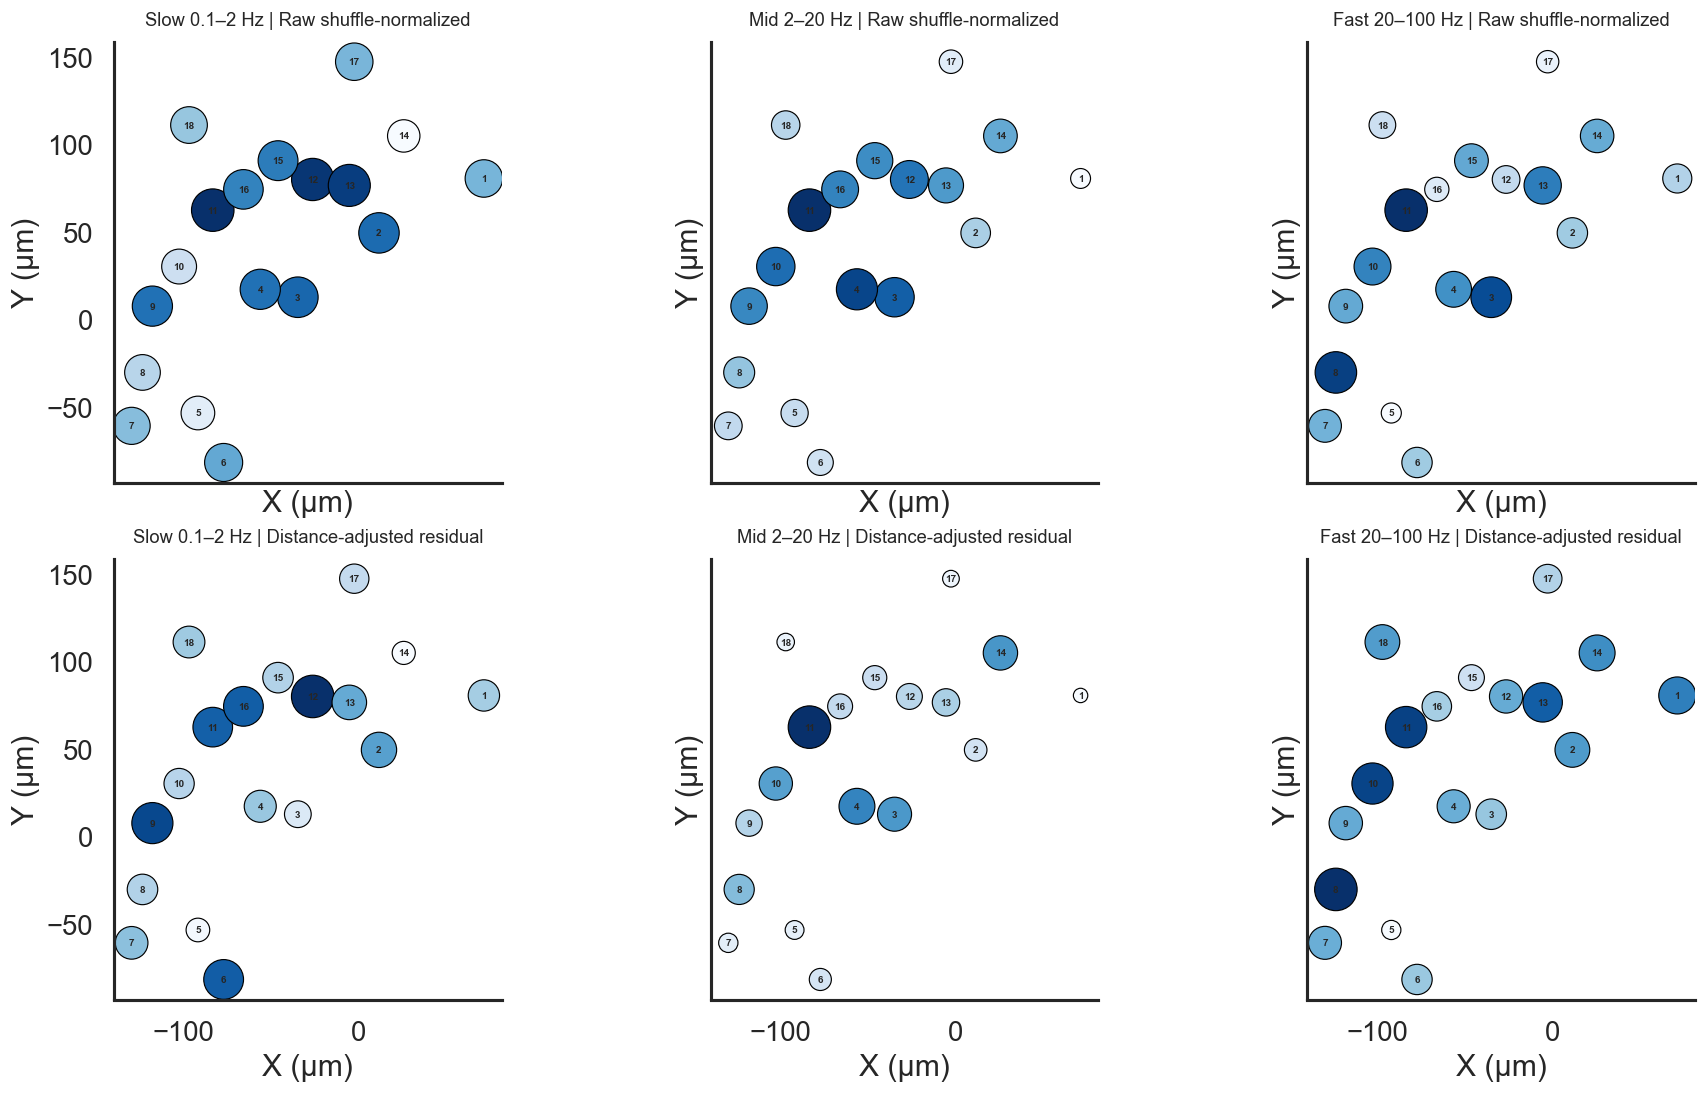

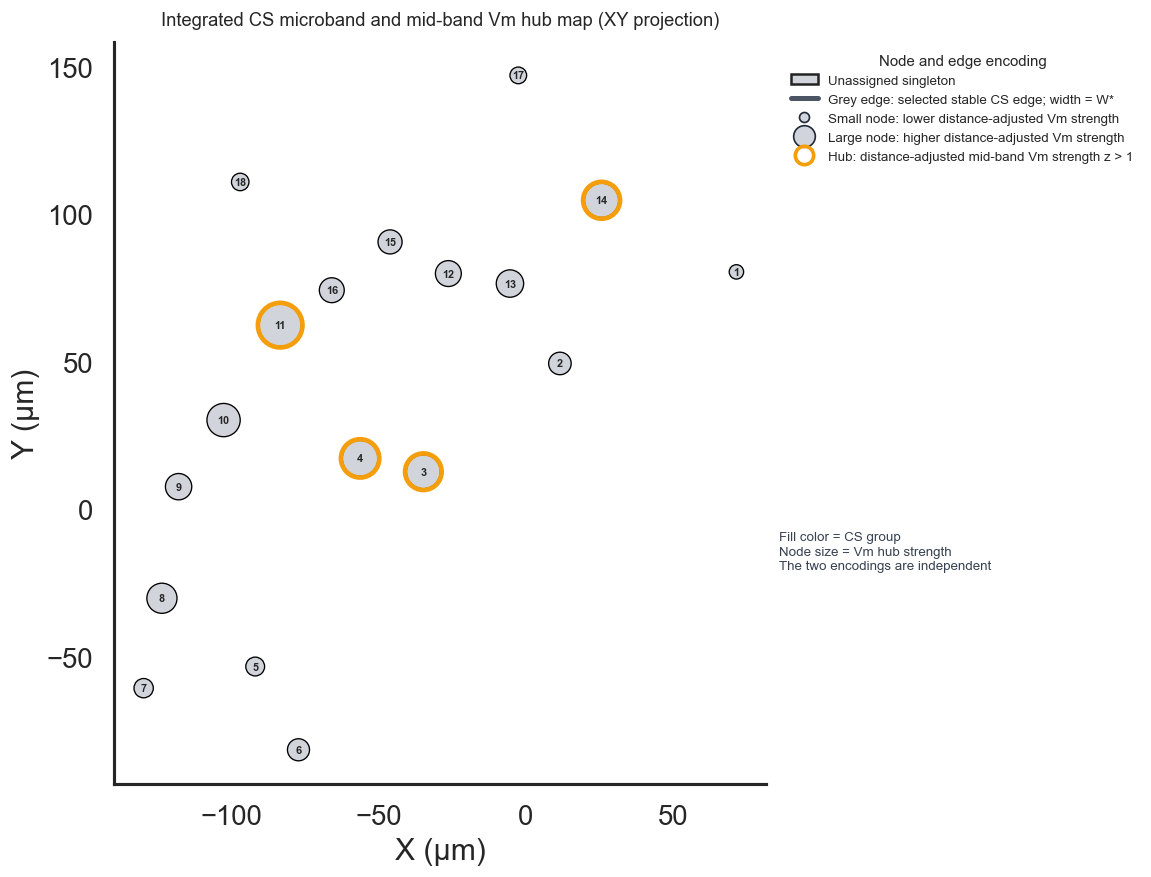

Integrated map membership and mid-band hub ranking


,cell,CS_group,mid_Vm_adjusted_strength,mid_Vm_adjusted_strength_z,candidate_mid_Vm_hub
10,ROI11_UG,unassigned,1.190,2.57,True
3,ROI4_UG,unassigned,0.807,1.33,True
13,ROI14_UG,unassigned,0.727,1.07,True
2,ROI3_UG,unassigned,0.711,1.01,True
9,ROI10_UG,unassigned,0.674,0.89,False
7,ROI8_UG,unassigned,0.527,0.41,False
12,ROI13_UG,unassigned,0.410,0.03,False
8,ROI9_UG,unassigned,0.368,-0.11,False
11,ROI12_UG,unassigned,0.352,-0.16,False
15,ROI16_UG,unassigned,0.315,-0.28,False


Spatial pair table: showing 12 of 153 rows


,cell_i,cell_j,i,j,cs_r,spatial_vm_r,cs_edge,vm_edge,edge_class,distance,distance_bin
129,ROI11_UG,ROI16_UG,10,15,0.133008,0.247820,False,True,LH,21.148515,0–50
132,ROI12_UG,ROI13_UG,11,12,0.222732,0.312597,False,True,LH,21.173146,0–50
33,ROI3_UG,ROI4_UG,2,3,0.235521,0.459689,True,True,HH,21.930846,0–50
134,ROI12_UG,ROI15_UG,11,14,0.182987,0.336522,False,True,LH,22.507688,0–50
147,ROI15_UG,ROI16_UG,14,15,0.134384,0.333927,False,True,LH,25.680440,0–50
108,ROI9_UG,ROI10_UG,8,9,0.128616,0.232821,False,True,LH,27.269536,0–50
87,ROI7_UG,ROI8_UG,6,7,0.204615,0.113800,True,True,HH,31.125779,0–50
62,ROI5_UG,ROI6_UG,4,5,0.119131,0.162361,False,True,LH,31.841146,0–50
27,ROI2_UG,ROI13_UG,1,12,0.196530,0.203250,False,True,LH,31.972716,0–50
117,ROI10_UG,ROI11_UG,9,10,0.175321,0.387909,False,True,LH,37.494854,0–50


In [12]:
# ==============================
# SPATIAL CS AND Vm SYNCHRONIZATION MAPS
# ==============================
def _normalize_roi_name(value):
    text = str(value).strip().upper().replace(' ', '')
    return text[:-3] if text.endswith('_UG') else text

def _load_roi_coordinates(folder, filename, cell_labels, coordinate_space='um', center=True):
    path = filename if os.path.isabs(filename) else os.path.join(folder, filename)
    if not os.path.isfile(path):
        candidates = sorted(glob.glob(os.path.join(folder, '*_roi_coords.csv')))
        if len(candidates) != 1:
            raise FileNotFoundError(f'Coordinate CSV not found: {path}; candidates={candidates}')
        path = candidates[0]
    table = pd.read_csv(path)
    if str(coordinate_space).lower() == 'um':
        columns, unit = ['Center_um_X', 'Center_um_Y', 'Center_um_Z'], 'µm'
    else:
        columns, unit = ['Center_FOV_px_X', 'Center_FOV_px_Y'], 'px'
    missing = {'ROI', *columns}.difference(table.columns)
    if missing: raise KeyError(f'Coordinate CSV is missing columns: {sorted(missing)}')
    table = table.copy(); table['_roi_key'] = table['ROI'].map(_normalize_roi_name)
    if table['_roi_key'].duplicated().any(): raise ValueError('Coordinate CSV contains duplicate ROI names.')
    indexed = table.set_index('_roi_key'); keys = [_normalize_roi_name(name) for name in cell_labels]
    missing_rois = [name for name, key in zip(cell_labels, keys) if key not in indexed.index]
    if missing_rois: raise KeyError(f'No coordinates for notebook cells: {missing_rois}')
    coords = indexed.loc[keys, columns].to_numpy(dtype=float)
    if coords.shape[1] == 2: coords = np.column_stack([coords, np.zeros(len(coords))])
    origin = np.nanmean(coords, axis=0) if bool(center) else np.zeros(3)
    return coords - origin, table.drop(columns='_roi_key'), path, unit, origin

def _node_strength(matrix):
    values = np.asarray(matrix, float).copy(); np.fill_diagonal(values, np.nan)
    return np.nanmean(values, axis=1)

def _roi_number(label):
    return _normalize_roi_name(label).replace('ROI', '')

def _set_spatial_axes(ax, coords_xy, unit, title):
    ax.set_xlabel(f'X ({unit})'); ax.set_ylabel(f'Y ({unit})')
    ax.set_title(title, fontsize=11, pad=10)
    ax.set_aspect('equal', adjustable='box'); ax.grid(False)
    sns.despine(ax=ax)

def plot_spatial_correlation(ax, coords, matrix, edges, title, unit, cmap, vmax):
    norm, color_map = plt.Normalize(0.0, vmax), plt.get_cmap(cmap)
    for i, j in zip(*upper):
        value = float(matrix[i, j])
        if not edges[i, j] or not np.isfinite(value) or value <= 0: continue
        ratio = np.clip(value / vmax, 0, 1)
        ax.plot(coords[[i, j], 0], coords[[i, j], 1], color=color_map(norm(value)), lw=0.7 + 4.0 * ratio, alpha=0.30 + 0.55 * ratio, zorder=1)
    strengths = np.clip(_node_strength(matrix), 0, None)
    points = ax.scatter(coords[:, 0], coords[:, 1], c=strengths, cmap=cmap, vmin=0, vmax=vmax, s=125, edgecolor='black', linewidth=0.7, zorder=3)
    if SPATIAL_CONFIG['show_roi_labels']:
        for xy, label in zip(coords[:, :2], cell_names): ax.text(xy[0], xy[1], _roi_number(label), ha='center', va='center', fontsize=6.5, fontweight='bold', color='black', zorder=4)
    _set_spatial_axes(ax, coords[:, :2], unit, title)
    return points

roi_coords, roi_coordinate_table, roi_coordinate_path, spatial_unit, coordinate_origin = _load_roi_coordinates(DATA_FOLDER, SPATIAL_CONFIG['coordinate_file'], cell_names, SPATIAL_CONFIG['coordinate_space'], SPATIAL_CONFIG['center_coordinates'])
spatial_vm_source = str(SPATIAL_CONFIG['vm_matrix_source'])
session_matches = [s for s in processed_sessions if str(SPATIAL_CONFIG['session_match']).lower() in s['session_name'].lower()]
if bool(SPATIAL_CONFIG['use_session_specific_correlations']):
    if len(session_matches) != 1: raise ValueError(f'Expected one spatial session matching {SPATIAL_CONFIG["session_match"]!r}, found {[s["session_name"] for s in session_matches]}')
    spatial_session = session_matches[0]
    spatial_rng = np.random.default_rng(int(STTC_CONFIG['rng_seed']) + 101)
    cs_spatial_rows = []; vm_spatial_rows = []
    start_ms, stop_ms = float(spatial_session['time_ms'][0]), float(spatial_session['time_ms'][-1])
    if spatial_vm_source == 'full_band':
        spatial_vm_data = spatial_session['subthreshold']; spatial_vm_title = f"Vm synchronization | {spatial_session['session_name']} | full preprocessed band"
    elif spatial_vm_source in VM_BAND_CONFIG['bands_hz']:
        low_hz, high_hz = VM_BAND_CONFIG['bands_hz'][spatial_vm_source]
        spatial_vm_data = _bandpass_matrix(spatial_session['subthreshold'], spatial_session['fs'], low_hz, high_hz, VM_BAND_CONFIG['filter_order'])
        spatial_vm_title = f"Vm synchronization | {spatial_session['session_name']} | {spatial_vm_source}"
    else: raise KeyError(f'Unknown vm_matrix_source={spatial_vm_source!r}')
    vm_min_shift = max(1, int(round(SUBTH_CORR_CONFIG['min_shift_ms'] * float(spatial_session['fs']) / 1000.0)))
    for i, j in combinations(range(n_cells), 2):
        cs_obs = _sttc(spatial_session['spike_times_cs'][i], spatial_session['spike_times_cs'][j], float(primary_dt_ms), start_ms, stop_ms)
        cs_null = np.array([_sttc(spatial_session['spike_times_cs'][i], _jitter_events(spatial_session['spike_times_cs'][j], start_ms, stop_ms, STTC_CONFIG['jitter_window_ms'], spatial_rng), float(primary_dt_ms), start_ms, stop_ms) for _ in range(int(STTC_CONFIG['n_jitter_shuffles']))])
        cs_null = cs_null[np.isfinite(cs_null)]; cs_p = (1 + np.sum(np.abs(cs_null) >= abs(cs_obs))) / (len(cs_null) + 1) if cs_null.size else np.nan
        cs_null95 = float(np.percentile(np.abs(cs_null), 95)) if cs_null.size else np.nan
        cs_spatial_rows.append({'i': i, 'j': j, 'r': cs_obs, 'p': cs_p, 'null_abs95': cs_null95})
        vm_obs, vm_p, _, vm_null95 = _corr_with_session_shifts([(spatial_vm_data[:, i], spatial_vm_data[:, j])], SUBTH_CORR_CONFIG['n_null_shuffles'], spatial_rng, vm_min_shift, SUBTH_CORR_CONFIG['min_samples'], 'concatenate')
        vm_spatial_rows.append({'i': i, 'j': j, 'r': vm_obs, 'p': vm_p, 'null_abs95': vm_null95})
    cs_spatial_df, vm_spatial_df = pd.DataFrame(cs_spatial_rows), pd.DataFrame(vm_spatial_rows)
    cs_spatial_df['q'] = _bh_fdr(cs_spatial_df['p']); vm_spatial_df['q'] = _bh_fdr(vm_spatial_df['p'])
    spatial_cs_mat, _, spatial_cs_qmat, spatial_cs_null95 = _pair_matrices(cs_spatial_df)
    spatial_vm_mat, _, spatial_vm_qmat, spatial_vm_null95 = _pair_matrices(vm_spatial_df)
    spatial_cs_edge_mat = _positive_edge_matrix(spatial_cs_mat, spatial_cs_null95, spatial_cs_qmat)
    spatial_vm_edge_mat = _positive_edge_matrix(spatial_vm_mat, spatial_vm_null95, spatial_vm_qmat)
    spatial_cs_title = f"CS synchronization | {spatial_session['session_name']} | STTC Δt={primary_dt_ms:g} ms"
else:
    spatial_cs_mat, spatial_cs_edge_mat = cs_primary_mat, cs_edge_mat
    spatial_cs_title = f'Pooled CS synchronization | STTC Δt={primary_dt_ms:g} ms'
    if spatial_vm_source == 'full_band': spatial_vm_mat, spatial_vm_edge_mat, spatial_vm_title = vm_corr_mat, vm_edge_mat, 'Pooled Vm synchronization | full preprocessed band'
    elif spatial_vm_source in vm_band_matrices:
        spatial_vm_mat = vm_band_matrices[spatial_vm_source]; spatial_vm_edge_mat = np.isfinite(spatial_vm_mat) & (spatial_vm_mat > 0); np.fill_diagonal(spatial_vm_edge_mat, False); spatial_vm_title = f'Pooled Vm synchronization | {spatial_vm_source}'
    else: raise KeyError(f'Unknown vm_matrix_source={spatial_vm_source!r}')
print(f'Loaded coordinates for {len(roi_coords)} ROIs from: {roi_coordinate_path}')
display_top(roi_coordinate_table, label='ROI coordinate table')

if SPATIAL_CONFIG['show_dense_pair_maps']:
    fig, (ax_cs, ax_vm) = plt.subplots(1, 2, figsize=(15, 6.5), constrained_layout=True)
    cs_points = plot_spatial_correlation(ax_cs, roi_coords, spatial_cs_mat, spatial_cs_edge_mat, spatial_cs_title, spatial_unit, 'Reds', 0.30)
    vm_points = plot_spatial_correlation(ax_vm, roi_coords, spatial_vm_mat, spatial_vm_edge_mat, spatial_vm_title, spatial_unit, 'Blues', 0.45)
    fig.colorbar(cs_points, ax=ax_cs, shrink=0.62, pad=0.08, label='Mean incident CS STTC')
    fig.colorbar(vm_points, ax=ax_vm, shrink=0.62, pad=0.08, label='Mean incident Vm Pearson r')
    plt.show(); plt.close(fig)

spatial_pair_df = pd.DataFrame([{'cell_i': cell_names[i], 'cell_j': cell_names[j], 'i': i, 'j': j, 'cs_r': spatial_cs_mat[i, j]} for i, j in combinations(range(n_cells), 2)])
spatial_pair_df['spatial_vm_r'] = [spatial_vm_mat[int(i), int(j)] for i, j in zip(spatial_pair_df['i'], spatial_pair_df['j'])]
spatial_pair_df['cs_edge'] = [bool(spatial_cs_edge_mat[int(i), int(j)]) for i, j in zip(spatial_pair_df['i'], spatial_pair_df['j'])]
spatial_pair_df['vm_edge'] = [bool(spatial_vm_edge_mat[int(i), int(j)]) for i, j in zip(spatial_pair_df['i'], spatial_pair_df['j'])]
spatial_pair_df['edge_class'] = np.select([spatial_pair_df['cs_edge'] & spatial_pair_df['vm_edge'], spatial_pair_df['cs_edge'], spatial_pair_df['vm_edge']], ['HH', 'HL', 'LH'], default='LL')
spatial_pair_df['distance'] = [float(np.linalg.norm(roi_coords[int(i), :2] - roi_coords[int(j), :2])) for i, j in zip(spatial_pair_df['i'], spatial_pair_df['j'])]
spatial_class_colors = {'HH': '#7B2CBF', 'HL': '#D62728', 'LH': '#1F77B4', 'LL': '#5F6673'}
fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
combined_values = np.hypot(spatial_pair_df['cs_r'], spatial_pair_df['spatial_vm_r'])
max_combined = max(1e-9, float(np.nanpercentile(combined_values, 95)))
if SPATIAL_CONFIG['show_hh_overlay']:
    # Draw LL first, but keep it clearly visible; overlay the other classes afterward.
    draw_order = pd.Categorical(spatial_pair_df['edge_class'], categories=['LL', 'LH', 'HL', 'HH'], ordered=True)
    for row in spatial_pair_df.assign(_draw_order=draw_order).sort_values('_draw_order').itertuples(index=False):
        ratio = np.clip(np.hypot(row.cs_r, row.spatial_vm_r) / max_combined, 0, 1)
        alpha = 0.35 + 0.55 * ratio if row.edge_class != 'LL' else 0.42
        width = 0.8 + 3.2 * ratio if row.edge_class != 'LL' else 1.05
        ax.plot(roi_coords[[int(row.i), int(row.j)], 0], roi_coords[[int(row.i), int(row.j)], 1], color=spatial_class_colors[row.edge_class], lw=width, alpha=alpha, zorder=1)
    cs_strength = np.clip(_node_strength(spatial_cs_mat), 0, None); vm_strength = np.clip(_node_strength(spatial_vm_mat), 0, None)
    node_balance = cs_strength / (np.nanmax(cs_strength) + 1e-12) - vm_strength / (np.nanmax(vm_strength) + 1e-12)
    nodes = ax.scatter(roi_coords[:, 0], roi_coords[:, 1], c=node_balance, cmap='coolwarm', vmin=-1, vmax=1, s=135, edgecolor='black', linewidth=0.8, zorder=3)
    if SPATIAL_CONFIG['show_roi_labels']:
        for xy, label in zip(roi_coords[:, :2], cell_names): ax.text(xy[0], xy[1], _roi_number(label), ha='center', va='center', fontsize=6.5, fontweight='bold', color='black', zorder=4)
    _set_spatial_axes(ax, roi_coords[:, :2], spatial_unit, 'Merged CS–Vm spatial network | HH / HL / LH / LL')
    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], color=spatial_class_colors[key], lw=3, label=key) for key in ['HH', 'HL', 'LH', 'LL']]
    ax.legend(handles=handles, title='Pair class', loc='upper left', frameon=False)
    fig.colorbar(nodes, ax=ax, shrink=0.62, pad=0.08, label='ROI balance: CS-dominant (+) ↔ Vm-dominant (−)')
    plt.show(); plt.close(fig)
else:
    plt.close(fig)

# Distance–synchrony relationships. Node-label permutations preserve pair dependence.
distance_matrix = np.full((n_cells, n_cells), np.nan)
for i, j in combinations(range(n_cells), 2):
    distance_matrix[i, j] = distance_matrix[j, i] = np.linalg.norm(roi_coords[i, :2] - roi_coords[j, :2])
def _distance_permutation_test(sync_matrix, n_permutations, rng):
    observed = _matrix_association(distance_matrix, sync_matrix, 'spearman')
    null = np.full(int(n_permutations), np.nan)
    for k in range(int(n_permutations)):
        perm = rng.permutation(n_cells)
        null[k] = _matrix_association(distance_matrix, sync_matrix[np.ix_(perm, perm)], 'spearman')
    valid = null[np.isfinite(null)]
    p_two_sided = (1 + np.sum(np.abs(valid) >= abs(observed))) / (len(valid) + 1)
    return observed, float(p_two_sided), valid
distance_rng = np.random.default_rng(int(NETWORK_CONFIG['rng_seed']) + 303)
distance_rows = []
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.3), constrained_layout=True)
for ax, column, matrix, label, color in [
    (axes[0], 'cs_r', spatial_cs_mat, f'CS STTC (Δt={primary_dt_ms:g} ms)', '#C44E52'),
    (axes[1], 'spatial_vm_r', spatial_vm_mat, 'Vm Pearson r', '#4C72B0'),
]:
    data = spatial_pair_df[['distance', column]].replace([np.inf, -np.inf], np.nan).dropna()
    rho, p_node, _ = _distance_permutation_test(matrix, NETWORK_CONFIG['n_qap_permutations'], distance_rng)
    ax.scatter(data['distance'], data[column], s=38, alpha=0.72, color=color, edgecolor='white', linewidth=0.35)
    if len(data) >= 3 and np.std(data['distance']) > 0:
        fit = linregress(data['distance'], data[column]); xfit = np.linspace(data['distance'].min(), data['distance'].max(), 150)
        ax.plot(xfit, fit.intercept + fit.slope * xfit, color='#222222', lw=2)
    ax.set_xlabel(f'XY distance ({spatial_unit})'); ax.set_ylabel(label)
    ax.set_title(f'{label} versus XY distance\nSpearman ρ={rho:+.3f}, node-permutation p={p_node:.4g}', fontsize=11, pad=10)
    sns.despine(ax=ax); distance_rows.append({'measure': label, 'spearman_rho': rho, 'node_permutation_p_two_sided': p_node, 'n_pairs': len(data)})
plt.show(); plt.close(fig)
distance_synchrony_summary = pd.DataFrame(distance_rows); display(distance_synchrony_summary)

# Distance bins are descriptive only; all statistical tests above use continuous distance.
distance_bins = np.asarray(SPATIAL_CONFIG['distance_bins'], dtype=float)
distance_labels = [f'{distance_bins[k]:g}–{distance_bins[k + 1]:g}' if np.isfinite(distance_bins[k + 1]) else f'>{distance_bins[k]:g}' for k in range(len(distance_bins) - 1)]
spatial_pair_df['distance_bin'] = pd.cut(spatial_pair_df['distance'], bins=distance_bins, labels=distance_labels, include_lowest=True, right=False)
distance_binned_summary = spatial_pair_df.groupby('distance_bin', observed=False).agg(n_pairs=('distance', 'size'), mean_distance=('distance', 'mean'), cs_mean=('cs_r', 'mean'), cs_sem=('cs_r', 'sem'), vm_mean=('spatial_vm_r', 'mean'), vm_sem=('spatial_vm_r', 'sem')).reset_index()
fig, ax = plt.subplots(figsize=(8.5, 5), constrained_layout=True); x = np.arange(len(distance_binned_summary))
ax.errorbar(x - 0.06, distance_binned_summary['cs_mean'], yerr=distance_binned_summary['cs_sem'], marker='o', lw=2, color='#C44E52', label='CS STTC')
ax.errorbar(x + 0.06, distance_binned_summary['vm_mean'], yerr=distance_binned_summary['vm_sem'], marker='o', lw=2, color='#4C72B0', label='Vm Pearson r')
ax.set_xticks(x, distance_binned_summary['distance_bin'].astype(str)); ax.set_xlabel(f'XY distance bin ({spatial_unit})'); ax.set_ylabel('Pair synchrony'); ax.set_title('Descriptive distance-decay curves | continuous distance used for tests'); ax.legend(frameon=False); sns.despine(ax=ax)
plt.show(); plt.close(fig)

# CS strong-edge views: top 10%, top 25%, and every jitter-null95 edge.
cs_excess_spatial = np.maximum(0.0, spatial_cs_mat - (cs_primary_null95_mat if not SPATIAL_CONFIG['use_session_specific_correlations'] else spatial_cs_null95)); cs_excess_spatial[~np.isfinite(cs_excess_spatial)] = 0.0; np.fill_diagonal(cs_excess_spatial, 0.0)
positive_cs = cs_excess_spatial[upper]; positive_cs = positive_cs[positive_cs > 0]
cs_edge_views = []
for fraction in SPATIAL_CONFIG['cs_top_fractions']:
    threshold = np.quantile(positive_cs, 1.0 - float(fraction)) if positive_cs.size else np.inf
    cs_edge_views.append((f'Top {100 * float(fraction):g}% CS excess', cs_excess_spatial >= threshold))
cs_edge_views.append(('All CS edges > jitter null95', spatial_cs_edge_mat))
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), constrained_layout=True)
for ax, (title, edge_mask) in zip(axes, cs_edge_views):
    plot_spatial_correlation(ax, roi_coords, spatial_cs_mat, edge_mask, title, spatial_unit, 'Reds', 0.30)
plt.show(); plt.close(fig)

# Stability map: functional strength defines width; blockwise reproducibility defines opacity.
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
candidate_group_ids = sorted(int(group) for group in np.unique(cs_stable_microbands) if int(group) > 0)
candidate_palette = plt.get_cmap('tab10')(np.linspace(0, 1, max(1, len(candidate_group_ids))))
cs_group_color_lookup = {0: '#D1D5DB'}
cs_group_color_lookup.update({group: candidate_palette[k] for k, group in enumerate(candidate_group_ids)})
node_colors = [cs_group_color_lookup[int(group)] for group in cs_stable_microbands]
cs_group_handles = [Patch(facecolor=cs_group_color_lookup[group], edgecolor='#222222', label=f'CS{group} (n={int(np.sum(cs_stable_microbands == group))})') for group in candidate_group_ids]
cs_group_handles.append(Patch(facecolor=cs_group_color_lookup[0], edgecolor='#222222', label='Unassigned singleton'))
fig, ax = plt.subplots(figsize=(10.5, 7.0), constrained_layout=True)
stable_max = max(1e-12, float(np.nanmax(cs_excess_spatial)))
for i, j in zip(*upper):
    strength, stability = cs_excess_spatial[i, j], cs_edge_stability_mat[i, j]
    if strength <= 0 or not np.isfinite(stability) or stability < float(SPATIAL_CONFIG['stability_plot_min']): continue
    color = '#7B2CBF' if stability >= CS_STABILITY_CONFIG['high_threshold'] else ('#C44E52' if stability >= CS_STABILITY_CONFIG['intermediate_threshold'] else '#9CA3AF')
    ax.plot(roi_coords[[i, j], 0], roi_coords[[i, j], 1], color=color, lw=0.6 + 4.2 * np.clip(strength / stable_max, 0, 1), alpha=0.10 + 0.85 * stability, zorder=1)
ax.scatter(roi_coords[:, 0], roi_coords[:, 1], c=node_colors, s=130, edgecolor='black', linewidth=0.7, zorder=3)
for xy, label in zip(roi_coords[:, :2], cell_names): ax.text(xy[0], xy[1], _roi_number(label), ha='center', va='center', fontsize=6.5, fontweight='bold', zorder=4)
_set_spatial_axes(ax, roi_coords[:, :2], spatial_unit, 'Candidate CS microbands (XY projection)')
stability_handles = [Line2D([0], [0], color='#7B2CBF', lw=3, label=f'High stability: P(edge) ≥ {CS_STABILITY_CONFIG["high_threshold"]:g}'), Line2D([0], [0], color='#C44E52', lw=3, label=f'Intermediate: {CS_STABILITY_CONFIG["intermediate_threshold"]:g} ≤ P(edge) < {CS_STABILITY_CONFIG["high_threshold"]:g}'), Line2D([0], [0], color='#4B5563', lw=1, label='Edge width = CS excess over jitter null95')]
ax.legend(handles=cs_group_handles + stability_handles, title='How to read this map', loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
ax.text(1.02, 0.52, 'Node number = ROI ID\nSame fill = same connected CS group\nMembership can be transitive through a path', transform=ax.transAxes, ha='left', va='top', fontsize=8, color='#374151')
plt.show(); plt.close(fig)

# Distance-adjusted Vm coupling via a leave-one-pair-out smoothing spline.
def _smooth_distance_expected(distance, values, fraction=0.35, leave_one_out=False):
    distance, values = np.asarray(distance, float), np.asarray(values, float); predicted = np.full(len(values), np.nan)
    valid_all = np.isfinite(distance) & np.isfinite(values)
    for k, target in enumerate(distance):
        valid = valid_all.copy()
        if leave_one_out: valid[k] = False
        d, y = distance[valid], values[valid]
        if d.size < 5 or not np.isfinite(target): continue
        # Collapse duplicate distances before spline fitting; fraction controls smoothing strength.
        grouped = pd.DataFrame({'distance': d, 'value': y}).groupby('distance', as_index=False)['value'].mean().sort_values('distance')
        if len(grouped) < 4: continue
        x_fit, y_fit = grouped['distance'].to_numpy(), grouped['value'].to_numpy()
        smooth_s = max(1e-12, float(fraction) * len(x_fit) * np.nanvar(y_fit))
        spline = UnivariateSpline(x_fit, y_fit, k=min(3, len(x_fit) - 1), s=smooth_s, ext=3)
        predicted[k] = float(spline(target))
    return predicted

vm_distance_adjusted_matrices = {}; vm_distance_adjusted_strength_rows = []
for band_name, matrix in vm_band_matrices.items():
    pair_values = matrix[upper]; expected = _smooth_distance_expected(distance_matrix[upper], pair_values, SPATIAL_CONFIG['distance_smoother_fraction'], leave_one_out=True)
    residual = pair_values - expected; residual_matrix = np.zeros((n_cells, n_cells), dtype=float); residual_matrix[upper] = residual; residual_matrix[(upper[1], upper[0])] = residual
    vm_distance_adjusted_matrices[band_name] = residual_matrix
    residual_strength = np.sum(np.maximum(0.0, residual_matrix), axis=1); raw_strength = np.sum(vm_band_weight_matrices[band_name], axis=1)
    for i, cell in enumerate(cell_names): vm_distance_adjusted_strength_rows.append({'band': band_name, 'cell': cell, 'raw_strength': raw_strength[i], 'distance_adjusted_strength': residual_strength[i]})
vm_distance_adjusted_strength_df = pd.DataFrame(vm_distance_adjusted_strength_rows)
vm_distance_adjusted_strength_df['raw_strength_z'] = vm_distance_adjusted_strength_df.groupby('band')['raw_strength'].transform(lambda values: (values - values.mean()) / (values.std(ddof=0) + 1e-12))
vm_distance_adjusted_strength_df['distance_adjusted_strength_z'] = vm_distance_adjusted_strength_df.groupby('band')['distance_adjusted_strength'].transform(lambda values: (values - values.mean()) / (values.std(ddof=0) + 1e-12))

def _scaled_node_sizes(values, minimum=70.0, maximum=650.0):
    values = np.asarray(values, float); top = np.nanmax(values) if np.any(np.isfinite(values)) else 0.0
    return minimum + (maximum - minimum) * np.clip(values / (top + 1e-12), 0, 1)

# Direct categorical comparison: candidate CS connected components versus candidate Vm modules.
vm_module_ids = sorted(int(group) for group in np.unique(vm_cluster_labels))
vm_module_palette = plt.get_cmap('Set2')(np.linspace(0, 1, max(1, len(vm_module_ids))))
vm_module_color_lookup = {group: vm_module_palette[k] for k, group in enumerate(vm_module_ids)}
vm_module_node_colors = [vm_module_color_lookup[int(group)] for group in vm_cluster_labels]
vm_module_handles = [Patch(facecolor=vm_module_color_lookup[group], edgecolor='#222222', label=f'Vm{group} (n={int(np.sum(vm_cluster_labels == group))})') for group in vm_module_ids]
vm_module_strength = vm_cluster_strength_rows['strength'].to_numpy(); vm_module_hubs = vm_cluster_strength_rows['candidate_hub_z_gt_1'].to_numpy(dtype=bool)
fig, (ax_cs_module, ax_vm_module) = plt.subplots(1, 2, figsize=(16.5, 6.3), sharex=True, sharey=True, constrained_layout=True)
for i, j in zip(*upper):
    if cs_stable_edge_mat[i, j]:
        edge_color = '#7B2CBF' if cs_edge_stability_mat[i, j] >= CS_STABILITY_CONFIG['high_threshold'] else '#C44E52'
        ax_cs_module.plot(roi_coords[[i, j], 0], roi_coords[[i, j], 1], color=edge_color, lw=0.6 + 3.4 * cs_stability_weight_mat[i, j] / (np.nanmax(cs_stability_weight_mat) + 1e-12), alpha=0.40 + 0.55 * np.nan_to_num(cs_edge_stability_mat[i, j]), zorder=1)
ax_cs_module.scatter(roi_coords[:, 0], roi_coords[:, 1], c=node_colors, s=150, edgecolor='#1F2937', linewidth=0.8, zorder=3)
_set_spatial_axes(ax_cs_module, roi_coords[:, :2], spatial_unit, 'Candidate CS microbands\nconnected components of stable CS edges')
ax_cs_module.legend(handles=cs_group_handles, title='CS categorical membership', loc='upper left', bbox_to_anchor=(0.0, -0.18), ncol=2, frameon=False, fontsize=8, title_fontsize=9)
positive_vm_module_edges = vm_cluster_edge_display_mat[upper]; positive_vm_module_edges = positive_vm_module_edges[positive_vm_module_edges > 0]
vm_module_edge_threshold = np.quantile(positive_vm_module_edges, 1.0 - float(SPATIAL_CONFIG['vm_top_fraction'])) if positive_vm_module_edges.size else np.inf
for i, j in zip(*upper):
    if vm_cluster_edge_display_mat[i, j] >= vm_module_edge_threshold:
        ax_vm_module.plot(roi_coords[[i, j], 0], roi_coords[[i, j], 1], color='#9CA3AF', lw=0.6 + 3.2 * vm_cluster_edge_display_mat[i, j] / (vm_cluster_edge_max + 1e-12), alpha=0.60, zorder=1)
vm_module_sizes = _scaled_node_sizes(vm_module_strength, minimum=110, maximum=620)
ax_vm_module.scatter(roi_coords[:, 0], roi_coords[:, 1], c=vm_module_node_colors, s=vm_module_sizes, edgecolor='#1F2937', linewidth=0.8, zorder=3)
if np.any(vm_module_hubs): ax_vm_module.scatter(roi_coords[vm_module_hubs, 0], roi_coords[vm_module_hubs, 1], s=vm_module_sizes[vm_module_hubs] + 60, facecolors='none', edgecolors='#F59E0B', linewidths=2.7, zorder=4)
_set_spatial_axes(ax_vm_module, roi_coords[:, :2], spatial_unit, f'Candidate Vm modules ({vm_cluster_source_label})\nauto k={len(vm_module_ids)}, silhouette={vm_cluster_silhouette:.2f} ({vm_cluster_quality})')
vm_module_encoding_handles = vm_module_handles + [Line2D([0], [0], color='#9CA3AF', lw=3, label=f'Top {100 * SPATIAL_CONFIG["vm_top_fraction"]:g}% edges; {vm_cluster_edge_label}'), Line2D([0], [0], marker='o', markerfacecolor='#D1D5DB', markeredgecolor='#1F2937', lw=0, markersize=7, label='Node size = shuffle-excess Vm strength'), Line2D([0], [0], markerfacecolor='none', markeredgecolor='#F59E0B', markeredgewidth=2.2, marker='o', lw=0, markersize=10, label='Hub: Vm strength z > 1')]
ax_vm_module.legend(handles=vm_module_encoding_handles, title='Vm categorical membership + strength', loc='upper left', bbox_to_anchor=(0.0, -0.18), ncol=2, frameon=False, fontsize=8, title_fontsize=9)
for ax in (ax_cs_module, ax_vm_module):
    for xy, label in zip(roi_coords[:, :2], cell_names): ax.text(xy[0], xy[1], _roi_number(label), ha='center', va='center', fontsize=6.5, fontweight='bold', zorder=5)
fig.suptitle('Candidate CS and Vm population modules in the same XY coordinate frame', fontsize=14)
plt.show(); plt.close(fig)
cs_vm_membership = cluster_membership[['cell', 'CS_stable_group', 'Vm_candidate_module']].merge(vm_cluster_membership[['cell', 'Vm_strength', 'Vm_strength_z', 'candidate_Vm_hub']], on='cell', how='left')
display(cs_vm_membership.sort_values(['Vm_candidate_module', 'Vm_strength'], ascending=[True, False]).round({'Vm_strength': 3, 'Vm_strength_z': 2}))

# Four directly comparable maps: CS plus slow/mid/fast Vm hubs.
band_display = {'slow_0.1_2': 'Slow 0.1–2 Hz', 'mid_2_20': 'Mid 2–20 Hz', 'fast_20_100': 'Fast 20–100 Hz'}
fig, axes = plt.subplots(1, 4, figsize=(21, 6.2), sharex=True, sharey=True, constrained_layout=True)
for i, j in zip(*upper):
    if cs_stable_edge_mat[i, j]:
        edge_color = '#7B2CBF' if cs_edge_stability_mat[i, j] >= CS_STABILITY_CONFIG['high_threshold'] else '#C44E52'
        axes[0].plot(roi_coords[[i, j], 0], roi_coords[[i, j], 1], color=edge_color, lw=0.5 + 3.5 * cs_stability_weight_mat[i, j] / (np.nanmax(cs_stability_weight_mat) + 1e-12), alpha=0.35 + 0.60 * np.nan_to_num(cs_edge_stability_mat[i, j]), zorder=1)
axes[0].scatter(roi_coords[:, 0], roi_coords[:, 1], c=node_colors, s=125, edgecolor='black', linewidth=0.7, zorder=3)
_set_spatial_axes(axes[0], roi_coords[:, :2], spatial_unit, 'CS microbands\nfill = connected group; line = stable CS edge')
axes[0].legend(handles=cs_group_handles, title='CS node fill', loc='upper left', bbox_to_anchor=(0.0, -0.18), ncol=2, frameon=False, fontsize=7, title_fontsize=8)
vm_z_norm = plt.Normalize(vmin=-1.5, vmax=2.0); vm_cmap = plt.get_cmap('viridis')
for ax, band_name in zip(axes[1:], VM_BAND_CONFIG['bands_hz']):
    band_weight = vm_band_weight_matrices[band_name]; positive_weight = band_weight[upper]; positive_weight = positive_weight[positive_weight > 0]
    top_threshold = np.quantile(positive_weight, 1.0 - float(SPATIAL_CONFIG['vm_top_fraction'])) if positive_weight.size else np.inf
    for i, j in zip(*upper):
        if band_weight[i, j] >= top_threshold:
            ax.plot(roi_coords[[i, j], 0], roi_coords[[i, j], 1], color='#9CA3AF', lw=0.6 + 3.0 * band_weight[i, j] / (np.nanmax(band_weight) + 1e-12), alpha=0.55, zorder=1)
    strength_rows = vm_band_strength_df[vm_band_strength_df['band'] == band_name].set_index('cell').loc[cell_names]
    strength = strength_rows['strength'].to_numpy(); strength_z = strength_rows['strength_z'].to_numpy(); hub_mask = strength_z > 1.0
    ax.scatter(roi_coords[:, 0], roi_coords[:, 1], s=_scaled_node_sizes(strength), c=strength_z, cmap=vm_cmap, norm=vm_z_norm, edgecolor='#1F2937', linewidth=0.7, zorder=3)
    if np.any(hub_mask): ax.scatter(roi_coords[hub_mask, 0], roi_coords[hub_mask, 1], s=_scaled_node_sizes(strength)[hub_mask] + 55, facecolors='none', edgecolors='#F59E0B', linewidths=2.6, zorder=4)
    _set_spatial_axes(ax, roi_coords[:, :2], spatial_unit, f'{band_display[band_name]} Vm hub map\nsize = strength; fill = within-band z-score')
for ax in axes:
    for xy, label in zip(roi_coords[:, :2], cell_names): ax.text(xy[0], xy[1], _roi_number(label), ha='center', va='center', fontsize=6, fontweight='bold')
vm_encoding_handles = [Line2D([0], [0], color='#9CA3AF', lw=3, label=f'Grey line: top {100 * SPATIAL_CONFIG["vm_top_fraction"]:g}% positive Vm edges; width = r − null95'), Line2D([0], [0], marker='o', markerfacecolor='none', markeredgecolor='#F59E0B', markeredgewidth=2.2, lw=0, markersize=10, label='Hub: Vm strength z > 1')]
axes[1].legend(handles=vm_encoding_handles, title='Vm encoding', loc='upper left', bbox_to_anchor=(0.0, -0.18), frameon=False, fontsize=7, title_fontsize=8)
vm_colorbar = fig.colorbar(plt.cm.ScalarMappable(norm=vm_z_norm, cmap=vm_cmap), ax=axes[1:], shrink=0.72, pad=0.025)
vm_colorbar.set_label('Vm node-strength z-score within frequency band')
fig.suptitle('Spatial CS groups versus Vm hub strength\nVm panels show continuous hubness, not Vm cluster membership', fontsize=14)
plt.show(); plt.close(fig)
vm_hub_summary = vm_band_strength_df.loc[vm_band_strength_df['candidate_hub_z_gt_1'], ['band', 'cell', 'strength', 'strength_z']].sort_values(['band', 'strength_z'], ascending=[True, False])
print('Candidate Vm hubs (outlined nodes; strength z > 1 within band)')
display(vm_hub_summary.round({'strength': 3, 'strength_z': 2}))

# Raw versus distance-adjusted hub maps for every Vm timescale.
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True, constrained_layout=True)
for col, band_name in enumerate(VM_BAND_CONFIG['bands_hz']):
    rows = vm_distance_adjusted_strength_df[vm_distance_adjusted_strength_df['band'] == band_name]
    for row, column, title in [(0, 'raw_strength', 'Raw shuffle-normalized'), (1, 'distance_adjusted_strength', 'Distance-adjusted residual')]:
        values = rows[column].to_numpy(); axes[row, col].scatter(roi_coords[:, 0], roi_coords[:, 1], s=_scaled_node_sizes(values), c=values, cmap='Blues', edgecolor='black', linewidth=0.7)
        for xy, label in zip(roi_coords[:, :2], cell_names): axes[row, col].text(xy[0], xy[1], _roi_number(label), ha='center', va='center', fontsize=6, fontweight='bold')
        _set_spatial_axes(axes[row, col], roi_coords[:, :2], spatial_unit, f'{band_display[band_name]} | {title}')
plt.show(); plt.close(fig)

# Integrated view: CS group is node color; mid-band Vm hub strength is node size; only top CS edges per node remain.
integrated_band = 'mid_2_20'
integrated_rows = vm_distance_adjusted_strength_df[vm_distance_adjusted_strength_df['band'] == integrated_band].set_index('cell').loc[cell_names]
integrated_strength = integrated_rows['distance_adjusted_strength'].to_numpy(); integrated_strength_z = integrated_rows['distance_adjusted_strength_z'].to_numpy()
integrated_hub_mask = integrated_strength_z > 1.0
selected_cs_edges = set()
for i in range(n_cells):
    eligible = np.where(cs_stable_edge_mat[i], cs_stability_weight_mat[i], 0.0)
    neighbors = np.argsort(eligible)[::-1]
    for j in neighbors[:int(SPATIAL_CONFIG['integrated_cs_edges_per_node'])]:
        if eligible[j] > 0: selected_cs_edges.add(tuple(sorted((i, int(j)))))
fig, ax = plt.subplots(figsize=(11.5, 7.2), constrained_layout=True)
for i, j in selected_cs_edges: ax.plot(roi_coords[[i, j], 0], roi_coords[[i, j], 1], color='#4B5563', lw=0.8 + 4.0 * cs_stability_weight_mat[i, j] / (np.nanmax(cs_stability_weight_mat) + 1e-12), alpha=0.70, zorder=1)
integrated_sizes = _scaled_node_sizes(integrated_strength)
ax.scatter(roi_coords[:, 0], roi_coords[:, 1], s=integrated_sizes, c=node_colors, edgecolor='black', linewidth=0.8, zorder=3)
if np.any(integrated_hub_mask): ax.scatter(roi_coords[integrated_hub_mask, 0], roi_coords[integrated_hub_mask, 1], s=integrated_sizes[integrated_hub_mask] + 65, facecolors='none', edgecolors='#F59E0B', linewidths=2.8, zorder=4)
for xy, label in zip(roi_coords[:, :2], cell_names): ax.text(xy[0], xy[1], _roi_number(label), ha='center', va='center', fontsize=6.5, fontweight='bold')
_set_spatial_axes(ax, roi_coords[:, :2], spatial_unit, 'Integrated CS microband and mid-band Vm hub map (XY projection)')
integrated_handles = cs_group_handles + [Line2D([0], [0], color='#4B5563', lw=3, label='Grey edge: selected stable CS edge; width = W*'), Line2D([0], [0], marker='o', markerfacecolor='#D1D5DB', markeredgecolor='#1F2937', lw=0, markersize=6, label='Small node: lower distance-adjusted Vm strength'), Line2D([0], [0], marker='o', markerfacecolor='#D1D5DB', markeredgecolor='#1F2937', lw=0, markersize=13, label='Large node: higher distance-adjusted Vm strength'), Line2D([0], [0], marker='o', markerfacecolor='none', markeredgecolor='#F59E0B', markeredgewidth=2.2, lw=0, markersize=11, label='Hub: distance-adjusted mid-band Vm strength z > 1')]
ax.legend(handles=integrated_handles, title='Node and edge encoding', loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8, title_fontsize=9)
ax.text(1.02, 0.34, 'Fill color = CS group\nNode size = Vm hub strength\nThe two encodings are independent', transform=ax.transAxes, ha='left', va='top', fontsize=8, color='#374151')
plt.show(); plt.close(fig)
integrated_hub_summary = pd.DataFrame({'cell': cell_names, 'CS_group': cs_stable_group_labels, 'mid_Vm_adjusted_strength': integrated_strength, 'mid_Vm_adjusted_strength_z': integrated_strength_z, 'candidate_mid_Vm_hub': integrated_hub_mask}).sort_values('mid_Vm_adjusted_strength_z', ascending=False)
print('Integrated map membership and mid-band hub ranking')
display(integrated_hub_summary.round({'mid_Vm_adjusted_strength': 3, 'mid_Vm_adjusted_strength_z': 2}))
display_top(spatial_pair_df, label='Spatial pair table', sort_by='distance', ascending=True)


In [13]:
# ==============================
# OPTIONAL TABLE EXPORT
# ==============================
def export_microzone_results():
    os.makedirs(EXPORT_DIR, exist_ok=True)
    cs_pair_df.to_csv(os.path.join(EXPORT_DIR, 'cs_binned_pearson_pairs.csv'), index=False)
    cs_primary_pair_df.to_csv(os.path.join(EXPORT_DIR, 'cs_primary_sttc_pairs.csv'), index=False)
    pd.concat(sttc_pair_tables.values(), ignore_index=True).to_csv(os.path.join(EXPORT_DIR, 'cs_sttc_all_windows.csv'), index=False)
    vm_pair_df.to_csv(os.path.join(EXPORT_DIR, 'vm_pair_correlations.csv'), index=False)
    cluster_membership.to_csv(os.path.join(EXPORT_DIR, 'network_component_membership.csv'), index=False)
    pair_comparison_df.to_csv(os.path.join(EXPORT_DIR, 'cs_vm_edge_classes.csv'), index=False)
    relationship_summary.to_csv(os.path.join(EXPORT_DIR, 'cs_vm_qap_summary.csv'), index=False)
    edge_overlap_summary.to_csv(os.path.join(EXPORT_DIR, 'cs_vm_edge_overlap_summary.csv'), index=False)
    vm_band_pair_df.to_csv(os.path.join(EXPORT_DIR, 'vm_frequency_band_pairs.csv'), index=False)
    vm_band_qap_summary.to_csv(os.path.join(EXPORT_DIR, 'vm_frequency_band_qap.csv'), index=False)
    roi_coordinate_table.to_csv(os.path.join(EXPORT_DIR, 'roi_coordinates.csv'), index=False)
    spatial_pair_df.to_csv(os.path.join(EXPORT_DIR, 'spatial_cs_vm_pairs.csv'), index=False)
    distance_synchrony_summary.to_csv(os.path.join(EXPORT_DIR, 'distance_synchrony_summary.csv'), index=False)
    distance_binned_summary.to_csv(os.path.join(EXPORT_DIR, 'distance_binned_summary.csv'), index=False)
    pd.DataFrame(stability_block_rows).to_csv(os.path.join(EXPORT_DIR, 'cs_edge_stability_blocks.csv'), index=False)
    cs_edge_stability_df.to_csv(os.path.join(EXPORT_DIR, 'cs_edge_stability_summary.csv'), index=False)
    vm_band_strength_df.to_csv(os.path.join(EXPORT_DIR, 'vm_band_node_strength.csv'), index=False)
    vm_cluster_membership.to_csv(os.path.join(EXPORT_DIR, 'vm_candidate_module_membership.csv'), index=False)
    vm_cluster_score_df.to_csv(os.path.join(EXPORT_DIR, 'vm_candidate_module_silhouette_scores.csv'), index=False)
    pd.DataFrame(cs_coassignment_mat, index=cell_names, columns=cell_names).to_csv(os.path.join(EXPORT_DIR, 'cs_temporal_coassignment.csv'))
    pd.DataFrame(cs_consensus_valid_mat, index=cell_names, columns=cell_names).to_csv(os.path.join(EXPORT_DIR, 'cs_temporal_coassignment_valid_blocks.csv'))
    cs_consensus_sensitivity_df.to_csv(os.path.join(EXPORT_DIR, 'cs_consensus_threshold_sensitivity.csv'), index=False)
    pd.DataFrame(vm_coassignment_mat, index=cell_names, columns=cell_names).to_csv(os.path.join(EXPORT_DIR, 'vm_temporal_coassignment.csv'))
    vm_consensus_score_df.to_csv(os.path.join(EXPORT_DIR, 'vm_consensus_k_diagnostics.csv'), index=False)
    vm_distance_adjusted_strength_df.to_csv(os.path.join(EXPORT_DIR, 'vm_distance_adjusted_node_strength.csv'), index=False)
    print(f'Exported microzone analysis tables to: {EXPORT_DIR}')


,metric,association,qap_p_greater,qap_p_two_sided,n_permutations
0,pearson,0.322072,0.0026,0.003100,10000
1,spearman,0.323017,0.0037,0.005499,10000


,HH,HL,LH,LL,p_vm_given_cs_pos,p_vm_given_cs_neg,delta_probability,odds_ratio,odds_ratio_haldane,log_odds_haldane,delta_probability_node_p,odds_ratio_node_p,vm_mean_difference_cs_pos_minus_neg,vm_shift_node_p,n_node_permutations
0,42,1,109,1,0.976744,0.990909,-0.014165,0.385321,0.388128,-0.94642,0.925707,0.925707,0.02612,0.069793,10000


CS–Vm edge classes: showing 12 of 153 rows


,cell_i,cell_j,i,j,cs_r,cs_p,cs_q,cs_z,cs_null_abs95,binned_pearson_r,...,vm_r,vm_p,vm_q,vm_z,vm_null_abs95,pair,cs_edge,vm_edge,edge_class,combined_strength
88,ROI7_UG,ROI9_UG,6,8,0.707190,0.004975,0.063433,5.696761,0.473257,0.654326,...,0.170359,0.004975,0.005399,12.039673,0.027291,ROI7_UG ↔ ROI9_UG,True,True,HH,0.727420
33,ROI3_UG,ROI4_UG,2,3,0.235521,0.039801,0.164582,1.681316,0.231094,0.181469,...,0.459689,0.004975,0.005399,16.440536,0.054171,ROI3_UG ↔ ROI4_UG,True,True,HH,0.516512
40,ROI3_UG,ROI11_UG,2,10,0.323764,0.004975,0.063433,2.241640,0.306920,0.243602,...,0.374719,0.004975,0.005399,14.757408,0.051629,ROI3_UG ↔ ROI11_UG,True,True,HH,0.495214
126,ROI11_UG,ROI13_UG,10,12,0.388339,0.004975,0.063433,3.165141,0.313669,0.349437,...,0.257532,0.004975,0.005399,12.371391,0.037435,ROI11_UG ↔ ROI13_UG,True,True,HH,0.465973
54,ROI4_UG,ROI11_UG,3,10,0.261339,0.024876,0.140962,2.017143,0.249695,0.169677,...,0.376288,0.004975,0.005399,15.796612,0.048015,ROI4_UG ↔ ROI11_UG,True,True,HH,0.458139
117,ROI10_UG,ROI11_UG,9,10,0.175321,0.303483,0.421375,0.573282,0.210182,0.089285,...,0.387909,0.004975,0.005399,15.143289,0.050729,ROI10_UG ↔ ROI11_UG,False,True,LH,0.425688
53,ROI4_UG,ROI10_UG,3,9,0.267079,0.019900,0.132382,2.198641,0.233909,0.119198,...,0.307209,0.004975,0.005399,13.542320,0.043902,ROI4_UG ↔ ROI10_UG,True,True,HH,0.407073
132,ROI12_UG,ROI13_UG,11,12,0.222732,0.184080,0.312935,0.909731,0.272508,0.145314,...,0.312597,0.004975,0.005399,16.250418,0.039026,ROI12_UG ↔ ROI13_UG,False,True,LH,0.383831
134,ROI12_UG,ROI15_UG,11,14,0.182987,0.099502,0.220636,1.448689,0.197388,0.067839,...,0.336522,0.004975,0.005399,16.182570,0.041791,ROI12_UG ↔ ROI15_UG,False,True,LH,0.383055
147,ROI15_UG,ROI16_UG,14,15,0.134384,0.089552,0.217484,1.266865,0.141463,0.069411,...,0.333927,0.004975,0.005399,17.172069,0.038929,ROI15_UG ↔ ROI16_UG,False,True,LH,0.359954


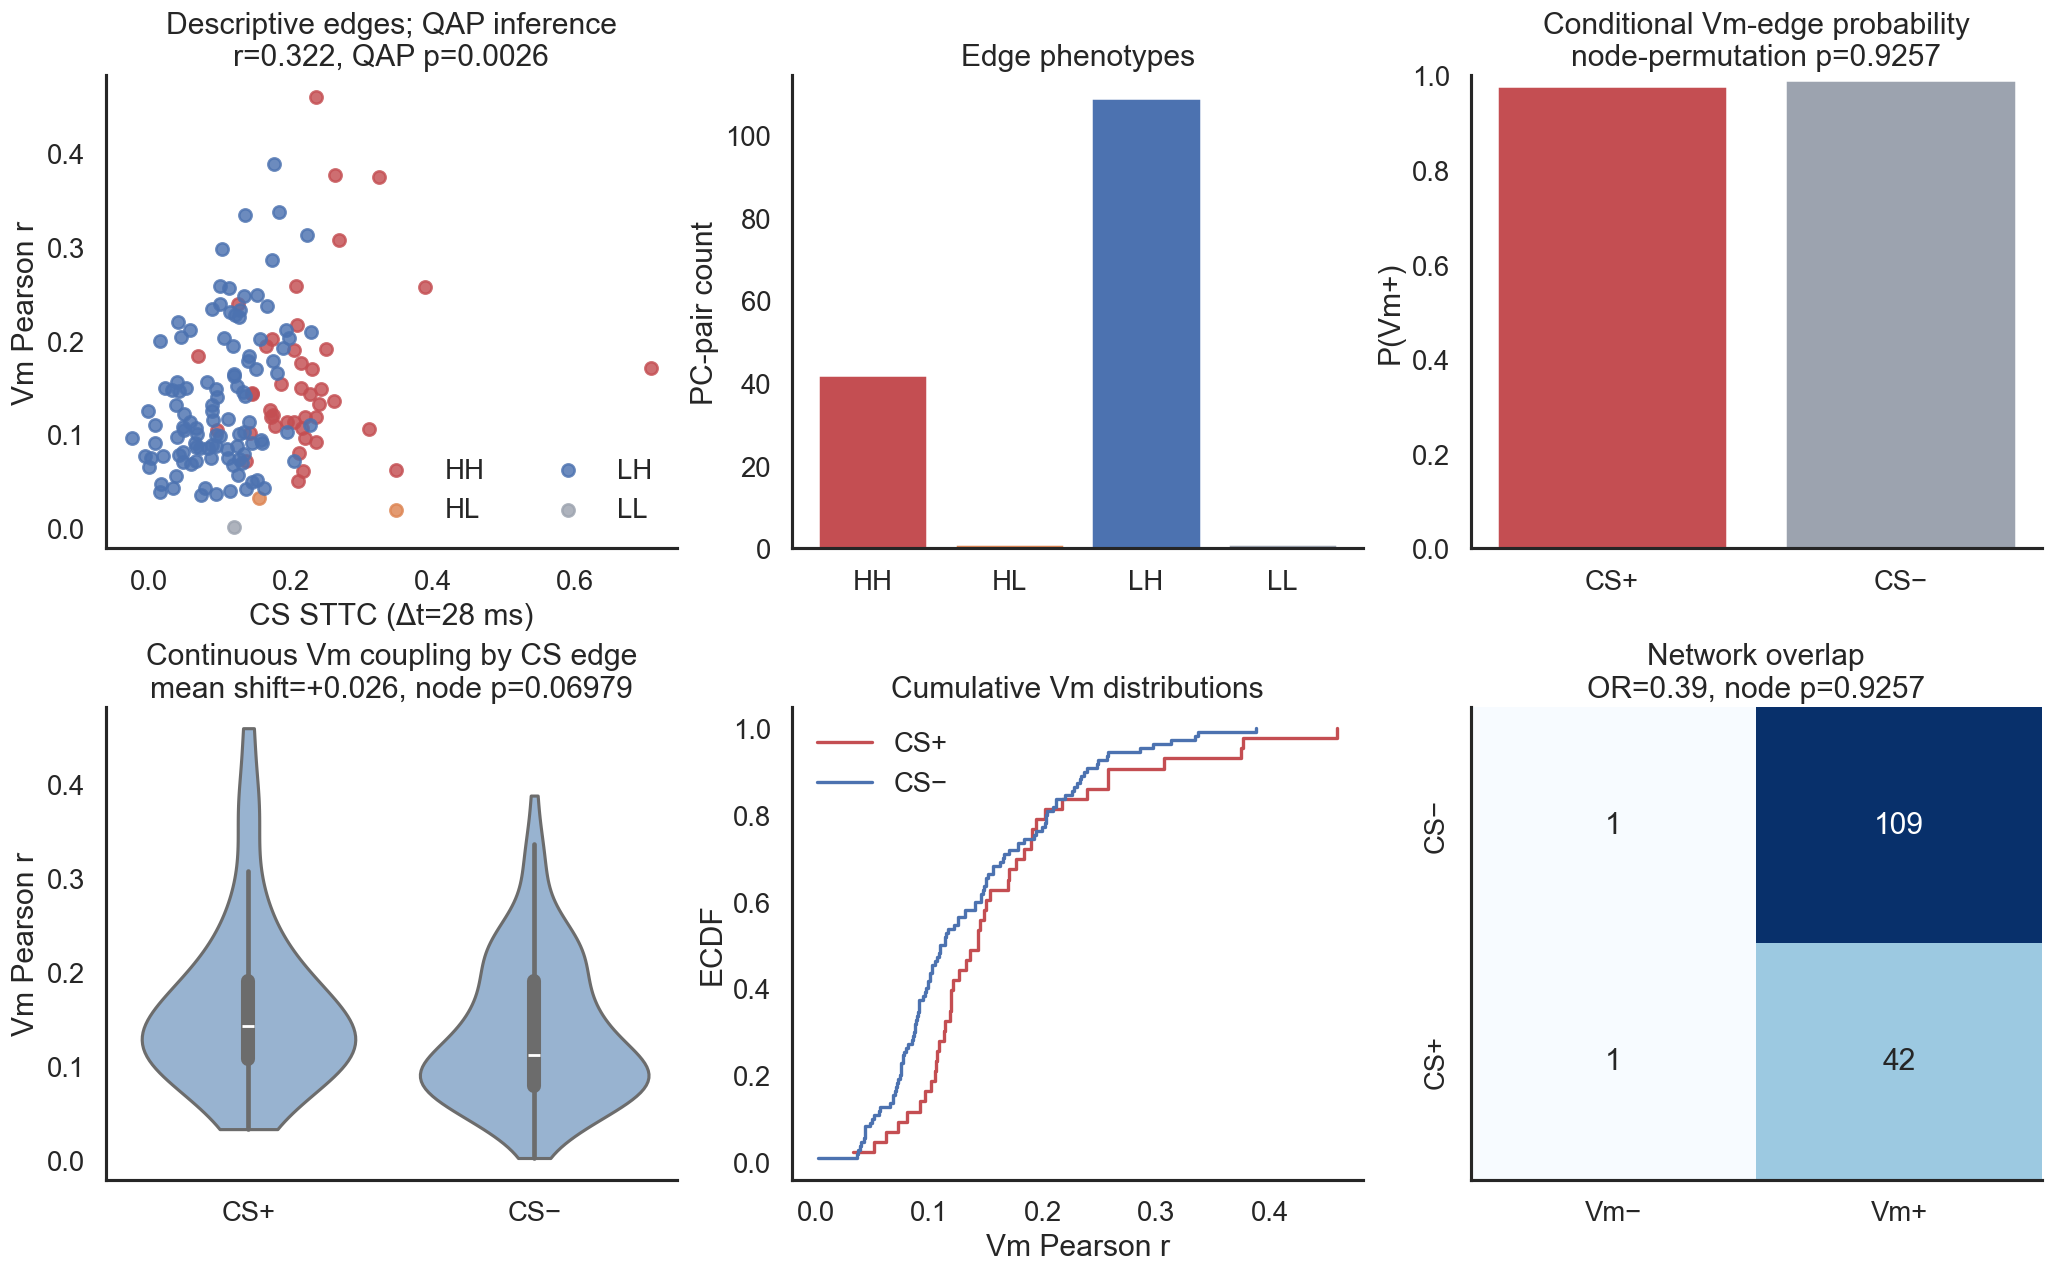

In [14]:
# ==============================
# MATRIX-LEVEL CS–Vm OVERLAP (QAP) AND EDGE PHENOTYPES
# ==============================
pair_comparison_df = cs_primary_pair_df[['cell_i', 'cell_j', 'i', 'j', 'r', 'p', 'q', 'z', 'null_abs95', 'binned_pearson_r', 'ccg_peak_r', 'ccg_peak_lag_ms']].rename(columns={'r': 'cs_r', 'p': 'cs_p', 'q': 'cs_q', 'z': 'cs_z', 'null_abs95': 'cs_null_abs95'}).merge(
    vm_pair_df[['cell_i', 'cell_j', 'r', 'p', 'q', 'z', 'null_abs95']].rename(columns={'r': 'vm_r', 'p': 'vm_p', 'q': 'vm_q', 'z': 'vm_z', 'null_abs95': 'vm_null_abs95'}),
    on=['cell_i', 'cell_j'], how='inner'
)
pair_comparison_df['pair'] = pair_comparison_df['cell_i'] + ' ↔ ' + pair_comparison_df['cell_j']
pair_comparison_df['cs_edge'] = [bool(cs_edge_mat[int(i), int(j)]) for i, j in zip(pair_comparison_df['i'], pair_comparison_df['j'])]
pair_comparison_df['vm_edge'] = [bool(vm_edge_mat[int(i), int(j)]) for i, j in zip(pair_comparison_df['i'], pair_comparison_df['j'])]
pair_comparison_df['edge_class'] = np.select(
    [pair_comparison_df['cs_edge'] & pair_comparison_df['vm_edge'], pair_comparison_df['cs_edge'], pair_comparison_df['vm_edge']],
    ['HH', 'HL', 'LH'], default='LL'
)
pair_comparison_df['combined_strength'] = np.hypot(pair_comparison_df['cs_r'], pair_comparison_df['vm_r'])

qap_rng = np.random.default_rng(int(NETWORK_CONFIG['rng_seed']))
relationship_summary, qap_null = qap_test(cs_primary_mat, vm_corr_mat, NETWORK_CONFIG['n_qap_permutations'], qap_rng)
display(relationship_summary)

def _edge_metrics(cs_edge, vm_edge):
    cs_vec, vm_vec = cs_edge[upper].astype(bool), vm_edge[upper].astype(bool)
    hh = int(np.sum(cs_vec & vm_vec)); hl = int(np.sum(cs_vec & ~vm_vec))
    lh = int(np.sum(~cs_vec & vm_vec)); ll = int(np.sum(~cs_vec & ~vm_vec))
    p_vm_cs_pos = hh / (hh + hl) if hh + hl else np.nan
    p_vm_cs_neg = lh / (lh + ll) if lh + ll else np.nan
    odds_ratio = (hh * ll) / (hl * lh) if hl > 0 and lh > 0 else np.nan
    corrected_or = ((hh + 0.5) * (ll + 0.5)) / ((hl + 0.5) * (lh + 0.5))
    return {'HH': hh, 'HL': hl, 'LH': lh, 'LL': ll, 'p_vm_given_cs_pos': p_vm_cs_pos, 'p_vm_given_cs_neg': p_vm_cs_neg, 'delta_probability': p_vm_cs_pos - p_vm_cs_neg, 'odds_ratio': odds_ratio, 'odds_ratio_haldane': corrected_or, 'log_odds_haldane': np.log(corrected_or)}

observed_edge = _edge_metrics(cs_edge_mat, vm_edge_mat)
cs_edge_density = float(np.mean(cs_edge_mat[upper])); vm_edge_density = float(np.mean(vm_edge_mat[upper]))
edge_class_counts = [observed_edge[key] for key in ('HH', 'HL', 'LH', 'LL')]
if max(cs_edge_density, vm_edge_density) >= 0.80 or min(edge_class_counts) == 0:
    print(f'Warning: binary edge overlap is saturated (CS density={cs_edge_density:.1%}, Vm density={vm_edge_density:.1%}, HH/HL/LH/LL={edge_class_counts}). Prioritize continuous QAP, Vm shifts, and stability-weighted analyses.')
cs_vec = cs_edge_mat[upper].astype(bool)
vm_vec = vm_corr_mat[upper]
observed_vm_shift = float(np.nanmean(vm_vec[cs_vec]) - np.nanmean(vm_vec[~cs_vec])) if np.any(cs_vec) and np.any(~cs_vec) else np.nan
n_edge_perm = int(NETWORK_CONFIG['n_edge_permutations'])
delta_null = np.full(n_edge_perm, np.nan); log_or_null = np.full(n_edge_perm, np.nan); vm_shift_null = np.full(n_edge_perm, np.nan)
for k in range(n_edge_perm):
    perm = qap_rng.permutation(n_cells)
    perm_edge = vm_edge_mat[np.ix_(perm, perm)]
    metrics = _edge_metrics(cs_edge_mat, perm_edge)
    delta_null[k], log_or_null[k] = metrics['delta_probability'], metrics['log_odds_haldane']
    perm_vm = vm_corr_mat[np.ix_(perm, perm)][upper]
    vm_shift_null[k] = np.nanmean(perm_vm[cs_vec]) - np.nanmean(perm_vm[~cs_vec]) if np.any(cs_vec) and np.any(~cs_vec) else np.nan

def _perm_p_greater(null, observed):
    values = np.asarray(null, float); values = values[np.isfinite(values)]
    return float((1 + np.sum(values >= observed)) / (len(values) + 1)) if values.size and np.isfinite(observed) else np.nan

edge_overlap_summary = pd.DataFrame([{**observed_edge,
    'delta_probability_node_p': _perm_p_greater(delta_null, observed_edge['delta_probability']),
    'odds_ratio_node_p': _perm_p_greater(log_or_null, observed_edge['log_odds_haldane']),
    'vm_mean_difference_cs_pos_minus_neg': observed_vm_shift,
    'vm_shift_node_p': _perm_p_greater(vm_shift_null, observed_vm_shift),
    'n_node_permutations': n_edge_perm,
}])
display(edge_overlap_summary)
display_top(pair_comparison_df, label='CS–Vm edge classes', sort_by='combined_strength')

# Figure 3: descriptive pair scatter plus matrix-valid overlap inference.
class_order = ['HH', 'HL', 'LH', 'LL']
class_colors = {'HH': '#C44E52', 'HL': '#DD8452', 'LH': '#4C72B0', 'LL': '#9CA3AF'}
fig, axes = plt.subplots(2, 3, figsize=(17, 10.5), constrained_layout=True)
ax = axes[0, 0]
for cls in class_order:
    rows = pair_comparison_df[pair_comparison_df['edge_class'] == cls]
    ax.scatter(rows['cs_r'], rows['vm_r'], s=55, alpha=0.82, color=class_colors[cls], label=cls)
pearson_row = relationship_summary.set_index('metric').loc['pearson']
ax.set_title(f"Descriptive edges; QAP inference\nr={pearson_row['association']:.3f}, QAP p={pearson_row['qap_p_greater']:.4g}")
ax.set_xlabel(f'CS STTC (Δt={primary_dt_ms:g} ms)'); ax.set_ylabel('Vm Pearson r'); ax.legend(frameon=False, ncol=2)

counts = [observed_edge[key] for key in class_order]
axes[0, 1].bar(class_order, counts, color=[class_colors[k] for k in class_order])
axes[0, 1].set_title('Edge phenotypes'); axes[0, 1].set_ylabel('PC-pair count')

probabilities = [observed_edge['p_vm_given_cs_pos'], observed_edge['p_vm_given_cs_neg']]
axes[0, 2].bar(['CS+', 'CS−'], probabilities, color=['#C44E52', '#9CA3AF'])
axes[0, 2].set_ylim(0, 1); axes[0, 2].set_ylabel('P(Vm+)')
axes[0, 2].set_title(f"Conditional Vm-edge probability\nnode-permutation p={edge_overlap_summary.iloc[0]['delta_probability_node_p']:.4g}")

violin_df = pair_comparison_df.assign(CS_network=np.where(pair_comparison_df['cs_edge'], 'CS+', 'CS−'))
sns.violinplot(data=violin_df, x='CS_network', y='vm_r', order=['CS+', 'CS−'], inner='box', cut=0, color='#8FB3D9', ax=axes[1, 0])
axes[1, 0].set_title(f"Continuous Vm coupling by CS edge\nmean shift={observed_vm_shift:+.3f}, node p={edge_overlap_summary.iloc[0]['vm_shift_node_p']:.4g}")
axes[1, 0].set_xlabel(''); axes[1, 0].set_ylabel('Vm Pearson r')

for flag, label, color in [(True, 'CS+', '#C44E52'), (False, 'CS−', '#4C72B0')]:
    values = np.sort(pair_comparison_df.loc[pair_comparison_df['cs_edge'] == flag, 'vm_r'].dropna().to_numpy())
    if values.size:
        axes[1, 1].step(values, np.arange(1, len(values) + 1) / len(values), where='post', label=label, color=color, lw=2)
axes[1, 1].set_xlabel('Vm Pearson r'); axes[1, 1].set_ylabel('ECDF'); axes[1, 1].set_title('Cumulative Vm distributions'); axes[1, 1].legend(frameon=False)

overlap_table = np.array([[observed_edge['LL'], observed_edge['LH']], [observed_edge['HL'], observed_edge['HH']]])
sns.heatmap(overlap_table, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Vm−', 'Vm+'], yticklabels=['CS−', 'CS+'], ax=axes[1, 2])
axes[1, 2].set_title(f"Network overlap\nOR={observed_edge['odds_ratio_haldane']:.2f}, node p={edge_overlap_summary.iloc[0]['odds_ratio_node_p']:.4g}")
for ax in axes.flat:
    sns.despine(ax=ax)
plt.show()
plt.close(fig)

if EXPORT_RESULTS:
    export_microzone_results()
